# Figure 4: Activity-Distance Compilation

Cache-first paper draft for activity-state spectra, axonal wave speeds, spike synchrony over distance, and axonal-only versus ephaptic-axonal model fits.

The figure cache is local to `outputs/figure4_activity_distance/`. Raw spike-state recomputation is explicit through `ALLOW_RAW_RECOMPUTE`; synchrony and wave analyses prefer existing caches because those are the expensive parts.


In [30]:

%matplotlib inline
import gc
import hashlib
import json
import math
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from scipy.stats import chi2

repo_root = Path.cwd()
if not (repo_root / "ephax").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from ephax import PrepConfig, RestingActivityDataset
from ephax.analyzers.layout_grid import LayoutGridPlotter
from ephax.metrics import (
    ActivityIntervalConfig,
    RecordingSynchronyInput,
    SynchronyDistanceConfig,
    aggregate_wave_results,
    build_burst_peak_aligned_events,
    binned_kde_peak_summary,
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    compute_or_load_wave_result,
    compute_recording_synchrony_distance,
    detect_activity_intervals,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
    extract_activity_state_ifr,
    load_wave_result_cache,
    save_wave_result_cache,
    wave_cache_dir,
    write_synchrony_distance_cache,
)
from ephax.modeling import correlation_function
from ephax.plotting import PAPER_COLORS, apply_paper_style, compose_figure, draw_grid_avghz, export_figure, figure, panel
from ephax.plotting.style import FONT_SIZES

apply_paper_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)


## Configuration

`RUN_ALL_WELLS` and `RUN_ALL_DIVS` choose whether the figure uses the full matrix or a selected row/column/cell. The synchrony panel is based on cached activity-distance outputs; it will not silently run the full synchrony bootstrap if no cache is found.


## Cache Helpers


In [31]:

DATASET = "stim_removal_null"
RUN_ALL_WELLS = True
RUN_ALL_DIVS = True
WELL = 1
DIV = 21
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = [12, 14, 21, 22, 23, 26]

START_SEC = 0.0
END_SEC = 600.0
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000

ALLOW_RAW_RECOMPUTE = True
FORCE_FIGURE4_RECOMPUTE = False
SAVE_FIGURE = True

IFR_GRID_HZ = 50.0
IFR_MAX_HZ = 1000.0
SMOOTH_SIGMA_SEC = 0.15
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0
GAMMA_PEAK_MIN_HZ = 30.0

PRIMARY_LAG_WINDOW_MS = (-2.0, 2.0)
SYNC_ACTIVITY_SCOPE = "burst"
MIN_PAIRS_PER_DISTANCE_BIN = 20
SYNC_NULL_METHOD = "interval_jitter"
SYNC_JITTER_MS = 25.0
SYNC_BOOTSTRAP_REPS = 20
SYNC_N_SURROGATES = 20
SYNC_MATRIX_BIN_MS = 1.0
SYNC_NULL_STD_FLOOR = 1e-4
SYNC_RANDOM_SEED = 0

WAVE_X_BIN_UM = 300.0
WAVE_PEAK_SEARCH_START_MS = -15.0
WAVE_PEAK_SEARCH_STOP_MS = 20.0
WAVE_TRACE_SMOOTH_SIGMA_MS = 2.0
WAVE_BIN_MS = 1.0
WAVE_MIN_ELECTRODES_PER_BIN = 5
WAVE_MIN_EVENTS_PER_BIN = 5
WAVE_BOOTSTRAP_REPS = 2000
WAVE_RANDOM_SEED = 0
ALLOW_WAVE_RAW_RECOMPUTE = True

PEAK_BAND_BOOTSTRAP_REPS = 20
PEAK_BAND_RANDOM_SEED = 0
PEAK_BANDS_HZ = {"low_gamma": (30.0, 80.0), "high_gamma": (80.0, np.inf)}
MODEL_PEAK_BAND = "low_gamma"
PEAK_BAND_LABELS = {"low_gamma": "low-gamma", "high_gamma": "high-gamma"}
PEAK_BAND_COLORS = {
    "low_gamma": PAPER_COLORS.get("high_activity", "#2ca02c"),
    "high_gamma": PAPER_COLORS.get("burst", "#1f77b4"),
}

SPATIAL_DENSITY_BIN_UM = 200.0
SPATIAL_FRACTION_SMOOTH_SIGMA_BINS = 1.0
EXAMPLE_LAYOUT_GRID_SIZE_UM = 50.0
SPATIAL_FRACTION_BOOTSTRAP_REPS = 5000
SPATIAL_FRACTION_BOOTSTRAP_SEED = 0
HDMEA_X_SPAN_MM = 3.85
HDMEA_Y_SPAN_MM = 2.10
WAVE_SPEED_PLOT_CAP_MM_PER_MS = 5.0
FIXED_AXONAL_SPEED_MM_PER_MS = 0.6

SELECTED_ELECTRODE_COORD_TABLE = "selected_electrode_coords.csv.gz"
RECORDED_ELECTRODE_COORD_TABLE = "recorded_electrode_coords.csv.gz"
PAIR_DISTANCE_RATIO_BIN_UM = 100.0
PAIR_DISTANCE_RATIO_MAX_UM = 3500.0
PAIR_DISTANCE_RATIO_TOP_N = 100
PAIR_DISTANCE_LEGACY_BINS = 74
PAIR_DISTANCE_LEGACY_PERM_SEED = 12345
PAIR_DISTANCE_LEGACY_SHUFFLE_LAYOUT_COORDINATES = True

SIMULATION_KERNEL_DIV = 14
SIMULATION_GRID_COLUMNS = 220
SIMULATION_GRID_ROWS = 120
SIMULATION_PITCH_UM = 17.5
SIMULATION_PLATING_LOSS_FRACTION = 0.7
SIMULATION_TARGET_FRACTION = 0.4
SIMULATION_MILESTONE_FRACTIONS = [1.0, 0.8, 0.6, 0.4]
SIMULATION_N_REPLICATES = 6
SIMULATION_SUBSAMPLE_SIZE = 20
SIMULATION_RANDOM_SEED = 0
SIMULATION_FRACTION_SMOOTH_SIGMA_BINS = 1.0

MODEL_FIT_BOOTSTRAP_REPS = 1000
MODEL_FIT_RANDOM_SEED = 0
MODEL_INITIAL_AXONAL_DECAY_UM = 800.0
FIXED_LAMBDA_EPH_UM = 1_000_000.0
MODEL_EPHAPTIC_COEFFICIENT_MIN = 0.0
FIXED_EPHAPTIC_SPEED_DIV = 12
FIXED_EPHAPTIC_SPEED_SCOPE = "figure3_hierarchical_all_wells"

EXAMPLE_WELL = WELL
EXAMPLE_DIV = DIV

DATA_ROOT = repo_root / "ephax" / "data" / "stimRemovalNull"
FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"
OUTPUT_DIR = repo_root / "outputs" / "figure4_activity_distance"
TABLE_DIR = OUTPUT_DIR / "tables"
WAVE_CACHE_ROOT = repo_root / "outputs" / "stim_removal_null_wave_results"
ACTIVITY_DISTANCE_CACHE_ROOT = repo_root / "outputs" / "activity_distance"
FIGURE3_SPEED_PATH = repo_root / "outputs" / "figure3_lfp_event_front" / "tables" / "hierarchical_speed_summary.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

REQUESTED_WELLS = list(AGGREGATE_WELLS) if RUN_ALL_WELLS else [int(WELL)]
REQUESTED_DIVS = list(AGGREGATE_DIVS) if RUN_ALL_DIVS else [int(DIV)]
REQUESTED_WELLS, REQUESTED_DIVS



([0, 1, 2, 3, 4, 5], [12, 14, 21, 22, 23, 26])

In [32]:

def stable_digest(obj, n=12):
    text = json.dumps(obj, sort_keys=True, default=str)
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:n]


def figure4_config_digest():
    payload = {
        "dataset": DATASET,
        "wells": REQUESTED_WELLS,
        "divs": REQUESTED_DIVS,
        "start": START_SEC,
        "end": END_SEC,
        "min_amp": MIN_AMP,
        "top_start": TOP_START,
        "top_stop": TOP_STOP,
        "ifr_grid_hz": IFR_GRID_HZ,
        "smooth_sigma_sec": SMOOTH_SIGMA_SEC,
        "high_activity_mad_scale": HIGH_ACTIVITY_MAD_SCALE,
        "network_bin_ms": NETWORK_BIN_MS,
        "network_min_participation_fraction": NETWORK_MIN_PARTICIPATION_FRACTION,
        "gamma_peak_min_hz": GAMMA_PEAK_MIN_HZ,
        "peak_bands_hz": PEAK_BANDS_HZ,
        "model_peak_band": MODEL_PEAK_BAND,
        "peak_band_bootstrap_reps": PEAK_BAND_BOOTSTRAP_REPS,
        "peak_band_bootstrap_unit": "within_recording_ifr_kde_v1",
        "sync_activity_scope": SYNC_ACTIVITY_SCOPE,
        "primary_lag": PRIMARY_LAG_WINDOW_MS,
        "wave_settings": wave_settings(),
        "model_bootstrap_reps": MODEL_FIT_BOOTSTRAP_REPS,
        "lambda_eph_um": FIXED_LAMBDA_EPH_UM,
        "fixed_ephaptic_speed_div": FIXED_EPHAPTIC_SPEED_DIV,
        "fixed_ephaptic_speed_scope": FIXED_EPHAPTIC_SPEED_SCOPE,
        "figure3_speed_path": str(FIGURE3_SPEED_PATH),
        "loader_api": "tuple_file_info_v2",
        "wave_speed_schema": "hierarchical_per_well_v2",
        "active_ref_fallback": "recording_spike_counts_v1",
        "model_gamma_input": f"div_level_{MODEL_PEAK_BAND}_mean",
        "fixed_axonal_speed_mm_per_ms": FIXED_AXONAL_SPEED_MM_PER_MS,
        "model_axonal_speed_source": "fixed_constant",
        "spatial_fraction_bin_um": SPATIAL_DENSITY_BIN_UM,
        "pair_distance_ratio_bin_um": PAIR_DISTANCE_RATIO_BIN_UM,
        "pair_distance_ratio_max_um": PAIR_DISTANCE_RATIO_MAX_UM,
        "pair_distance_ratio_top_n": PAIR_DISTANCE_RATIO_TOP_N,
        "pair_distance_legacy_bins": PAIR_DISTANCE_LEGACY_BINS,
        "pair_distance_legacy_perm_seed": PAIR_DISTANCE_LEGACY_PERM_SEED,
        "pair_distance_legacy_shuffle_layout_coordinates": PAIR_DISTANCE_LEGACY_SHUFFLE_LAYOUT_COORDINATES,
        "spatial_fraction_smooth_sigma_bins": SPATIAL_FRACTION_SMOOTH_SIGMA_BINS,
        "spatial_fraction_bootstrap_reps": SPATIAL_FRACTION_BOOTSTRAP_REPS,
        "peak_band_labels": PEAK_BAND_LABELS,
        "merged_wave_sync_panel": True,
        "spatial_profiles_attached_to_layout": True,
        "peak_band_colors_match_activity_states": True,
        "model_panel_metric": "inverse_log_likelihood_p",
        "example_layout_grid_size_um": EXAMPLE_LAYOUT_GRID_SIZE_UM,
        "hdmea_x_span_mm": HDMEA_X_SPAN_MM,
        "hdmea_y_span_mm": HDMEA_Y_SPAN_MM,
        "cache_schema": "compact_results_v6_fixed_axonal_speed",
    }
    return stable_digest(payload)


def figure_cache_path():
    return OUTPUT_DIR / f"figure4_cache_{figure4_config_digest()}.pkl"


TABLE_CACHE_FILES = {
    "aggregate_kde_curve_df": "ifr_kde_curve_by_div_state.csv.gz",
    "gamma_peak_df": "ifr_kde_peak_summary.csv",
    "peak_band_summary_df": "ifr_kde_peak_band_summary.csv",
    "peak_band_bootstrap_df": "ifr_kde_peak_band_bootstrap.csv",
    "peak_band_recording_df": "ifr_kde_peak_band_recording_summary.csv",
    "peak_band_recording_bootstrap_df": "ifr_kde_peak_band_recording_bootstrap.csv.gz",
    "activity_summary_df": "activity_summary.csv",
    "activity_skipped_df": "activity_skipped.csv",
    "wave_per_well_summary_df": "wave_bootstrap_per_well_summary.csv",
    "wave_summary_df": "wave_bootstrap_summary.csv",
    "wave_bootstrap_df": "wave_bootstrap_samples.csv.gz",
    "primary_distance_summary": "excess_synchrony_distance.csv",
    "div_aggregate_synchrony": "excess_synchrony_grid_summary.csv",
    "div_aggregate_bootstrap": "excess_synchrony_div_bootstrap.csv.gz",
    "model_fit_by_div": "model_fit_by_div.csv",
    "model_fit_bootstrap": "model_fit_bootstrap.csv.gz",
    "model_prediction_by_div": "model_prediction_by_div.csv",
    "overall_burst_synchrony_by_div": "overall_burst_synchrony_by_div.csv",
    "selected_electrode_x_fraction": "selected_electrode_x_fraction.csv.gz",
    "selected_electrode_y_fraction": "selected_electrode_y_fraction.csv.gz",
    "model_fit_by_recording": "model_fit_by_recording.csv",
    "figure4_panel_stats": "figure4_panel_stats.csv",
    "example_layout_grid_df": "example_layout_grid.csv.gz",
    "example_kde_curve_df": "example_recording_kde_curve.csv.gz",
    "example_kde_peak_df": "example_recording_kde_peaks.csv",
    "recorded_electrode_coords_df": "recorded_electrode_coords.csv.gz",
    "pair_distance_location_shuffle_ratio": "pair_distance_location_shuffle_ratio.csv",
    "pair_distance_location_shuffle_recording": "pair_distance_location_shuffle_recording.csv.gz",
    "pair_distance_legacy_permuted_ratio": "pair_distance_legacy_permuted_ratio.csv",
    "pair_distance_legacy_permuted_recording": "pair_distance_legacy_permuted_recording.csv.gz",
}

FIGURE4_PKL_SCHEMA = "figure4_compact_results_v6_fixed_axonal_speed"
TABLE_CACHE_SCHEMA = "figure4_tables_compact_results_v6_fixed_axonal_speed"
TABLE_MANIFEST_PATH = TABLE_DIR / "figure4_table_manifest.json"

COMPACT_CACHE_KEYS = {
    "config_digest",
    "cache_schema",
    "synchrony_cache_path",
    "fixed_ephaptic_speed_source",
    "aggregate_kde_by_div",
    "gamma_peak_df",
    "peak_band_summary_df",
    "peak_band_recording_df",
    "peak_band_recording_bootstrap_df",
    "activity_summary_df",
    "wave_per_well_summary_df",
    "wave_summary_df",
    "primary_distance_summary",
    "div_aggregate_synchrony",
    "model_fit_by_div",
    "model_prediction_by_div",
    "figure4_panel_stats",
    "model_fit_by_recording",
    "selected_electrode_y_fraction",
    "selected_electrode_x_fraction",
    "overall_burst_synchrony_by_div",
    "example_layout_grid_df",
    "example_kde_curve_df",
    "example_kde_peak_df",
    "recorded_electrode_coords_df",
    "pair_distance_location_shuffle_ratio",
    "pair_distance_location_shuffle_recording",
    "pair_distance_legacy_permuted_ratio",
    "pair_distance_legacy_permuted_recording",
}

BULKY_CACHE_KEYS = {
    "records",
    "activity_value_df",
    "wave_results_by_div",
    "wave_per_well_bootstrap_df",
    "wave_bootstrap_df",
    "distance_bin_summary",
    "primary_bootstrap_bin",
    "div_aggregate_bootstrap",
    "model_fit_bootstrap",
    "model_prediction_bootstrap",
    "synchrony_cache_candidates",
}


def table_path(name):
    return TABLE_DIR / name


def write_table(df, name):
    path = table_path(name)
    if df is None:
        df = pd.DataFrame()
    if df.empty and len(df.columns) == 0:
        # A no-column DataFrame is "no result", not a valid table. Remove any stale
        # current-schema table at the exact path so it cannot be loaded later.
        if path.exists():
            path.unlink()
        return path
    df.to_csv(path, index=False, compression="infer")
    return path


def read_table(name):
    path = table_path(name)
    if not path.exists() or path.stat().st_size <= 1:
        return pd.DataFrame()
    try:
        return pd.read_csv(path, compression="infer")
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def write_table_manifest():
    manifest = {
        "schema": TABLE_CACHE_SCHEMA,
        "config_digest": figure4_config_digest(),
        "table_files": TABLE_CACHE_FILES,
    }
    TABLE_MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, sort_keys=True))
    return TABLE_MANIFEST_PATH


def read_table_manifest():
    if not TABLE_MANIFEST_PATH.exists():
        return {}
    try:
        return json.loads(TABLE_MANIFEST_PATH.read_text())
    except Exception:
        return {}


def table_manifest_matches_current_config():
    manifest = read_table_manifest()
    return (
        manifest.get("schema") == TABLE_CACHE_SCHEMA
        and manifest.get("config_digest") == figure4_config_digest()
        and manifest.get("table_files") == TABLE_CACHE_FILES
    )


def aggregate_kde_to_frame(aggregate_kde):
    rows = []
    for div, state_map in (aggregate_kde or {}).items():
        for state, summary in (state_map or {}).items():
            if not isinstance(summary, dict):
                continue
            for array_name in ("plot_edges_hz", "counts", "grid_hz", "smoothed_counts"):
                values = np.asarray(summary.get(array_name, []), dtype=float)
                rows.extend(
                    {
                        "div": int(div),
                        "state": str(state),
                        "array_name": array_name,
                        "idx": int(idx),
                        "value": float(value),
                    }
                    for idx, value in enumerate(values)
                    if np.isfinite(value)
                )
    return pd.DataFrame(rows)


def aggregate_kde_from_frame(df):
    aggregate = {}
    if df is None or df.empty:
        return aggregate
    for (div, state), group in df.groupby(["div", "state"], dropna=False):
        summary = {}
        for array_name, array_df in group.groupby("array_name", dropna=False):
            ordered = array_df.sort_values("idx")
            summary[str(array_name)] = ordered["value"].to_numpy(float)
        aggregate.setdefault(int(div), {})[str(state)] = summary
    return aggregate


def make_compact_figure4_payload(payload):
    compact = {key: value for key, value in (payload or {}).items() if key in COMPACT_CACHE_KEYS and key not in BULKY_CACHE_KEYS}
    compact["config_digest"] = figure4_config_digest()
    compact["cache_schema"] = FIGURE4_PKL_SCHEMA
    return compact


def supplement_payload_from_tables(payload=None):
    payload = dict(payload or {})
    for key, filename in TABLE_CACHE_FILES.items():
        if key in payload and isinstance(payload[key], pd.DataFrame) and not payload[key].empty:
            continue
        df = read_table(filename)
        if not df.empty:
            payload[key] = df
    if "aggregate_kde_by_div" not in payload or not payload.get("aggregate_kde_by_div"):
        kde_df = payload.get("aggregate_kde_curve_df", pd.DataFrame())
        payload["aggregate_kde_by_div"] = aggregate_kde_from_frame(kde_df)
    return payload


def table_covers_requested_divs(df, div_col="div"):
    if df is None or df.empty or div_col not in df.columns:
        return False
    present = set(pd.to_numeric(df[div_col], errors="coerce").dropna().astype(int).unique())
    return set(map(int, REQUESTED_DIVS)).issubset(present)


def has_minimum_cached_results(payload):
    required = ["gamma_peak_df", "peak_band_summary_df", "peak_band_recording_bootstrap_df", "wave_summary_df", "primary_distance_summary", "div_aggregate_synchrony"]
    if int(MODEL_FIT_BOOTSTRAP_REPS) > 0:
        required.extend(["peak_band_bootstrap_df", "peak_band_recording_bootstrap_df", "div_aggregate_bootstrap", "model_fit_bootstrap"])
    if not all(isinstance(payload.get(key), pd.DataFrame) and not payload[key].empty for key in required):
        return False
    div_required = ["gamma_peak_df", "peak_band_summary_df", "wave_summary_df", "primary_distance_summary", "div_aggregate_synchrony"]
    return all(table_covers_requested_divs(payload.get(key, pd.DataFrame())) for key in div_required)


def load_figure4_tables_cache():
    if not table_manifest_matches_current_config():
        return None
    payload = supplement_payload_from_tables({"config_digest": figure4_config_digest()})
    if has_minimum_cached_results(payload):
        print("Loaded current-schema Figure 4 tables from outputs/figure4_activity_distance/tables; no raw recomputation needed.")
        return payload
    return None


def load_figure4_cache():
    path = figure_cache_path()
    if path.exists() and not FORCE_FIGURE4_RECOMPUTE:
        with path.open("rb") as f:
            payload = pickle.load(f)
        if payload.get("cache_schema") == FIGURE4_PKL_SCHEMA and payload.get("config_digest") == figure4_config_digest():
            return supplement_payload_from_tables(payload)
        print(f"Ignoring stale Figure 4 pickle {path.name}; schema/config does not match current notebook.")
    if FORCE_FIGURE4_RECOMPUTE:
        return None
    table_payload = load_figure4_tables_cache()
    if table_payload is not None:
        return table_payload
    return None


def save_figure4_cache(payload):
    path = figure_cache_path()
    compact = make_compact_figure4_payload(payload)
    with path.open("wb") as f:
        pickle.dump(compact, f, protocol=pickle.HIGHEST_PROTOCOL)
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"Wrote compact Figure 4 cache {path.name} ({size_mb:.2f} MB). Large bootstrap tables stay in CSV/GZip files.")
    return path

def bootstrap_ci(values, q=(0.025, 0.975)):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return pd.Series({"ci_low": np.nan, "ci_high": np.nan})
    lo, hi = np.quantile(values, q)
    return pd.Series({"ci_low": float(lo), "ci_high": float(hi)})


def recording_id(well, div):
    return f"stimRemovalNull_well{int(well)}_DIV{int(div)}"


def aggregate_recording_id(div):
    wells = "-".join(str(int(w)) for w in AGGREGATE_WELLS)
    return f"aggregate_stim_removal_null_wells{wells}_DIVs{int(div)}"


def recording_path(well, div):
    return DATA_ROOT / f"well{int(well)}" / FILENAME_TEMPLATE.format(div=int(div), well=int(well))


def wave_settings():
    return {
        "x_bin_um": WAVE_X_BIN_UM,
        "peak_search_start_ms": WAVE_PEAK_SEARCH_START_MS,
        "peak_search_stop_ms": WAVE_PEAK_SEARCH_STOP_MS,
        "trace_smooth_sigma_ms": WAVE_TRACE_SMOOTH_SIGMA_MS,
        "bin_ms": WAVE_BIN_MS,
        "min_electrodes_per_bin": WAVE_MIN_ELECTRODES_PER_BIN,
        "min_events_per_bin": WAVE_MIN_EVENTS_PER_BIN,
        "bootstrap_reps": WAVE_BOOTSTRAP_REPS,
        "random_seed": WAVE_RANDOM_SEED,
    }



## Activity-State IFR KDEs and Gamma Peaks


In [33]:

def active_electrode_fallback(recording):
    spike_electrodes = np.asarray(recording.spikes["electrode"], dtype=int)
    electrodes, counts = np.unique(spike_electrodes, return_counts=True)
    if electrodes.size == 0:
        return np.array([], dtype=int)
    order = np.argsort(counts)[::-1]
    electrodes = electrodes[order]
    start = max(0, int(TOP_START))
    stop = min(int(TOP_STOP), electrodes.size)
    return electrodes[start:stop].astype(int)


def rebase_dataset_clock(ds):
    for rec in ds.recordings:
        offset_s = float(rec.start_time)
        rec.spikes = {**rec.spikes, "time": np.asarray(rec.spikes["time"], dtype=float) - offset_s}
        rec.end_time = float(rec.end_time) - offset_s
        rec.start_time = 0.0
    return ds


def recording_native_t0(path):
    with np.load(path, allow_pickle=True) as data:
        sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
        frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
        return float(np.min(frameno) / sf_native) if frameno.size else 0.0


def load_recording(well, div):
    path = recording_path(well, div)
    if not path.exists():
        raise FileNotFoundError(path)
    rec_t0 = recording_native_t0(path)
    file_info = [(str(path), rec_t0 + float(START_SEC), rec_t0 + float(END_SEC), int(well))]
    ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(MIN_AMP))
    ds = rebase_dataset_clock(ds)
    rec = ds.recordings[0]
    refs = np.asarray(ds.select_ref_electrodes(PrepConfig(mode="top", top_start=int(TOP_START), top_stop=int(TOP_STOP)))[0], dtype=int)
    spike_electrodes = set(np.asarray(rec.spikes["electrode"], dtype=int).tolist())
    if refs.size == 0 or len(set(refs.tolist()) & spike_electrodes) == 0:
        refs = active_electrode_fallback(rec)
    return ds, rec, np.asarray(refs, dtype=int)



def count_recorded_electrodes_from_layout(layout):
    df = pd.DataFrame(layout)
    if df.empty:
        return 0
    if "electrode" in df.columns:
        vals = pd.to_numeric(df["electrode"], errors="coerce").dropna().unique()
        return int(vals.size)
    return int(len(df))

def state_kde_for_values(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0) & (values <= IFR_MAX_HZ)]
    summary = binned_kde_peak_summary(
        values,
        log_bins=True,
        n_bins=260,
        grid_size=8192,
        prominence_fraction=0.012,
        distance_fraction=0.006,
        bandwidth_scale=0.22,
        max_hz=IFR_MAX_HZ,
    )
    return summary, values



def bootstrap_peak_bands_for_recording(well, div, state, values):
    """Bootstrap KDE peak estimates by resampling IFR values within one recording/state."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0) & (values <= IFR_MAX_HZ)]
    rows = []
    if values.size == 0 or int(PEAK_BAND_BOOTSTRAP_REPS) <= 0:
        return rows
    seed = int(stable_digest({"seed": PEAK_BAND_RANDOM_SEED, "well": int(well), "div": int(div), "state": str(state)}, n=8), 16)
    rng = np.random.default_rng(seed)
    band_names = list(PEAK_BANDS_HZ.keys())
    for bootstrap_idx in range(int(PEAK_BAND_BOOTSTRAP_REPS)):
        sampled = rng.choice(values, size=values.size, replace=True)
        summary, _ = state_kde_for_values(sampled)
        by_band = {band: [] for band in band_names}
        for peak_hz, peak_count in zip(summary.get("peak_hz", []), summary.get("peak_counts", [])):
            band = classify_peak_band(float(peak_hz))
            if band is not None:
                by_band.setdefault(str(band), []).append((float(peak_hz), float(peak_count)))
        for band in band_names:
            peaks = by_band.get(str(band), [])
            if not peaks:
                continue
            peak_hz = np.asarray([item[0] for item in peaks], dtype=float)
            peak_counts = np.asarray([item[1] for item in peaks], dtype=float)
            rows.append({
                "well": int(well),
                "div": int(div),
                "state": str(state),
                "band": str(band),
                "bootstrap_idx": int(bootstrap_idx),
                "mean_peak_hz": float(np.nanmean(peak_hz)),
                "median_peak_hz": float(np.nanmedian(peak_hz)),
                "weighted_mean_peak_hz": float(np.average(peak_hz, weights=np.maximum(peak_counts, 0))) if np.any(peak_counts > 0) else float(np.nanmean(peak_hz)),
                "n_peaks": int(peak_hz.size),
                "n_ifr_values": int(values.size),
            })
    return rows


def compute_activity_kde_recording(well, div):
    ds, rec, refs = load_recording(well, div)
    population = build_population_ifr(rec, refs, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
    highres = build_highres_traces(rec, refs, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
    high_epochs, high_info = detect_high_activity_epochs(
        population.time_grid,
        population.mean_ifr_smooth,
        mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    )
    participation = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
    burst_epochs = detect_participation_burst_epochs(
        participation,
        high_epochs,
        min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
        min_duration_ms=NETWORK_MIN_DURATION_MS,
    )
    values_by_state = extract_activity_state_ifr(rec, refs, high_epochs, burst_epochs, max_hz=IFR_MAX_HZ)
    kde_by_state = {}
    peak_rows = []
    filtered_values_by_state = {}
    peak_band_bootstrap_rows = []
    for state in ("high_activity", "burst"):
        summary, values = state_kde_for_values(values_by_state.get(state, np.array([])))
        kde_by_state[state] = summary
        filtered_values_by_state[state] = np.asarray(values, dtype=float)
        peak_band_bootstrap_rows.extend(bootstrap_peak_bands_for_recording(well, div, state, values))
        for rank, (peak_hz, peak_count) in enumerate(zip(summary["peak_hz"], summary["peak_counts"]), start=1):
            if float(peak_hz) > float(GAMMA_PEAK_MIN_HZ):
                peak_rows.append({
                    "well": int(well),
                    "div": int(div),
                    "state": state,
                    "peak_hz": float(peak_hz),
                    "peak_count": float(peak_count),
                    "rank_within_state": int(rank),
                })
    summary_row = {
        "well": int(well),
        "div": int(div),
        "n_refs": int(len(refs)),
        "n_recorded_electrodes": int(count_recorded_electrodes_from_layout(rec.layout)),
        "n_high_activity_epochs": int(len(high_epochs)),
        "n_burst_epochs": int(len(burst_epochs)),
        "high_activity_threshold_hz": float(high_info.get("threshold", np.nan)) if isinstance(high_info, dict) else np.nan,
    }
    return {
        "well": int(well),
        "div": int(div),
        "kde_by_state": kde_by_state,
        "peak_rows": peak_rows,
        "peak_band_bootstrap_rows": peak_band_bootstrap_rows,
        "filtered_values_by_state": filtered_values_by_state,
        "summary_row": summary_row,
    }


def build_activity_kde_payload():
    peak_rows = []
    peak_band_bootstrap_rows = []
    summary_rows = []
    skipped = []
    aggregate_values = {int(div): {"high_activity": [], "burst": []} for div in REQUESTED_DIVS}
    for div in REQUESTED_DIVS:
        for well in REQUESTED_WELLS:
            try:
                item = compute_activity_kde_recording(well, div)
                peak_rows.extend(item["peak_rows"])
                peak_band_bootstrap_rows.extend(item.get("peak_band_bootstrap_rows", []))
                summary_rows.append(item["summary_row"])
                for state, values in item.get("filtered_values_by_state", {}).items():
                    values = np.asarray(values, dtype=float)
                    if values.size:
                        aggregate_values[int(div)].setdefault(str(state), []).append(values)
            except Exception as exc:
                skipped.append({"well": int(well), "div": int(div), "skip_reason": str(exc)})
            finally:
                gc.collect()
    peak_df = pd.DataFrame(peak_rows)
    recording_bootstrap_df = pd.DataFrame(peak_band_bootstrap_rows)
    summary_df = pd.DataFrame(summary_rows)
    skipped_df = pd.DataFrame(skipped)
    aggregate_kde = {}
    for div, state_map in aggregate_values.items():
        aggregate_kde[int(div)] = {}
        for state, arrays in state_map.items():
            if arrays:
                aggregate_kde[int(div)][state], _ = state_kde_for_values(np.concatenate(arrays))
            else:
                aggregate_kde[int(div)][state], _ = state_kde_for_values(np.array([], dtype=float))
    aggregate_kde_curve_df = aggregate_kde_to_frame(aggregate_kde)
    peak_band_summary_df, peak_band_bootstrap_df, peak_band_recording_df = summarize_peak_bands(recording_bootstrap_df)
    return {
        "aggregate_kde_by_div": aggregate_kde,
        "aggregate_kde_curve_df": aggregate_kde_curve_df,
        "gamma_peak_df": peak_df,
        "peak_band_summary_df": peak_band_summary_df,
        "peak_band_bootstrap_df": peak_band_bootstrap_df,
        "peak_band_recording_df": peak_band_recording_df,
        "peak_band_recording_bootstrap_df": recording_bootstrap_df,
        "activity_summary_df": summary_df,
        "activity_skipped_df": skipped_df,
    }


def classify_peak_band(peak_hz):
    peak_hz = float(peak_hz)
    for band, (low_hz, high_hz) in PEAK_BANDS_HZ.items():
        if peak_hz >= float(low_hz) and peak_hz < float(high_hz):
            return str(band)
    return None


def summarize_peak_bands(recording_bootstrap_df):
    """Summarize within-recording IFR-bootstrap KDE peak estimates.

    The bootstrap unit is the IFR sample inside each well/DIV/state recording. For
    the DIV-level model input we average recording/state bootstrap means at the
    same bootstrap index, so dense recordings or states do not dominate simply by
    contributing more IFR samples.
    """
    summary_cols = [
        "div", "band", "n_recordings", "n_recording_states", "n_peak_draws", "mean_peak_hz",
        "median_recording_peak_hz", "ci_low_hz", "ci_high_hz",
    ]
    boot_cols = [
        "div", "band", "bootstrap_idx", "mean_peak_hz", "n_recordings", "n_recording_states", "n_peaks",
    ]
    recording_cols = [
        "well", "div", "state", "band", "recording_mean_peak_hz", "recording_median_peak_hz",
        "ci_low_hz", "ci_high_hz", "n_bootstrap", "n_peak_draws", "median_n_ifr_values",
    ]
    if recording_bootstrap_df is None or recording_bootstrap_df.empty or "mean_peak_hz" not in recording_bootstrap_df.columns:
        return pd.DataFrame(columns=summary_cols), pd.DataFrame(columns=boot_cols), pd.DataFrame(columns=recording_cols)
    df = recording_bootstrap_df.copy()
    required = {"well", "div", "state", "band", "bootstrap_idx", "mean_peak_hz"}
    if not required.issubset(df.columns):
        return pd.DataFrame(columns=summary_cols), pd.DataFrame(columns=boot_cols), pd.DataFrame(columns=recording_cols)
    df["mean_peak_hz"] = pd.to_numeric(df["mean_peak_hz"], errors="coerce")
    df = df[np.isfinite(df["mean_peak_hz"])].copy()
    if df.empty:
        return pd.DataFrame(columns=summary_cols), pd.DataFrame(columns=boot_cols), pd.DataFrame(columns=recording_cols)

    recording_rows = []
    for (well, div, state, band), group in df.groupby(["well", "div", "state", "band"], dropna=False):
        values = pd.to_numeric(group["mean_peak_hz"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        recording_rows.append({
            "well": int(well),
            "div": int(div),
            "state": str(state),
            "band": str(band),
            "recording_mean_peak_hz": float(np.nanmean(values)),
            "recording_median_peak_hz": float(np.nanmedian(values)),
            "ci_low_hz": float(np.nanquantile(values, 0.025)),
            "ci_high_hz": float(np.nanquantile(values, 0.975)),
            "n_bootstrap": int(values.size),
            "n_peak_draws": int(pd.to_numeric(group.get("n_peaks", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()),
            "median_n_ifr_values": float(pd.to_numeric(group.get("n_ifr_values", pd.Series(dtype=float)), errors="coerce").median()) if "n_ifr_values" in group else np.nan,
        })
    recording_df = pd.DataFrame(recording_rows, columns=recording_cols)

    boot_rows = []
    for (div, band, bootstrap_idx), group in df.groupby(["div", "band", "bootstrap_idx"], dropna=False):
        values = pd.to_numeric(group["mean_peak_hz"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        boot_rows.append({
            "div": int(div),
            "band": str(band),
            "bootstrap_idx": int(bootstrap_idx),
            "mean_peak_hz": float(np.nanmean(values)),
            "n_recordings": int(group[["well", "div"]].drop_duplicates().shape[0]),
            "n_recording_states": int(group[["well", "div", "state"]].drop_duplicates().shape[0]),
            "n_peaks": int(pd.to_numeric(group.get("n_peaks", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()),
        })
    boot_df = pd.DataFrame(boot_rows, columns=boot_cols)

    summary_rows = []
    for (div, band), group in boot_df.groupby(["div", "band"], dropna=False):
        values = pd.to_numeric(group["mean_peak_hz"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        rec_group = recording_df[(recording_df["div"].astype(int) == int(div)) & (recording_df["band"].astype(str) == str(band))]
        summary_rows.append({
            "div": int(div),
            "band": str(band),
            "n_recordings": int(rec_group[["well", "div"]].drop_duplicates().shape[0]) if not rec_group.empty else int(group["n_recordings"].max()),
            "n_recording_states": int(rec_group[["well", "div", "state"]].drop_duplicates().shape[0]) if not rec_group.empty else int(group["n_recording_states"].max()),
            "n_peak_draws": int(pd.to_numeric(group.get("n_peaks", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()),
            "mean_peak_hz": float(np.nanmean(values)),
            "median_recording_peak_hz": float(np.nanmedian(rec_group["recording_median_peak_hz"].to_numpy(float))) if not rec_group.empty else np.nan,
            "ci_low_hz": float(np.nanquantile(values, 0.025)),
            "ci_high_hz": float(np.nanquantile(values, 0.975)),
        })
    return pd.DataFrame(summary_rows, columns=summary_cols), boot_df, recording_df


## Wave-Speed Cache Loading


In [34]:

def load_wave_cache_for_recording(well, div):
    rid = recording_id(well, div)
    cache_dir = wave_cache_dir(WAVE_CACHE_ROOT, rid, **wave_settings())
    cached = load_wave_result_cache(cache_dir)
    if cached is not None:
        return cached, cache_dir, "per_well_cache"
    recording_root = WAVE_CACHE_ROOT / rid
    if recording_root.exists():
        fallback_dirs = sorted(
            {path.parent for path in recording_root.glob("*/fit_summary.csv")},
            key=lambda path: path.stat().st_mtime,
            reverse=True,
        )
        # Prefer the exact peak window, smoothing, and binning even if bootstrap count changed.
        preferred = []
        fallback = []
        key_fragments = [
            f"xbin{WAVE_X_BIN_UM:g}".replace(".", "p"),
            f"peak{WAVE_PEAK_SEARCH_START_MS:g}to{WAVE_PEAK_SEARCH_STOP_MS:g}".replace(".", "p").replace("-", "m"),
            f"smooth{WAVE_TRACE_SMOOTH_SIGMA_MS:g}".replace(".", "p"),
            f"bin{WAVE_BIN_MS:g}".replace(".", "p"),
            f"minelec{WAVE_MIN_ELECTRODES_PER_BIN}",
            f"minevents{WAVE_MIN_EVENTS_PER_BIN}",
        ]
        for fallback_dir in fallback_dirs:
            name = fallback_dir.name
            if all(fragment in name for fragment in key_fragments):
                preferred.append(fallback_dir)
            else:
                fallback.append(fallback_dir)
        for fallback_dir in preferred + fallback:
            cached = load_wave_result_cache(fallback_dir)
            if cached is not None:
                return cached, fallback_dir, "per_well_cache_fallback"
    return None, cache_dir, "missing"


def compute_wave_cache_for_recording(well, div):
    ds, rec, refs = load_recording(well, div)
    if refs.size == 0:
        raise ValueError("No selected reference electrodes for wave analysis.")
    aligned, _ = build_burst_peak_aligned_events(
        rec,
        refs,
        ifr_grid_hz=IFR_GRID_HZ,
        smooth_sigma_sec=SMOOTH_SIGMA_SEC,
        highres_bin_ms=HIGHRES_BIN_MS,
        highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
        network_bin_ms=NETWORK_BIN_MS,
        high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
        network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
        network_min_duration_ms=NETWORK_MIN_DURATION_MS,
    )
    result = compute_or_load_wave_result(
        recording_id(well, div),
        aligned,
        rec.layout,
        cache_root=WAVE_CACHE_ROOT,
        force=False,
        **wave_settings(),
    )
    cache_dir = wave_cache_dir(WAVE_CACHE_ROOT, recording_id(well, div), **wave_settings())
    return result, cache_dir, "computed_per_well"


def load_or_compute_per_well_wave_results():
    rows = []
    samples = []
    for div in REQUESTED_DIVS:
        for well in REQUESTED_WELLS:
            result, cache_dir, source = load_wave_cache_for_recording(well, div)
            if result is None and ALLOW_WAVE_RAW_RECOMPUTE:
                try:
                    result, cache_dir, source = compute_wave_cache_for_recording(well, div)
                except Exception as exc:
                    rows.append({"well": int(well), "div": int(div), "source": "missing", "skip_reason": str(exc), "cache_dir": str(cache_dir)})
                    continue
            if result is None:
                rows.append({"well": int(well), "div": int(div), "source": source, "skip_reason": "missing wave cache", "cache_dir": str(cache_dir)})
                continue
            fit = result.fit_summary.iloc[0].to_dict() if not result.fit_summary.empty else {}
            speed = float(fit.get("speed_um_per_ms", fit.get("implied_speed_um_per_ms", fit.get("bootstrap_speed_median_um_per_ms", np.nan))))
            boots = np.asarray(result.bootstrap_speeds, dtype=float)
            boots = boots[np.isfinite(boots)]
            rows.append({
                "well": int(well),
                "div": int(div),
                "source": source,
                "cache_dir": str(cache_dir),
                "speed_um_per_ms": speed,
                "speed_ci_low_um_per_ms": float(np.nanquantile(boots, 0.025)) if boots.size else np.nan,
                "speed_ci_high_um_per_ms": float(np.nanquantile(boots, 0.975)) if boots.size else np.nan,
                "n_bootstrap_samples": int(boots.size),
                "skip_reason": "",
            })
            samples.extend({"well": int(well), "div": int(div), "bootstrap_idx": int(i), "speed_um_per_ms": float(v)} for i, v in enumerate(boots))
            del result
    return None, pd.DataFrame(rows), pd.DataFrame(samples)


def hierarchical_wave_bootstrap(per_well_sample_df):
    if per_well_sample_df.empty:
        return pd.DataFrame(), pd.DataFrame()
    rng = np.random.default_rng(WAVE_RANDOM_SEED)
    summary_rows = []
    boot_rows = []
    for div in REQUESTED_DIVS:
        div_df = per_well_sample_df[per_well_sample_df["div"].astype(int) == int(div)]
        wells = sorted(div_df["well"].dropna().astype(int).unique()) if not div_df.empty else []
        if not wells:
            summary_rows.append({"div": int(div), "source": "hierarchical_per_well", "skip_reason": "missing per-well wave caches"})
            continue
        by_well = {well: div_df.loc[div_df["well"].astype(int) == int(well), "speed_um_per_ms"].dropna().to_numpy(float) for well in wells}
        by_well = {well: values[np.isfinite(values)] for well, values in by_well.items() if np.isfinite(values).any()}
        wells = sorted(by_well)
        if not wells:
            summary_rows.append({"div": int(div), "source": "hierarchical_per_well", "skip_reason": "missing finite per-well bootstrap samples"})
            continue
        boot = []
        for idx in range(int(WAVE_BOOTSTRAP_REPS)):
            sampled_wells = rng.choice(wells, size=len(wells), replace=True)
            sampled_speeds = [float(rng.choice(by_well[int(well)])) for well in sampled_wells]
            speed = float(np.nanmedian(sampled_speeds))
            boot.append(speed)
            boot_rows.append({"div": int(div), "bootstrap_idx": int(idx), "speed_um_per_ms": speed, "n_wells": int(len(wells))})
        summary_rows.append({
            "div": int(div),
            "source": "hierarchical_per_well",
            "cache_dir": "per_well_wave_caches",
            "speed_um_per_ms": float(np.nanmedian(boot)),
            "speed_ci_low_um_per_ms": float(np.nanquantile(boot, 0.025)),
            "speed_ci_high_um_per_ms": float(np.nanquantile(boot, 0.975)),
            "n_bootstrap_samples": int(len(boot)),
            "n_wells": int(len(wells)),
            "skip_reason": "",
        })
    return pd.DataFrame(summary_rows), pd.DataFrame(boot_rows)


def build_wave_payload():
    _, per_well_summary_df, per_well_sample_df = load_or_compute_per_well_wave_results()
    summary_df, sample_df = hierarchical_wave_bootstrap(per_well_sample_df)
    for column in ["div", "source", "cache_dir", "skip_reason", "speed_um_per_ms", "speed_ci_low_um_per_ms", "speed_ci_high_um_per_ms", "n_bootstrap_samples", "n_wells"]:
        if column not in summary_df.columns:
            summary_df[column] = np.nan
    return {
        "wave_per_well_summary_df": per_well_summary_df,
        "wave_summary_df": summary_df,
        "wave_bootstrap_df": sample_df,
    }


## Cached or Computed Synchrony Distance Curves

This section first reuses compatible `activity_distance` caches. If requested well-DIV combinations are missing and `ALLOW_RAW_RECOMPUTE=True`, it computes the same interval-summary matrix synchrony path directly from the raw spike events and writes a reusable cache under `outputs/activity_distance/`.


In [35]:

def synchrony_compute_settings():
    return {
        "dataset": DATASET,
        "wells": list(map(int, REQUESTED_WELLS)),
        "divs": list(map(int, REQUESTED_DIVS)),
        "activity_scope": SYNC_ACTIVITY_SCOPE,
        "primary_lag_window_ms": tuple(map(float, PRIMARY_LAG_WINDOW_MS)),
        "lag_windows_ms": [tuple(map(float, PRIMARY_LAG_WINDOW_MS))],
        "min_distance_um": 50.0,
        "max_distance_um": 3500.0,
        "distance_bin_um": 100.0,
        "matrix_bin_ms": float(SYNC_MATRIX_BIN_MS),
        "null_method": SYNC_NULL_METHOD,
        "jitter_ms": float(SYNC_JITTER_MS),
        "bootstrap_reps": int(SYNC_BOOTSTRAP_REPS),
        "n_surrogates": int(SYNC_N_SURROGATES),
        "null_std_floor": float(SYNC_NULL_STD_FLOOR),
        "random_seed": int(SYNC_RANDOM_SEED),
        "start_sec": float(START_SEC),
        "end_sec": float(END_SEC),
        "top_start": int(TOP_START),
        "top_stop": int(TOP_STOP),
        "activity_detector": {
            "ifr_grid_hz": float(IFR_GRID_HZ),
            "smooth_sigma_sec": float(SMOOTH_SIGMA_SEC),
            "high_activity_mad_scale": float(HIGH_ACTIVITY_MAD_SCALE),
            "high_activity_min_duration_ms": float(HIGH_ACTIVITY_MIN_DURATION_MS),
            "high_activity_max_gap_bins": int(HIGH_ACTIVITY_MAX_GAP_BINS),
            "highres_bin_ms": float(HIGHRES_BIN_MS),
            "highres_smooth_sigma_ms": float(HIGHRES_SMOOTH_SIGMA_MS),
            "network_bin_ms": float(NETWORK_BIN_MS),
            "network_min_participation_fraction": float(NETWORK_MIN_PARTICIPATION_FRACTION),
            "network_min_duration_ms": float(NETWORK_MIN_DURATION_MS),
        },
        "builder": "figure4_inline_activity_distance_v1",
    }


def figure4_synchrony_config():
    return SynchronyDistanceConfig(
        activity_scope=str(SYNC_ACTIVITY_SCOPE),
        lag_windows_ms=(tuple(map(float, PRIMARY_LAG_WINDOW_MS)),),
        primary_lag_window_ms=tuple(map(float, PRIMARY_LAG_WINDOW_MS)),
        min_distance_um=50.0,
        max_distance_um=3500.0,
        distance_bin_um=100.0,
        matrix_bin_ms=float(SYNC_MATRIX_BIN_MS),
        null_method=str(SYNC_NULL_METHOD),
        jitter_ms=float(SYNC_JITTER_MS),
        bootstrap_reps=int(SYNC_BOOTSTRAP_REPS),
        n_surrogates=int(SYNC_N_SURROGATES),
        null_std_floor=float(SYNC_NULL_STD_FLOOR),
        random_seed=int(SYNC_RANDOM_SEED),
    )


def figure4_activity_interval_config():
    return ActivityIntervalConfig(
        ifr_grid_hz=float(IFR_GRID_HZ),
        smooth_sigma_sec=float(SMOOTH_SIGMA_SEC),
        high_activity_mad_scale=float(HIGH_ACTIVITY_MAD_SCALE),
        high_activity_min_duration_ms=float(HIGH_ACTIVITY_MIN_DURATION_MS),
        high_activity_max_gap_bins=int(HIGH_ACTIVITY_MAX_GAP_BINS),
        highres_bin_ms=float(HIGHRES_BIN_MS),
        highres_smooth_sigma_ms=float(HIGHRES_SMOOTH_SIGMA_MS),
        network_bin_ms=float(NETWORK_BIN_MS),
        network_min_participation_fraction=float(NETWORK_MIN_PARTICIPATION_FRACTION),
        network_min_duration_ms=float(NETWORK_MIN_DURATION_MS),
        activity_scope=str(SYNC_ACTIVITY_SCOPE),
    )


def candidate_synchrony_paths():
    if not ACTIVITY_DISTANCE_CACHE_ROOT.exists():
        return []
    paths = sorted(ACTIVITY_DISTANCE_CACHE_ROOT.glob(f"sync_{DATASET}_*.pkl"), key=lambda p: p.stat().st_mtime, reverse=True)
    wanted = []
    for path in paths:
        name = path.name
        if SYNC_ACTIVITY_SCOPE not in name:
            continue
        if "interval_jitter" not in name and "rate_expectation" not in name and "methodmatrix" not in name:
            continue
        wanted.append(path)
    return wanted


def synchrony_scope_filter(pair):
    if pair is None or len(pair) == 0:
        return pd.DataFrame()
    out = pair.copy()
    if "activity_scope" in out.columns:
        scopes = out["activity_scope"].astype(str)
        if str(SYNC_ACTIVITY_SCOPE) in set(scopes):
            out = out[scopes == str(SYNC_ACTIVITY_SCOPE)].copy()
    if {"lag_start_ms", "lag_stop_ms"}.issubset(out.columns):
        out = out[
            np.isclose(out["lag_start_ms"].astype(float), float(PRIMARY_LAG_WINDOW_MS[0]))
            & np.isclose(out["lag_stop_ms"].astype(float), float(PRIMARY_LAG_WINDOW_MS[1]))
        ].copy()
    return out


def load_synchrony_cache_records():
    records = []
    for path in candidate_synchrony_paths():
        try:
            with path.open("rb") as f:
                payload = pickle.load(f)
            pair = payload.get("pair_sync_samples") if isinstance(payload, dict) else None
            pair = synchrony_scope_filter(pair)
            if pair is None or len(pair) == 0:
                continue
            wells = set(pair["well"].dropna().astype(int).unique()) if "well" in pair else set()
            divs = set(pair["div"].dropna().astype(int).unique()) if "div" in pair else set()
            records.append({
                "path": path,
                "payload": payload,
                "pair": pair,
                "wells": wells,
                "divs": divs,
                "mtime": path.stat().st_mtime,
                "rows": int(len(pair)),
            })
        except Exception:
            continue
    return records


def assemble_cached_synchrony_records(records):
    requested_wells = set(map(int, REQUESTED_WELLS))
    requested_divs = set(map(int, REQUESTED_DIVS))
    exact = [item for item in records if requested_wells.issubset(item["wells"]) and requested_divs.issubset(item["divs"])]
    if exact:
        item = sorted(exact, key=lambda entry: (entry["mtime"], entry["rows"]), reverse=True)[0]
        pair = item["pair"][
            item["pair"]["well"].astype(int).isin(sorted(requested_wells))
            & item["pair"]["div"].astype(int).isin(sorted(requested_divs))
        ].copy()
        return pair, [str(item["path"])], "single_superset_cache"

    chunks = []
    source_paths = []
    for div in sorted(requested_divs):
        candidates = [item for item in records if div in item["divs"] and requested_wells.issubset(item["wells"])]
        if not candidates:
            continue
        item = sorted(candidates, key=lambda entry: (entry["mtime"], entry["rows"]), reverse=True)[0]
        pair = item["pair"][
            item["pair"]["div"].astype(int).eq(int(div))
            & item["pair"]["well"].astype(int).isin(sorted(requested_wells))
        ].copy()
        if not pair.empty:
            chunks.append(pair)
            source_paths.append(str(item["path"]))
    if not chunks:
        return pd.DataFrame(), [], "none"
    return pd.concat(chunks, ignore_index=True), source_paths, "combined_per_div_caches"


def missing_synchrony_pairs(pair):
    present = set()
    if pair is not None and not pair.empty and {"well", "div"}.issubset(pair.columns):
        present = set(zip(pair["well"].astype(int), pair["div"].astype(int)))
    return [(int(w), int(d)) for d in REQUESTED_DIVS for w in REQUESTED_WELLS if (int(w), int(d)) not in present]


def missing_synchrony_cache_path(missing_pairs):
    settings = synchrony_compute_settings()
    settings["missing_pairs"] = [(int(w), int(d)) for w, d in missing_pairs]
    digest = stable_digest(settings)
    wells = "-".join(str(int(w)) for w in sorted(set(w for w, _ in missing_pairs)))
    divs = "-".join(str(int(d)) for d in sorted(set(d for _, d in missing_pairs)))
    lag = f"lag{float(PRIMARY_LAG_WINDOW_MS[0]):g}to{float(PRIMARY_LAG_WINDOW_MS[1]):g}".replace("-", "m").replace(".", "p")
    return ACTIVITY_DISTANCE_CACHE_ROOT / f"sync_{DATASET}_figure4_w{wells}_d{divs}_{SYNC_ACTIVITY_SCOPE}_{SYNC_NULL_METHOD}_{lag}_{digest}.pkl"


def build_missing_synchrony_cache(missing_pairs):
    if not missing_pairs:
        return None
    if not ALLOW_RAW_RECOMPUTE:
        missing_divs = sorted(set(int(d) for _, d in missing_pairs))
        raise FileNotFoundError(
            f"Missing synchrony rows for DIV(s) {missing_divs}. Set ALLOW_RAW_RECOMPUTE=True to build them inside Figure 4."
        )

    path = missing_synchrony_cache_path(missing_pairs)
    if path.exists() and not FORCE_FIGURE4_RECOMPUTE:
        print(f"Using Figure 4-built synchrony cache: {path.name}")
        return path

    sync_config = figure4_synchrony_config()
    activity_config = figure4_activity_interval_config()
    rng = np.random.default_rng(int(SYNC_RANDOM_SEED))
    chunks = []
    recording_rows = []
    interval_rows = []

    print(f"Computing missing synchrony curves in Figure 4: {len(missing_pairs)} recording(s), {SYNC_NULL_METHOD}, {SYNC_BOOTSTRAP_REPS} bootstraps, {SYNC_N_SURROGATES} null reps")
    for well, div in missing_pairs:
        rid = recording_id(well, div)
        try:
            _, rec, refs = load_recording(well, div)
            if len(refs) == 0:
                refs = active_electrode_fallback(rec)
            detected = detect_activity_intervals(rec, refs, activity_config)
            intervals = detected["selected_intervals"]
            duration_s = float(intervals["duration_s"].sum()) if not intervals.empty else 0.0
            recording_rows.append({
                "dataset": DATASET,
                "well": int(well),
                "div": int(div),
                "recording_id": rid,
                "source_file": str(recording_path(well, div)),
                "valid_for_sync": bool(not intervals.empty),
                "skip_reason": "" if not intervals.empty else f"no intervals for scope {SYNC_ACTIVITY_SCOPE}",
                "n_refs": int(len(refs)),
                "n_high_activity_periods": int(len(detected["high_activity_epochs"])),
                "n_burst_periods": int(len(detected["burst_epochs"])),
                "n_selected_periods": int(len(intervals)),
                "selected_duration_s": duration_s,
            })
            if intervals.empty:
                print(f"  {rid}: skipped, no {SYNC_ACTIVITY_SCOPE} intervals")
                continue
            intervals_out = intervals.copy()
            intervals_out["dataset"] = DATASET
            intervals_out["well"] = int(well)
            intervals_out["div"] = int(div)
            intervals_out["recording_id"] = rid
            interval_rows.append(intervals_out)
            item = RecordingSynchronyInput(
                recording=rec,
                electrodes=np.asarray(refs, dtype=int),
                dataset=DATASET,
                well=int(well),
                div=int(div),
                recording_id=rid,
                selected_intervals=intervals,
                source_file=str(recording_path(well, div)),
            )
            chunk = compute_recording_synchrony_distance(item, sync_config, rng)
            if chunk.empty:
                print(f"  {rid}: no synchrony rows produced")
            else:
                print(f"  {rid}: {len(chunk):,} synchrony rows")
                chunks.append(chunk)
        except Exception as exc:
            print(f"  {rid}: skipped ({exc})")
            recording_rows.append({
                "dataset": DATASET,
                "well": int(well),
                "div": int(div),
                "recording_id": rid,
                "source_file": str(recording_path(well, div)),
                "valid_for_sync": False,
                "skip_reason": str(exc),
            })

    payload = {
        "recording_summary": pd.DataFrame(recording_rows),
        "interval_summary": pd.concat(interval_rows, ignore_index=True) if interval_rows else pd.DataFrame(),
        "pair_sync_samples": pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(),
        "settings": synchrony_compute_settings(),
    }
    if payload["pair_sync_samples"].empty:
        raise RuntimeError("Figure 4 attempted to build missing synchrony curves, but no pair_sync_samples were produced.")
    write_synchrony_distance_cache(payload, path)
    print(f"Saved Figure 4 synchrony cache: {path}")
    return path


def load_or_build_synchrony_payload():
    records = load_synchrony_cache_records()
    pair, source_paths, source = assemble_cached_synchrony_records(records)
    missing = missing_synchrony_pairs(pair)
    if missing:
        built_path = build_missing_synchrony_cache(missing)
        records = load_synchrony_cache_records()
        pair, source_paths, source = assemble_cached_synchrony_records(records)
        if built_path is not None:
            source_paths = sorted(set(source_paths + [str(built_path)]))
    missing_after = missing_synchrony_pairs(pair)
    if missing_after:
        missing_divs = sorted(set(int(d) for _, d in missing_after))
        raise RuntimeError(f"Synchrony computation is still missing requested DIV(s): {missing_divs}")
    if pair.empty:
        raise RuntimeError("No compatible or newly computed synchrony rows were available.")
    return {"pair_sync_samples": pair, "source_paths": source_paths, "source": source}


def derive_synchrony_distance_tables(pair_sync_samples):
    pair_sync_samples = synchrony_scope_filter(pair_sync_samples).copy()
    pair_sync_samples = pair_sync_samples[
        pair_sync_samples["well"].astype(int).isin(REQUESTED_WELLS)
        & pair_sync_samples["div"].astype(int).isin(REQUESTED_DIVS)
    ].copy()
    if "compute_method" in pair_sync_samples and pair_sync_samples["compute_method"].isin(["matrix", "interval_summary_matrix"]).all():
        per_bootstrap_bin = pair_sync_samples.copy()
    else:
        group_cols = [
            "dataset", "well", "div", "recording_id", "activity_scope", "lag_start_ms", "lag_stop_ms",
            "bootstrap_idx", "distance_bin_center_um",
        ]
        per_bootstrap_bin = (
            pair_sync_samples
            .groupby(group_cols, dropna=False)
            .agg(
                p_obs=("p_obs", "mean"),
                p_null_mean=("p_null_mean", "mean"),
                p_null_std=("p_null_std", "mean"),
                excess_sync=("excess_sync", "mean"),
                z_sync=("z_sync", "mean"),
                log_ratio=("log_ratio", "mean"),
                n_pairs=("n_pairs", "sum"),
                n_ref_spikes=("n_ref_spikes", "sum"),
            )
            .reset_index()
        )
    if "n_ref_spikes" not in per_bootstrap_bin.columns:
        if "n_trigger_spikes" in per_bootstrap_bin.columns:
            per_bootstrap_bin["n_ref_spikes"] = per_bootstrap_bin["n_trigger_spikes"]
        else:
            per_bootstrap_bin["n_ref_spikes"] = np.nan
    per_bootstrap_bin = per_bootstrap_bin[per_bootstrap_bin["n_pairs"] >= int(MIN_PAIRS_PER_DISTANCE_BIN)].copy()
    summary_groups = [
        "dataset", "well", "div", "recording_id", "activity_scope", "lag_start_ms", "lag_stop_ms", "distance_bin_center_um",
    ]
    metrics = ["p_obs", "p_null_mean", "excess_sync", "z_sync", "log_ratio"]
    distance_bin_summary = (
        per_bootstrap_bin
        .groupby(summary_groups, dropna=False)
        .agg(
            n_bootstraps=("bootstrap_idx", "nunique"),
            n_pairs=("n_pairs", "median"),
            n_ref_spikes=("n_ref_spikes", "median"),
            **{f"{m}_mean": (m, "mean") for m in metrics if m in per_bootstrap_bin},
            **{f"{m}_median": (m, "median") for m in metrics if m in per_bootstrap_bin},
        )
        .reset_index()
    )
    for metric in metrics:
        if metric not in per_bootstrap_bin:
            continue
        ci = per_bootstrap_bin.groupby(summary_groups, dropna=False)[metric].apply(bootstrap_ci).unstack().reset_index()
        ci = ci.rename(columns={"ci_low": f"{metric}_ci_low", "ci_high": f"{metric}_ci_high"})
        distance_bin_summary = distance_bin_summary.merge(ci, on=summary_groups, how="left")
    primary_mask = (
        (distance_bin_summary["lag_start_ms"].astype(float) == float(PRIMARY_LAG_WINDOW_MS[0]))
        & (distance_bin_summary["lag_stop_ms"].astype(float) == float(PRIMARY_LAG_WINDOW_MS[1]))
    )
    primary_distance_summary = distance_bin_summary.loc[primary_mask].copy()
    primary_bootstrap = per_bootstrap_bin.loc[
        (per_bootstrap_bin["lag_start_ms"].astype(float) == float(PRIMARY_LAG_WINDOW_MS[0]))
        & (per_bootstrap_bin["lag_stop_ms"].astype(float) == float(PRIMARY_LAG_WINDOW_MS[1]))
    ].copy()
    return distance_bin_summary, primary_distance_summary, primary_bootstrap


def aggregate_primary_synchrony(primary_distance_summary, primary_bootstrap):
    y_col = "excess_sync_median" if "excess_sync_median" in primary_distance_summary else "excess_sync_mean"
    div_rows = []
    for (div, distance), group in primary_distance_summary.groupby(["div", "distance_bin_center_um"], dropna=False):
        values = group[y_col].to_numpy(float)
        div_rows.append({
            "div": int(div),
            "distance_bin_center_um": float(distance),
            "excess_sync": float(np.nanmedian(values)),
            "ci_low": float(np.nanquantile(values, 0.025)) if np.isfinite(values).sum() else np.nan,
            "ci_high": float(np.nanquantile(values, 0.975)) if np.isfinite(values).sum() else np.nan,
            "n_wells": int(group["well"].nunique()),
        })
    div_summary = pd.DataFrame(div_rows)
    boot_rows = []
    if not primary_bootstrap.empty:
        for (div, bootstrap_idx, distance), group in primary_bootstrap.groupby(["div", "bootstrap_idx", "distance_bin_center_um"], dropna=False):
            boot_rows.append({
                "div": int(div),
                "bootstrap_idx": int(bootstrap_idx),
                "distance_bin_center_um": float(distance),
                "excess_sync": float(np.nanmedian(group["excess_sync"].to_numpy(float))),
            })
    return div_summary, pd.DataFrame(boot_rows)


def build_synchrony_payload():
    payload = load_or_build_synchrony_payload()
    _, primary_summary, primary_bootstrap = derive_synchrony_distance_tables(payload["pair_sync_samples"])
    div_summary, div_bootstrap = aggregate_primary_synchrony(primary_summary, primary_bootstrap)
    present_divs = set(primary_summary["div"].dropna().astype(int).unique()) if not primary_summary.empty else set()
    missing_divs = sorted(set(map(int, REQUESTED_DIVS)) - present_divs)
    if missing_divs:
        raise RuntimeError(f"Synchrony computation did not produce primary-lag rows for requested DIV(s): {missing_divs}.")
    return {
        "synchrony_cache_path": ";".join(payload.get("source_paths", [])),
        "primary_distance_summary": primary_summary,
        "div_aggregate_synchrony": div_summary,
        "div_aggregate_bootstrap": div_bootstrap,
    }


## Model Fitting


In [36]:

def load_fixed_ephaptic_speed_um_s():
    if not FIGURE3_SPEED_PATH.exists():
        raise FileNotFoundError(FIGURE3_SPEED_PATH)
    summary = pd.read_csv(FIGURE3_SPEED_PATH)
    speed_mm_s = float(summary["hierarchical_median_mm_per_s"].iloc[0])
    return speed_mm_s * 1000.0, speed_mm_s, {
        "fixed_ephaptic_speed_div": int(FIXED_EPHAPTIC_SPEED_DIV),
        "fixed_ephaptic_speed_scope": str(FIXED_EPHAPTIC_SPEED_SCOPE),
        "fixed_ephaptic_speed_path": str(FIGURE3_SPEED_PATH),
    }


def axonal_model(distance_um, offset, amplitude, axonal_decay_um):
    return offset + amplitude * np.exp(-np.asarray(distance_um, dtype=float) / axonal_decay_um)


def fit_curve_or_nan(func, x, y, p0, bounds):
    try:
        popt, pcov = curve_fit(func, x, y, p0=p0, bounds=bounds, maxfev=20000)
        pred = func(x, *popt)
        return popt, pred, ""
    except Exception as exc:
        return np.full(len(p0), np.nan), np.full_like(x, np.nan, dtype=float), str(exc)


def fit_quality(y, pred, n_params):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)
    valid = np.isfinite(y) & np.isfinite(pred)
    if np.count_nonzero(valid) == 0:
        return {"rss": np.nan, "r2": np.nan, "aic": np.nan, "bic": np.nan}
    resid = y[valid] - pred[valid]
    rss = float(np.sum(resid ** 2))
    tss = float(np.sum((y[valid] - np.mean(y[valid])) ** 2))
    n = int(np.count_nonzero(valid))
    eps = np.finfo(float).eps
    return {
        "rss": rss,
        "r2": float(1.0 - rss / tss) if tss > 0 else np.nan,
        "aic": float(n * np.log(max(rss / n, eps)) + 2 * int(n_params)),
        "bic": float(n * np.log(max(rss / n, eps)) + int(n_params) * np.log(n)),
    }



def likelihood_ratio_stats(axonal_rss, ephaptic_rss, n_points, df_diff=1):
    axonal_rss = float(axonal_rss) if np.isfinite(axonal_rss) else np.nan
    ephaptic_rss = float(ephaptic_rss) if np.isfinite(ephaptic_rss) else np.nan
    n_points = int(n_points) if np.isfinite(n_points) else 0
    if n_points <= 0 or not np.isfinite(axonal_rss) or not np.isfinite(ephaptic_rss) or axonal_rss <= 0 or ephaptic_rss <= 0:
        return {"lrt_stat": np.nan, "lrt_df": int(df_diff), "lrt_p_value": np.nan, "lrt_log10_p": np.nan}
    stat = max(0.0, float(n_points) * np.log(axonal_rss / ephaptic_rss))
    p_value = float(chi2.sf(stat, int(df_diff)))
    log10_p = float(np.log10(max(p_value, np.finfo(float).tiny)))
    return {"lrt_stat": stat, "lrt_df": int(df_diff), "lrt_p_value": p_value, "lrt_log10_p": log10_p}

def fixed_model_axonal_speed_um_per_ms():
    return float(FIXED_AXONAL_SPEED_MM_PER_MS) * 1000.0


def fixed_model_axonal_speed_um_s():
    return fixed_model_axonal_speed_um_per_ms() * 1000.0


def gamma_kernel(distance_um, gamma_hz, v_eph_um_s, v_ax_um_s):
    gamma_hz = np.asarray(gamma_hz, dtype=float)
    gamma_hz = gamma_hz[np.isfinite(gamma_hz) & (gamma_hz > GAMMA_PEAK_MIN_HZ)]
    if gamma_hz.size == 0 or not np.isfinite(v_ax_um_s) or v_ax_um_s <= 0:
        return np.full_like(np.asarray(distance_um, dtype=float), np.nan)
    curves = [correlation_function(distance_um, float(hz), v_eph_um_s, v_ax_um_s, FIXED_LAMBDA_EPH_UM) for hz in gamma_hz]
    return np.nanmean(np.vstack(curves), axis=0)


def get_wave_speed_um_per_ms(wave_row):
    """Return an aggregate axonal wave speed from any compatible wave-summary schema."""
    if wave_row is None or wave_row.empty:
        return np.nan
    for column in (
        "speed_um_per_ms",
        "implied_speed_um_per_ms",
        "bootstrap_speed_median_um_per_ms",
        "bootstrap_speed_mean_um_per_ms",
    ):
        if column in wave_row.columns:
            values = pd.to_numeric(wave_row[column], errors="coerce").to_numpy(float)
            values = values[np.isfinite(values)]
            if values.size:
                return float(values[0])
    return np.nan


def gamma_for_model(div, peak_table):
    """Return the single DIV-level model peak-band mean used by the ephaptic kernel."""
    if peak_table is None or peak_table.empty:
        return np.array([], dtype=float), 0, 0
    df = peak_table.copy()
    if {"band", "mean_peak_hz"}.issubset(df.columns):
        sub = df[(df["div"].astype(int) == int(div)) & (df["band"].astype(str) == str(MODEL_PEAK_BAND))]
        values = pd.to_numeric(sub["mean_peak_hz"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        n_peaks = int(pd.to_numeric(sub.get("n_peaks", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()) if not sub.empty else 0
        n_recordings = int(pd.to_numeric(sub.get("n_recordings", pd.Series(dtype=float)), errors="coerce").fillna(0).max()) if not sub.empty and "n_recordings" in sub else 0
        return values[:1], n_peaks, n_recordings
    if "peak_hz" in df.columns:
        sub = df[df["div"].astype(int) == int(div)]
        values = pd.to_numeric(sub["peak_hz"], errors="coerce").to_numpy(float)
        low_hz, high_hz = PEAK_BANDS_HZ.get(str(MODEL_PEAK_BAND), (30.0, 80.0))
        finite = np.isfinite(values) & (values >= float(low_hz))
        if np.isfinite(high_hz):
            finite &= values < float(high_hz)
        values = values[finite]
        if values.size:
            return np.array([float(np.nanmean(values))]), int(values.size), int(sub["well"].nunique()) if "well" in sub else 0
    return np.array([], dtype=float), 0, 0


def fit_models_one_curve(
    div,
    curve_df,
    gamma_peak_df,
    wave_summary_df,
    v_eph_um_s,
    *,
    gamma_hz_override=None,
    n_gamma_source_peaks_override=None,
    n_gamma_recordings_override=None,
):
    df = curve_df[curve_df["div"].astype(int) == int(div)].sort_values("distance_bin_center_um")
    if gamma_hz_override is None:
        gamma, n_gamma_source_peaks, n_gamma_recordings = gamma_for_model(div, gamma_peak_df)
    else:
        gamma = np.asarray(gamma_hz_override, dtype=float)
        gamma = gamma[np.isfinite(gamma)]
        n_gamma_source_peaks = int(n_gamma_source_peaks_override) if n_gamma_source_peaks_override is not None else int(gamma.size)
        n_gamma_recordings = int(n_gamma_recordings_override) if n_gamma_recordings_override is not None else 0
    if df.empty or gamma.size == 0:
        return None, None, {"div": int(div), "skip_reason": "missing synchrony or gamma peaks"}
    x = df["distance_bin_center_um"].to_numpy(float)
    y = df["excess_sync"].to_numpy(float)
    v_ax_um_s = fixed_model_axonal_speed_um_s()
    if not np.isfinite(v_ax_um_s) or v_ax_um_s <= 0:
        return None, None, {"div": int(div), "skip_reason": "invalid fixed axonal speed"}
    kernel = gamma_kernel(x, gamma, v_eph_um_s, v_ax_um_s)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(kernel)
    x, y, kernel = x[valid], y[valid], kernel[valid]
    if x.size < 5:
        return None, None, {"div": int(div), "skip_reason": "too few finite model points"}
    amp0 = float(np.nanmax(y) - np.nanmin(y)) if np.isfinite(y).sum() else 0.01
    off0 = float(np.nanmin(y)) if np.isfinite(y).sum() else 0.0
    p_ax, pred_ax, ax_err = fit_curve_or_nan(
        axonal_model,
        x,
        y,
        p0=[off0, max(amp0, 1e-6), MODEL_INITIAL_AXONAL_DECAY_UM],
        bounds=([-np.inf, 0.0, 10.0], [np.inf, np.inf, 1_000_000.0]),
    )
    coeff0 = float(amp0 / (np.nanmax(kernel) - np.nanmin(kernel) + 1e-12)) if np.isfinite(kernel).sum() else 0.0
    coeff0 = max(float(MODEL_EPHAPTIC_COEFFICIENT_MIN), coeff0)
    def eph_model(distance_um, offset, amplitude, axonal_decay_um, coefficient):
        return axonal_model(distance_um, offset, amplitude, axonal_decay_um) + coefficient * kernel
    p_eph, pred_eph, eph_err = fit_curve_or_nan(
        eph_model,
        x,
        y,
        p0=[off0, max(amp0, 1e-6), MODEL_INITIAL_AXONAL_DECAY_UM, coeff0],
        bounds=([-np.inf, 0.0, 10.0, MODEL_EPHAPTIC_COEFFICIENT_MIN], [np.inf, np.inf, 1_000_000.0, np.inf]),
    )
    q_ax = fit_quality(y, pred_ax, 3)
    q_eph = fit_quality(y, pred_eph, 4)
    row = {
        "div": int(div),
        "skip_reason": "",
        "n_points": int(x.size),
        "model_peak_band": str(MODEL_PEAK_BAND),
        "ephaptic_coefficient_lower_bound": float(MODEL_EPHAPTIC_COEFFICIENT_MIN),
        "n_gamma_peaks": int(n_gamma_source_peaks),
        "n_gamma_recordings": int(n_gamma_recordings),
        "gamma_peak_mean_hz": float(np.nanmean(gamma)),
        "v_eph_um_s": float(v_eph_um_s),
        "v_ax_um_s": float(v_ax_um_s),
        "v_ax_mm_per_ms": float(FIXED_AXONAL_SPEED_MM_PER_MS),
        "v_ax_source": "fixed_constant",
        "axonal_offset": float(p_ax[0]),
        "axonal_amplitude": float(p_ax[1]),
        "axonal_decay_um": float(p_ax[2]),
        "ephaptic_offset": float(p_eph[0]),
        "ephaptic_amplitude": float(p_eph[1]),
        "ephaptic_axonal_decay_um": float(p_eph[2]),
        "correlation_coefficient": float(p_eph[3]),
        "lambda_eph_um_fixed": float(FIXED_LAMBDA_EPH_UM),
        "axonal_fit_error": ax_err,
        "ephaptic_fit_error": eph_err,
        **{f"axonal_{k}": v for k, v in q_ax.items()},
        **{f"ephaptic_{k}": v for k, v in q_eph.items()},
    }
    row["rss_improvement_fraction"] = float((row["axonal_rss"] - row["ephaptic_rss"]) / row["axonal_rss"]) if row["axonal_rss"] and np.isfinite(row["axonal_rss"]) else np.nan
    row["delta_aic_ephaptic_minus_axonal"] = float(row["ephaptic_aic"] - row["axonal_aic"])
    row["delta_bic_ephaptic_minus_axonal"] = float(row["ephaptic_bic"] - row["axonal_bic"])
    row.update(likelihood_ratio_stats(row["axonal_rss"], row["ephaptic_rss"], row["n_points"], df_diff=1))
    pred_df = pd.DataFrame({
        "div": int(div),
        "distance_bin_center_um": x,
        "observed_excess_sync": y,
        "axonal_prediction": pred_ax,
        "ephaptic_prediction": pred_eph,
        "mean_gamma_correlation": kernel,
    })
    return row, pred_df, None


MODEL_BOOTSTRAP_METRICS = [
    "gamma_peak_mean_hz",
    "rss_improvement_fraction",
    "delta_aic_ephaptic_minus_axonal",
    "delta_bic_ephaptic_minus_axonal",
    "correlation_coefficient",
    "lrt_log10_p",
    "lrt_p_value",
]


def add_model_bootstrap_summaries(fit_df, boot_df):
    """Attach bootstrap center and percentile intervals without replacing raw curve-fit metrics."""
    if fit_df is None or fit_df.empty or boot_df is None or boot_df.empty:
        return fit_df if fit_df is not None else pd.DataFrame()
    out = fit_df.copy()
    for metric in MODEL_BOOTSTRAP_METRICS:
        if metric not in boot_df.columns:
            continue
        work = boot_df[["div", metric]].copy()
        work[metric] = pd.to_numeric(work[metric], errors="coerce")
        work = work[np.isfinite(work[metric])]
        if work.empty:
            continue
        summary = (
            work.groupby("div", dropna=False)[metric]
            .agg(
                **{
                    f"{metric}_bootstrap_mean": "mean",
                    f"{metric}_bootstrap_median": "median",
                    f"{metric}_bootstrap_n": "count",
                }
            )
            .reset_index()
        )
        ci = work.groupby("div", dropna=False)[metric].apply(bootstrap_ci).unstack().reset_index()
        ci = ci.rename(columns={"ci_low": f"{metric}_ci_low", "ci_high": f"{metric}_ci_high"})
        summary = summary.merge(ci, on="div", how="left")
        drop_cols = [col for col in summary.columns if col != "div" and col in out.columns]
        if drop_cols:
            out = out.drop(columns=drop_cols)
        out = out.merge(summary, on="div", how="left")
    return out


def draw_peak_frequency_for_model(div, peak_bootstrap_df, rng):
    """Draw a model peak-band mean from recording-level peak bootstraps."""
    if peak_bootstrap_df is None or peak_bootstrap_df.empty:
        return None, None, None, None
    required = {"div", "band", "bootstrap_idx", "mean_peak_hz"}
    if not required.issubset(peak_bootstrap_df.columns):
        return None, None, None, None
    sub = peak_bootstrap_df[
        (peak_bootstrap_df["div"].astype(int) == int(div))
        & (peak_bootstrap_df["band"].astype(str) == str(MODEL_PEAK_BAND))
    ].copy()
    if sub.empty:
        return None, None, None, None
    boot_ids = np.asarray(sorted(sub["bootstrap_idx"].dropna().astype(int).unique()), dtype=int)
    if boot_ids.size == 0:
        return None, None, None, None
    boot_idx = int(rng.choice(boot_ids))
    row = sub[sub["bootstrap_idx"].astype(int) == boot_idx].iloc[0]
    gamma_hz = float(row["mean_peak_hz"])
    n_peaks = int(row["n_peaks"]) if "n_peaks" in row and pd.notna(row["n_peaks"]) else None
    n_recordings = int(row["n_recordings"]) if "n_recordings" in row and pd.notna(row["n_recordings"]) else None
    return np.array([gamma_hz], dtype=float), n_peaks, n_recordings, boot_idx


def build_model_payload(div_curve_df, div_bootstrap_df, gamma_peak_df, wave_summary_df, peak_bootstrap_df=None):
    if int(MODEL_FIT_BOOTSTRAP_REPS) > 0:
        if div_bootstrap_df is None or div_bootstrap_df.empty:
            raise RuntimeError("Model bootstrap requested, but current-script div_aggregate_bootstrap is missing. Rebuild Figure 4 tables from the synchrony cache.")
        required_peak_cols = {"div", "band", "bootstrap_idx", "mean_peak_hz"}
        if peak_bootstrap_df is None or peak_bootstrap_df.empty or not required_peak_cols.issubset(peak_bootstrap_df.columns):
            raise RuntimeError("Model bootstrap requested, but current-script recording-level peak_band_bootstrap_df is missing. Rebuild Figure 4 tables from current KDE peak code.")
    v_eph_um_s, v_eph_mm_s, v_eph_source = load_fixed_ephaptic_speed_um_s()
    fit_rows = []
    pred_frames = []
    skipped = []
    for div in REQUESTED_DIVS:
        row, pred, skip = fit_models_one_curve(div, div_curve_df, gamma_peak_df, wave_summary_df, v_eph_um_s)
        if row is not None:
            row["fixed_ephaptic_speed_mm_per_s_source"] = float(v_eph_mm_s)
            row.update(v_eph_source)
            fit_rows.append(row)
            pred_frames.append(pred)
        elif skip is not None:
            skipped.append(skip)
    fit_df = pd.DataFrame(fit_rows + skipped)
    pred_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()

    rng = np.random.default_rng(MODEL_FIT_RANDOM_SEED)
    boot_rows = []
    if not div_bootstrap_df.empty:
        bootstrap_groups = {
            (int(div), int(bootstrap_idx)): group.copy()
            for (div, bootstrap_idx), group in div_bootstrap_df.groupby(["div", "bootstrap_idx"], dropna=False)
        }
        for div in REQUESTED_DIVS:
            boot_indices = np.asarray(sorted({idx for (group_div, idx) in bootstrap_groups if int(group_div) == int(div)}), dtype=int)
            if boot_indices.size == 0:
                continue
            draw_indices = rng.choice(boot_indices, size=int(MODEL_FIT_BOOTSTRAP_REPS), replace=True)
            for out_idx, boot_idx in enumerate(draw_indices):
                boot_curve = bootstrap_groups.get((int(div), int(boot_idx)), pd.DataFrame())
                gamma_draw, n_peak_draw, n_recording_draw, peak_boot_idx = draw_peak_frequency_for_model(div, peak_bootstrap_df, rng)
                row, pred, _ = fit_models_one_curve(
                    div,
                    boot_curve.rename(columns={"excess_sync": "excess_sync"}),
                    gamma_peak_df,
                    wave_summary_df,
                    v_eph_um_s,
                    gamma_hz_override=gamma_draw,
                    n_gamma_source_peaks_override=n_peak_draw,
                    n_gamma_recordings_override=n_recording_draw,
                )
                if row is None:
                    continue
                row["bootstrap_draw_idx"] = int(out_idx)
                row["source_bootstrap_idx"] = int(boot_idx)
                row["peak_bootstrap_idx"] = int(peak_boot_idx) if peak_boot_idx is not None else -1
                row["gamma_peak_bootstrap_used"] = bool(peak_boot_idx is not None and peak_boot_idx >= 0)
                row["fixed_ephaptic_speed_mm_per_s_source"] = float(v_eph_mm_s)
                row.update(v_eph_source)
                boot_rows.append(row)
    boot_df = pd.DataFrame(boot_rows)
    fit_df = add_model_bootstrap_summaries(fit_df, boot_df)
    return {"model_fit_by_div": fit_df, "model_prediction_by_div": pred_df, "model_fit_bootstrap": boot_df}


def validate_model_bootstrap_inputs(model_fit_bootstrap):
    if int(MODEL_FIT_BOOTSTRAP_REPS) <= 0:
        return
    if model_fit_bootstrap is None or model_fit_bootstrap.empty:
        raise RuntimeError("Model-fit bootstrap table is empty; gamma peak uncertainty is not being propagated.")
    required = {"peak_bootstrap_idx", "gamma_peak_mean_hz", "gamma_peak_bootstrap_used"}
    missing = required - set(model_fit_bootstrap.columns)
    if missing:
        raise RuntimeError(f"Model-fit bootstrap is missing gamma-peak bootstrap columns: {sorted(missing)}")
    used = model_fit_bootstrap["gamma_peak_bootstrap_used"].astype(bool)
    if not bool(used.all()):
        bad = int((~used).sum())
        raise RuntimeError(f"{bad} model bootstrap rows did not use recording-level gamma peak bootstrap draws.")
    per_div = model_fit_bootstrap.groupby("div")["gamma_peak_mean_hz"].agg(["count", "min", "median", "max"]).reset_index()
    print("Model bootstrap gamma inputs by DIV (recording-level peak bootstrap draws):")
    display(per_div)


In [37]:
# Panel-derived tables for the Figure 4 narrative.

def electrode_coords_um(layout):
    df = pd.DataFrame(layout)
    df = df.dropna(subset=["electrode", "x", "y"])
    return df.drop_duplicates("electrode").set_index("electrode")[["x", "y"]].astype(float)


def axis_bin_edges_um(axis):
    span_mm = HDMEA_X_SPAN_MM if str(axis) == "x" else HDMEA_Y_SPAN_MM
    max_um = float(span_mm) * 1000.0
    return np.arange(0.0, max_um + float(SPATIAL_DENSITY_BIN_UM), float(SPATIAL_DENSITY_BIN_UM), dtype=float)


def selected_axis_fraction_from_rows(selected_electrode_df, axis):
    cols = [
        "dataset", "well", "div", "recording_id", "axis", "bin_idx", "bin_center_um",
        "count", "n_selected_electrodes", "fraction_in_bin", "smooth_sigma_bins", "fraction_in_bin_smoothed",
    ]
    if selected_electrode_df.empty:
        return pd.DataFrame(columns=cols)
    edges = axis_bin_edges_um(axis)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rows = []
    value_col = f"{axis}_um"
    sigma = float(SPATIAL_FRACTION_SMOOTH_SIGMA_BINS)
    for (dataset, well, div, recording_id), group in selected_electrode_df.groupby(["dataset", "well", "div", "recording_id"], dropna=False):
        values = pd.to_numeric(group[value_col], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        n_selected = int(values.size)
        counts, _ = np.histogram(values, bins=edges)
        denom = max(1, n_selected)
        fractions = counts.astype(float) / denom
        if sigma > 0 and fractions.size > 1:
            smoothed = gaussian_filter1d(fractions, sigma=sigma, mode="nearest")
            total = float(np.nansum(smoothed))
            if total > 0:
                smoothed = smoothed / total
        else:
            smoothed = fractions.copy()
        for idx, (center, count) in enumerate(zip(centers, counts)):
            rows.append({
                "dataset": str(dataset),
                "well": int(well),
                "div": int(div),
                "recording_id": str(recording_id),
                "axis": str(axis),
                "bin_idx": int(idx),
                "bin_center_um": float(center),
                "count": int(count),
                "n_selected_electrodes": n_selected,
                "fraction_in_bin": float(fractions[idx]),
                "smooth_sigma_bins": sigma,
                "fraction_in_bin_smoothed": float(smoothed[idx]),
            })
    return pd.DataFrame(rows, columns=cols)


def bootstrap_axis_fraction_summary(axis_fraction_df):
    cols = [
        "div", "axis", "bin_idx", "bin_center_um", "mean_fraction_in_bin",
        "ci_low", "ci_high", "n_recordings", "n_bootstrap", "smooth_sigma_bins",
    ]
    if axis_fraction_df is None or axis_fraction_df.empty:
        return pd.DataFrame(columns=cols)
    df = axis_fraction_df.copy()
    value_col = "fraction_in_bin_smoothed" if "fraction_in_bin_smoothed" in df.columns else "fraction_in_bin"
    required = {"div", "axis", "bin_idx", "bin_center_um", "recording_id", value_col}
    if not required.issubset(df.columns):
        return pd.DataFrame(columns=cols)
    seed_base = int(SPATIAL_FRACTION_BOOTSTRAP_SEED)
    reps = int(SPATIAL_FRACTION_BOOTSTRAP_REPS)
    rows = []
    for (div, axis, bin_idx), group in df.groupby(["div", "axis", "bin_idx"], dropna=False):
        values = pd.to_numeric(group[value_col], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        center = float(pd.to_numeric(group["bin_center_um"], errors="coerce").dropna().iloc[0])
        if reps > 0 and values.size > 1:
            seed = int(stable_digest({"seed": seed_base, "div": int(div), "axis": str(axis), "bin_idx": int(bin_idx), "sigma": float(SPATIAL_FRACTION_SMOOTH_SIGMA_BINS)}, n=8), 16)
            rng = np.random.default_rng(seed)
            boot = np.nanmean(rng.choice(values, size=(reps, values.size), replace=True), axis=1)
            mean = float(np.nanmean(boot))
            lo = float(np.nanquantile(boot, 0.025))
            hi = float(np.nanquantile(boot, 0.975))
        else:
            mean = float(np.nanmean(values))
            lo = np.nan
            hi = np.nan
        rows.append({
            "div": int(div),
            "axis": str(axis),
            "bin_idx": int(bin_idx),
            "bin_center_um": center,
            "mean_fraction_in_bin": mean,
            "ci_low": lo,
            "ci_high": hi,
            "n_recordings": int(values.size),
            "n_bootstrap": reps,
            "smooth_sigma_bins": float(SPATIAL_FRACTION_SMOOTH_SIGMA_BINS),
        })
    return pd.DataFrame(rows, columns=cols).sort_values(["div", "axis", "bin_idx"])


def build_selected_electrode_coord_table():
    rows = []
    skipped = []
    for div in REQUESTED_DIVS:
        for well in REQUESTED_WELLS:
            try:
                _ds, rec, refs = load_recording(well, div)
                coords = electrode_coords_um(rec.layout)
                refs = np.asarray([int(e) for e in refs if int(e) in coords.index], dtype=int)
                if refs.size == 0:
                    skipped.append({"well": int(well), "div": int(div), "skip_reason": "no selected refs with coordinates"})
                    continue
                ref_coords = coords.loc[refs].reset_index().rename(columns={"index": "electrode"})
                for selected_rank, row in enumerate(ref_coords.itertuples(index=False), start=1):
                    rows.append({
                        "dataset": DATASET,
                        "well": int(well),
                        "div": int(div),
                        "recording_id": recording_id(well, div),
                        "electrode": int(row.electrode),
                        "selected_rank": int(selected_rank),
                        "x_um": float(row.x),
                        "y_um": float(row.y),
                    })
            except Exception as exc:
                skipped.append({"well": int(well), "div": int(div), "skip_reason": str(exc)})
            finally:
                gc.collect()
    return pd.DataFrame(rows), pd.DataFrame(skipped)


def selected_electrode_coord_table_current(df):
    if df is None or df.empty:
        return False
    required = {"dataset", "well", "div", "recording_id", "electrode", "selected_rank", "x_um", "y_um"}
    if not required.issubset(df.columns):
        return False
    requested_divs = set(map(int, REQUESTED_DIVS))
    requested_wells = set(map(int, REQUESTED_WELLS))
    return requested_divs.issubset(set(pd.to_numeric(df["div"], errors="coerce").dropna().astype(int))) and requested_wells.issubset(set(pd.to_numeric(df["well"], errors="coerce").dropna().astype(int)))


def load_or_build_selected_electrode_coord_table():
    df = read_table(SELECTED_ELECTRODE_COORD_TABLE)
    if selected_electrode_coord_table_current(df):
        return df, pd.DataFrame()
    if not ALLOW_RAW_RECOMPUTE:
        return df, pd.DataFrame({"skip_reason": ["selected-electrode coordinate cache missing/stale and ALLOW_RAW_RECOMPUTE=False"]})
    df, skipped = build_selected_electrode_coord_table()
    write_table(df, SELECTED_ELECTRODE_COORD_TABLE)
    return df, skipped



def recorded_electrode_coord_table_current(df):
    if df is None or df.empty:
        return False
    required = {"dataset", "well", "div", "recording_id", "electrode", "x_um", "y_um"}
    if not required.issubset(df.columns):
        return False
    requested_divs = set(map(int, REQUESTED_DIVS))
    requested_wells = set(map(int, REQUESTED_WELLS))
    return requested_divs.issubset(set(pd.to_numeric(df["div"], errors="coerce").dropna().astype(int))) and requested_wells.issubset(set(pd.to_numeric(df["well"], errors="coerce").dropna().astype(int)))


def build_recorded_electrode_coord_table():
    rows = []
    skipped = []
    for div in REQUESTED_DIVS:
        for well in REQUESTED_WELLS:
            try:
                _ds, rec, _refs = load_recording(well, div)
                coords = electrode_coords_um(rec.layout).reset_index().rename(columns={"index": "electrode"})
                for row in coords.itertuples(index=False):
                    rows.append({
                        "dataset": DATASET,
                        "well": int(well),
                        "div": int(div),
                        "recording_id": recording_id(well, div),
                        "electrode": int(row.electrode),
                        "x_um": float(row.x),
                        "y_um": float(row.y),
                    })
            except Exception as exc:
                skipped.append({"well": int(well), "div": int(div), "skip_reason": str(exc)})
            finally:
                gc.collect()
    return pd.DataFrame(rows), pd.DataFrame(skipped)


def load_or_build_recorded_electrode_coord_table():
    df = read_table(RECORDED_ELECTRODE_COORD_TABLE)
    if recorded_electrode_coord_table_current(df):
        return df, pd.DataFrame()
    if not ALLOW_RAW_RECOMPUTE:
        return df, pd.DataFrame({"skip_reason": ["recorded-electrode coordinate cache missing/stale and ALLOW_RAW_RECOMPUTE=False"]})
    df, skipped = build_recorded_electrode_coord_table()
    write_table(df, RECORDED_ELECTRODE_COORD_TABLE)
    return df, skipped


def pair_distance_ratio_edges_um():
    return np.arange(0.0, float(PAIR_DISTANCE_RATIO_MAX_UM) + float(PAIR_DISTANCE_RATIO_BIN_UM), float(PAIR_DISTANCE_RATIO_BIN_UM), dtype=float)


def pair_distance_boundary_weight(x1_um, y1_um, x2_um, y2_um, max_x_um, max_y_um):
    dist = float(np.sqrt((float(x2_um) - float(x1_um)) ** 2 + (float(y2_um) - float(y1_um)) ** 2))
    if dist == 0:
        return 1.0
    mid_x = (float(x1_um) + float(x2_um)) / 2.0
    mid_y = (float(y1_um) + float(y2_um)) / 2.0
    theta = np.linspace(0.0, 2.0 * np.pi, 100)
    circle_x = mid_x + dist * np.cos(theta)
    circle_y = mid_y + dist * np.sin(theta)
    outside = np.sum((circle_x < 0.0) | (circle_x > float(max_x_um)) | (circle_y < 0.0) | (circle_y > float(max_y_um)))
    proportion_inside = max(0.01, 1.0 - (outside / theta.size))
    weight = 1.0 / proportion_inside
    weight /= 2.0 * np.pi * dist
    weight /= 2.0
    return float(weight)


def weighted_pair_distance_histogram(coords_um, edges_um, finite_size_correction=True, layout_extent_um=None):
    coords = np.asarray(coords_um, dtype=float)
    if coords.ndim != 2 or coords.shape[0] < 2:
        return np.zeros(max(0, len(edges_um) - 1), dtype=float)
    finite = np.isfinite(coords).all(axis=1)
    coords = coords[finite]
    if coords.shape[0] < 2:
        return np.zeros(max(0, len(edges_um) - 1), dtype=float)
    if layout_extent_um is None:
        max_x_um = float(np.nanmax(coords[:, 0]))
        max_y_um = float(np.nanmax(coords[:, 1]))
    else:
        max_x_um, max_y_um = map(float, layout_extent_um)
    distances = []
    weights = []
    for i in range(coords.shape[0]):
        xi, yi = coords[i]
        for j in range(i + 1, coords.shape[0]):
            xj, yj = coords[j]
            dist = float(np.linalg.norm([xj - xi, yj - yi]))
            distances.append(dist)
            if finite_size_correction:
                weights.append(pair_distance_boundary_weight(xi, yi, xj, yj, max_x_um, max_y_um))
            else:
                weights.append(1.0)
    counts, _ = np.histogram(np.asarray(distances, dtype=float), bins=edges_um, weights=np.asarray(weights, dtype=float))
    return counts.astype(float)


def build_pair_distance_location_shuffle_tables(selected_df=None, recorded_df=None):
    selected_df = load_or_build_selected_electrode_coord_table()[0] if selected_df is None else selected_df
    recorded_df = load_or_build_recorded_electrode_coord_table()[0] if recorded_df is None else recorded_df
    edges = pair_distance_ratio_edges_um()
    centers = 0.5 * (edges[:-1] + edges[1:])
    finite_size_correction = True
    rec_rows = []
    ratio_cols = [
        "div", "distance_bin_center_um", "observed_pair_count", "expected_location_shuffle_pair_count",
        "weighted_observed_pair_mass", "weighted_expected_location_shuffle_pair_mass",
        "observed_to_location_shuffle_ratio", "ci_low", "ci_high", "n_recordings", "finite_size_correction",
    ]
    if selected_df is None or selected_df.empty or recorded_df is None or recorded_df.empty:
        return pd.DataFrame(columns=ratio_cols), pd.DataFrame()
    for (dataset, well, div, recording), sel_group in selected_df.groupby(["dataset", "well", "div", "recording_id"], dropna=False):
        layout_group = recorded_df[
            (recorded_df["well"].astype(int) == int(well))
            & (recorded_df["div"].astype(int) == int(div))
        ]
        sel_group = sel_group.copy()
        if "selected_rank" in sel_group.columns:
            sel_group["selected_rank"] = pd.to_numeric(sel_group["selected_rank"], errors="coerce")
            sel_group = sel_group.sort_values("selected_rank")
        if PAIR_DISTANCE_RATIO_TOP_N is not None and int(PAIR_DISTANCE_RATIO_TOP_N) > 0:
            sel_group = sel_group.head(int(PAIR_DISTANCE_RATIO_TOP_N))
        sel_coords = sel_group[["x_um", "y_um"]].to_numpy(float)
        layout_coords = layout_group[["x_um", "y_um"]].to_numpy(float)
        n_sel = int(sel_coords.shape[0])
        n_layout = int(layout_coords.shape[0])
        if n_layout:
            layout_extent_um = (float(np.nanmax(layout_coords[:, 0])), float(np.nanmax(layout_coords[:, 1])))
        else:
            layout_extent_um = (float(HDMEA_X_SPAN_MM) * 1000.0, float(HDMEA_Y_SPAN_MM) * 1000.0)
        obs_counts = weighted_pair_distance_histogram(sel_coords, edges, finite_size_correction=finite_size_correction, layout_extent_um=layout_extent_um)
        layout_counts = weighted_pair_distance_histogram(layout_coords, edges, finite_size_correction=finite_size_correction, layout_extent_um=layout_extent_um)
        if n_layout >= 2 and n_sel >= 2:
            selection_prob = (n_sel * (n_sel - 1)) / (n_layout * (n_layout - 1))
            expected_counts = layout_counts * selection_prob
        else:
            expected_counts = np.zeros_like(obs_counts)
        ratio = np.divide(obs_counts, expected_counts, out=np.full_like(obs_counts, np.nan, dtype=float), where=expected_counts > 0)
        for idx, center in enumerate(centers):
            rec_rows.append({
                "dataset": str(dataset),
                "well": int(well),
                "div": int(div),
                "recording_id": str(recording),
                "distance_bin_center_um": float(center),
                "observed_pair_count": float(obs_counts[idx]),
                "expected_location_shuffle_pair_count": float(expected_counts[idx]),
                "weighted_observed_pair_mass": float(obs_counts[idx]),
                "weighted_expected_location_shuffle_pair_mass": float(expected_counts[idx]),
                "observed_to_location_shuffle_ratio": float(ratio[idx]) if np.isfinite(ratio[idx]) else np.nan,
                "n_selected_electrodes": n_sel,
                "pair_distance_top_n": int(PAIR_DISTANCE_RATIO_TOP_N) if PAIR_DISTANCE_RATIO_TOP_N is not None else -1,
                "n_recorded_electrodes": n_layout,
                "finite_size_correction": bool(finite_size_correction),
            })
    recording_df = pd.DataFrame(rec_rows)
    if recording_df.empty:
        return pd.DataFrame(columns=ratio_cols), recording_df
    rows = []
    rng = np.random.default_rng(int(SPATIAL_FRACTION_BOOTSTRAP_SEED) + 17)
    reps = int(SPATIAL_FRACTION_BOOTSTRAP_REPS)
    for (div, center), group in recording_df.groupby(["div", "distance_bin_center_um"], dropna=False):
        obs = pd.to_numeric(group["weighted_observed_pair_mass"], errors="coerce").to_numpy(float)
        exp = pd.to_numeric(group["weighted_expected_location_shuffle_pair_mass"], errors="coerce").to_numpy(float)
        finite = np.isfinite(obs) & np.isfinite(exp) & (exp > 0)
        obs = obs[finite]
        exp = exp[finite]
        if obs.size == 0:
            continue
        point = float(np.nansum(obs) / np.nansum(exp)) if np.nansum(exp) > 0 else np.nan
        if reps > 0 and obs.size > 1:
            boot = []
            for _ in range(reps):
                idx = rng.integers(0, obs.size, size=obs.size)
                denom = float(np.nansum(exp[idx]))
                boot.append(float(np.nansum(obs[idx]) / denom) if denom > 0 else np.nan)
            boot = np.asarray(boot, dtype=float)
            lo, hi = np.nanquantile(boot[np.isfinite(boot)], [0.025, 0.975]) if np.any(np.isfinite(boot)) else (np.nan, np.nan)
        else:
            lo, hi = np.nan, np.nan
        rows.append({
            "div": int(div),
            "distance_bin_center_um": float(center),
            "observed_pair_count": float(np.nansum(obs)),
            "expected_location_shuffle_pair_count": float(np.nansum(exp)),
            "weighted_observed_pair_mass": float(np.nansum(obs)),
            "weighted_expected_location_shuffle_pair_mass": float(np.nansum(exp)),
            "observed_to_location_shuffle_ratio": point,
            "ci_low": float(lo) if np.isfinite(lo) else np.nan,
            "ci_high": float(hi) if np.isfinite(hi) else np.nan,
            "n_recordings": int(obs.size),
            "finite_size_correction": bool(finite_size_correction),
        })
    return pd.DataFrame(rows, columns=ratio_cols), recording_df


def load_or_build_pair_distance_location_shuffle_tables(selected_df=None, recorded_df=None):
    ratio_df = read_table(TABLE_CACHE_FILES["pair_distance_location_shuffle_ratio"])
    recording_df = read_table(TABLE_CACHE_FILES["pair_distance_location_shuffle_recording"])
    requested_divs = set(map(int, REQUESTED_DIVS))
    required_ratio_cols = {
        "div", "distance_bin_center_um", "observed_to_location_shuffle_ratio", "ci_low", "ci_high",
        "weighted_observed_pair_mass", "weighted_expected_location_shuffle_pair_mass", "finite_size_correction",
    }
    covers = (
        not ratio_df.empty
        and required_ratio_cols.issubset(ratio_df.columns)
        and requested_divs.issubset(set(pd.to_numeric(ratio_df["div"], errors="coerce").dropna().astype(int)))
        and ("pair_distance_top_n" in recording_df.columns)
        and ("finite_size_correction" in recording_df.columns)
        and np.allclose(pd.to_numeric(recording_df["pair_distance_top_n"], errors="coerce").dropna().unique(), int(PAIR_DISTANCE_RATIO_TOP_N))
        and bool(pd.Series(recording_df["finite_size_correction"]).dropna().astype(bool).all())
    )
    if covers:
        return ratio_df, recording_df
    if not ALLOW_RAW_RECOMPUTE and (selected_df is None or recorded_df is None):
        return ratio_df, recording_df
    ratio_df, recording_df = build_pair_distance_location_shuffle_tables(selected_df=selected_df, recorded_df=recorded_df)
    write_table(ratio_df, TABLE_CACHE_FILES["pair_distance_location_shuffle_ratio"])
    write_table(recording_df, TABLE_CACHE_FILES["pair_distance_location_shuffle_recording"])
    return ratio_df, recording_df




def legacy_like_pair_distances_and_weights(recording, refs, finite_size_correction=True):
    """Notebook-local mirror of FiringDistanceAnalyzer.distance_histogram for one recording."""
    if refs is None or len(refs) == 0:
        return np.asarray([], dtype=float), np.asarray([], dtype=float)
    layout_df = pd.DataFrame(recording.layout)
    if layout_df.empty or not {"electrode", "x", "y"}.issubset(layout_df.columns):
        return np.asarray([], dtype=float), np.asarray([], dtype=float)
    indexed = layout_df.set_index("electrode")
    refs = np.asarray([int(e) for e in refs if int(e) in indexed.index], dtype=int)
    if refs.size < 2:
        return np.asarray([], dtype=float), np.asarray([], dtype=float)
    coords = indexed.loc[refs, ["x", "y"]].dropna().to_numpy(float)
    if coords.shape[0] < 2:
        return np.asarray([], dtype=float), np.asarray([], dtype=float)
    max_x = float(pd.to_numeric(layout_df["x"], errors="coerce").max())
    max_y = float(pd.to_numeric(layout_df["y"], errors="coerce").max())
    all_distances = []
    all_weights = []
    n = coords.shape[0]
    for i in range(n):
        xi, yi = coords[i]
        for j in range(i + 1, n):
            xj, yj = coords[j]
            dist = float(np.linalg.norm([xj - xi, yj - yi]))
            all_distances.append(dist)
            if finite_size_correction:
                all_weights.append(pair_distance_boundary_weight(xi, yi, xj, yj, max_x, max_y))
            else:
                all_weights.append(1.0)
    return np.asarray(all_distances, dtype=float), np.asarray(all_weights, dtype=float)


def legacy_like_pair_distance_edges():
    return np.linspace(0.0, float(PAIR_DISTANCE_RATIO_MAX_UM), int(PAIR_DISTANCE_LEGACY_BINS) + 1)


def select_refs_without_figure4_fallback(ds):
    """Match FiringDistanceAnalyzer._compute_default_refs rather than Figure 4's active-electrode fallback."""
    refs = ds.select_ref_electrodes(
        PrepConfig(mode="top", top_start=int(TOP_START), top_stop=int(TOP_STOP), verbose=False)
    )
    return np.asarray(refs[0], dtype=int) if refs else np.asarray([], dtype=int)


def build_pair_distance_legacy_permuted_tables():
    edges = legacy_like_pair_distance_edges()
    centers = 0.5 * (edges[:-1] + edges[1:])
    finite_size_correction = True
    recording_rows = []
    rec_counter = 0
    for div in REQUESTED_DIVS:
        for well in REQUESTED_WELLS:
            try:
                ds, rec, _refs_unused = load_recording(well, div)
                refs = select_refs_without_figure4_fallback(ds)
                distances, weights = legacy_like_pair_distances_and_weights(rec, refs, finite_size_correction=finite_size_correction)
                original_counts, _ = np.histogram(distances, bins=edges, weights=weights)

                seed = int(PAIR_DISTANCE_LEGACY_PERM_SEED) + rec_counter
                perm_rec = rec.randomize_electrode_mapping(
                    seed=seed,
                    inplace=False,
                    shuffle_layout_coordinates=bool(PAIR_DISTANCE_LEGACY_SHUFFLE_LAYOUT_COORDINATES),
                )
                ds_perm = RestingActivityDataset(recordings=[perm_rec], sf=ds.sf)
                perm_refs = select_refs_without_figure4_fallback(ds_perm)
                perm_distances, perm_weights = legacy_like_pair_distances_and_weights(
                    perm_rec, perm_refs, finite_size_correction=finite_size_correction
                )
                permuted_counts, _ = np.histogram(perm_distances, bins=edges, weights=perm_weights)
                ratio = np.divide(
                    original_counts,
                    permuted_counts,
                    out=np.full_like(original_counts, np.nan, dtype=float),
                    where=permuted_counts > 0,
                )
                for idx, center in enumerate(centers):
                    recording_rows.append({
                        "dataset": DATASET,
                        "well": int(well),
                        "div": int(div),
                        "recording_id": recording_id(well, div),
                        "distance_bin_center_um": float(center),
                        "original_weighted_pair_mass": float(original_counts[idx]),
                        "permuted_weighted_pair_mass": float(permuted_counts[idx]),
                        "original_to_permuted_ratio": float(ratio[idx]) if np.isfinite(ratio[idx]) else np.nan,
                        "n_original_refs": int(refs.size),
                        "n_permuted_refs": int(perm_refs.size),
                        "legacy_bins": int(PAIR_DISTANCE_LEGACY_BINS),
                        "finite_size_correction": bool(finite_size_correction),
                        "perm_seed": int(seed),
                        "shuffle_layout_coordinates": bool(PAIR_DISTANCE_LEGACY_SHUFFLE_LAYOUT_COORDINATES),
                    })
            except Exception as exc:
                for center in centers:
                    recording_rows.append({
                        "dataset": DATASET,
                        "well": int(well),
                        "div": int(div),
                        "recording_id": recording_id(well, div),
                        "distance_bin_center_um": float(center),
                        "original_weighted_pair_mass": np.nan,
                        "permuted_weighted_pair_mass": np.nan,
                        "original_to_permuted_ratio": np.nan,
                        "n_original_refs": 0,
                        "n_permuted_refs": 0,
                        "legacy_bins": int(PAIR_DISTANCE_LEGACY_BINS),
                        "finite_size_correction": bool(finite_size_correction),
                        "perm_seed": int(PAIR_DISTANCE_LEGACY_PERM_SEED) + rec_counter,
                        "shuffle_layout_coordinates": bool(PAIR_DISTANCE_LEGACY_SHUFFLE_LAYOUT_COORDINATES),
                        "skip_reason": str(exc),
                    })
            finally:
                rec_counter += 1
                gc.collect()
    recording_df = pd.DataFrame(recording_rows)
    ratio_cols = [
        "div", "distance_bin_center_um", "original_weighted_pair_mass", "permuted_weighted_pair_mass",
        "original_to_permuted_ratio", "ci_low", "ci_high", "n_recordings", "legacy_bins",
        "finite_size_correction", "perm_seed", "shuffle_layout_coordinates",
    ]
    if recording_df.empty:
        return pd.DataFrame(columns=ratio_cols), recording_df
    rows = []
    rng = np.random.default_rng(int(SPATIAL_FRACTION_BOOTSTRAP_SEED) + 31)
    reps = int(SPATIAL_FRACTION_BOOTSTRAP_REPS)
    for (div, center), group in recording_df.groupby(["div", "distance_bin_center_um"], dropna=False):
        obs = pd.to_numeric(group["original_weighted_pair_mass"], errors="coerce").to_numpy(float)
        perm = pd.to_numeric(group["permuted_weighted_pair_mass"], errors="coerce").to_numpy(float)
        finite = np.isfinite(obs) & np.isfinite(perm) & (perm > 0)
        obs = obs[finite]
        perm = perm[finite]
        if obs.size == 0:
            continue
        point = float(np.nansum(obs) / np.nansum(perm)) if np.nansum(perm) > 0 else np.nan
        if reps > 0 and obs.size > 1:
            boot = []
            for _ in range(reps):
                idx = rng.integers(0, obs.size, size=obs.size)
                denom = float(np.nansum(perm[idx]))
                boot.append(float(np.nansum(obs[idx]) / denom) if denom > 0 else np.nan)
            boot = np.asarray(boot, dtype=float)
            lo, hi = np.nanquantile(boot[np.isfinite(boot)], [0.025, 0.975]) if np.any(np.isfinite(boot)) else (np.nan, np.nan)
        else:
            lo, hi = np.nan, np.nan
        rows.append({
            "div": int(div),
            "distance_bin_center_um": float(center),
            "original_weighted_pair_mass": float(np.nansum(obs)),
            "permuted_weighted_pair_mass": float(np.nansum(perm)),
            "original_to_permuted_ratio": point,
            "ci_low": float(lo) if np.isfinite(lo) else np.nan,
            "ci_high": float(hi) if np.isfinite(hi) else np.nan,
            "n_recordings": int(obs.size),
            "legacy_bins": int(PAIR_DISTANCE_LEGACY_BINS),
            "finite_size_correction": bool(finite_size_correction),
            "perm_seed": int(PAIR_DISTANCE_LEGACY_PERM_SEED),
            "shuffle_layout_coordinates": bool(PAIR_DISTANCE_LEGACY_SHUFFLE_LAYOUT_COORDINATES),
        })
    return pd.DataFrame(rows, columns=ratio_cols), recording_df


def load_or_build_pair_distance_legacy_permuted_tables():
    ratio_df = read_table(TABLE_CACHE_FILES["pair_distance_legacy_permuted_ratio"])
    recording_df = read_table(TABLE_CACHE_FILES["pair_distance_legacy_permuted_recording"])
    requested_divs = set(map(int, REQUESTED_DIVS))
    requested_wells = set(map(int, REQUESTED_WELLS))
    required_ratio_cols = {
        "div", "distance_bin_center_um", "original_to_permuted_ratio", "original_weighted_pair_mass",
        "permuted_weighted_pair_mass", "legacy_bins", "finite_size_correction", "perm_seed",
        "shuffle_layout_coordinates",
    }
    covers = (
        not ratio_df.empty
        and not recording_df.empty
        and required_ratio_cols.issubset(ratio_df.columns)
        and requested_divs.issubset(set(pd.to_numeric(ratio_df["div"], errors="coerce").dropna().astype(int)))
        and requested_divs.issubset(set(pd.to_numeric(recording_df["div"], errors="coerce").dropna().astype(int)))
        and requested_wells.issubset(set(pd.to_numeric(recording_df["well"], errors="coerce").dropna().astype(int)))
        and np.allclose(pd.to_numeric(recording_df["legacy_bins"], errors="coerce").dropna().unique(), int(PAIR_DISTANCE_LEGACY_BINS))
        and np.allclose(pd.to_numeric(recording_df["perm_seed"], errors="coerce").dropna().min(), int(PAIR_DISTANCE_LEGACY_PERM_SEED))
        and bool(pd.Series(recording_df["finite_size_correction"]).dropna().astype(bool).all())
        and bool(pd.Series(recording_df["shuffle_layout_coordinates"]).dropna().astype(bool).all()) == bool(PAIR_DISTANCE_LEGACY_SHUFFLE_LAYOUT_COORDINATES)
    )
    if covers:
        return ratio_df, recording_df
    if not ALLOW_RAW_RECOMPUTE:
        return ratio_df, recording_df
    ratio_df, recording_df = build_pair_distance_legacy_permuted_tables()
    write_table(ratio_df, TABLE_CACHE_FILES["pair_distance_legacy_permuted_ratio"])
    write_table(recording_df, TABLE_CACHE_FILES["pair_distance_legacy_permuted_recording"])
    return ratio_df, recording_df


def draw_pair_distance_legacy_permuted_ratio_panel(ax, ratio_df=None):
    df = pair_distance_legacy_permuted_ratio if ratio_df is None and "pair_distance_legacy_permuted_ratio" in globals() else ratio_df
    if df is None or df.empty:
        ax.text(0.5, 0.5, "No legacy-style original/permuted ratio table", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    for div in REQUESTED_DIVS:
        sub = df[df["div"].astype(int) == int(div)].sort_values("distance_bin_center_um")
        if sub.empty:
            continue
        x = pd.to_numeric(sub["distance_bin_center_um"], errors="coerce").to_numpy(float)
        y = pd.to_numeric(sub["original_to_permuted_ratio"], errors="coerce").to_numpy(float)
        lo = pd.to_numeric(sub.get("ci_low", np.nan), errors="coerce").to_numpy(float)
        hi = pd.to_numeric(sub.get("ci_high", np.nan), errors="coerce").to_numpy(float)
        local_colors = {int(d): plt.get_cmap("viridis", max(1, len(REQUESTED_DIVS)))(idx) for idx, d in enumerate(REQUESTED_DIVS)}
        color = local_colors.get(int(div), "0.4")
        ax.plot(x, y, color=color, lw=1.2, marker="o", ms=2.0, label=f"DIV {int(div)}")
        if np.any(np.isfinite(lo) & np.isfinite(hi)):
            ax.fill_between(x, lo, hi, where=np.isfinite(lo) & np.isfinite(hi), color=color, alpha=0.12, linewidth=0)
    ax.axhline(1.0, color="0.55", ls="--", lw=0.8)
    ax.set_xlabel("distance between most-active electrodes (um)")
    ax.set_ylabel("original / permuted weighted mass")
    ax.set_title("Legacy-style distance_histogram comparison")
    ax.set_xlim(0.0, float(PAIR_DISTANCE_RATIO_MAX_UM))
    ax.legend(frameon=False, loc="best", ncol=2)

def draw_pair_distance_location_shuffle_ratio_panel(ax, ratio_df=None):
    df = pair_distance_location_shuffle_ratio if ratio_df is None and "pair_distance_location_shuffle_ratio" in globals() else ratio_df
    if df is None or df.empty:
        ax.text(0.5, 0.5, "No pair-distance null ratio table", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    for div in REQUESTED_DIVS:
        sub = df[df["div"].astype(int) == int(div)].sort_values("distance_bin_center_um")
        if sub.empty:
            continue
        x = pd.to_numeric(sub["distance_bin_center_um"], errors="coerce").to_numpy(float)
        y = pd.to_numeric(sub["observed_to_location_shuffle_ratio"], errors="coerce").to_numpy(float)
        color = DIV_COLORS.get(int(div), None) if "DIV_COLORS" in globals() else None
        ax.plot(x, y, color=color, lw=1.4, label=f"DIV {int(div)}")
        if {"ci_low", "ci_high"}.issubset(sub.columns):
            lo = pd.to_numeric(sub["ci_low"], errors="coerce").to_numpy(float)
            hi = pd.to_numeric(sub["ci_high"], errors="coerce").to_numpy(float)
            finite = np.isfinite(x) & np.isfinite(lo) & np.isfinite(hi)
            if np.any(finite):
                ax.fill_between(x[finite], lo[finite], hi[finite], color=color, alpha=0.12, lw=0)
    ax.axhline(1.0, color="0.35", lw=0.9, ls="--")
    ax.set_xlabel("interelectrode distance (um)")
    ax.set_ylabel("finite-layout-corrected selected-pair enrichment")
    ax.set_title("Selected-electrode pair-distance enrichment")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, frameon=False, ncol=2)

def build_selected_electrode_fraction_tables():
    selected_df, skipped_df = load_or_build_selected_electrode_coord_table()
    x_recording = selected_axis_fraction_from_rows(selected_df, "x")
    y_recording = selected_axis_fraction_from_rows(selected_df, "y")
    x_summary = bootstrap_axis_fraction_summary(x_recording)
    y_summary = bootstrap_axis_fraction_summary(y_recording)
    return x_summary, y_summary, x_recording, y_recording, skipped_df


def load_or_build_selected_fraction_tables():
    x_df = read_table(TABLE_CACHE_FILES["selected_electrode_x_fraction"])
    y_df = read_table(TABLE_CACHE_FILES["selected_electrode_y_fraction"])
    requested_divs = set(map(int, REQUESTED_DIVS))
    def covers(df, axis):
        required = {"div", "axis", "bin_center_um", "mean_fraction_in_bin", "ci_low", "ci_high", "smooth_sigma_bins"}
        if df.empty or not required.issubset(df.columns):
            return False
        if not requested_divs.issubset(set(df["div"].dropna().astype(int))):
            return False
        if not set(df["axis"].dropna().astype(str)).issuperset({str(axis)}):
            return False
        sigma_ok = np.allclose(pd.to_numeric(df["smooth_sigma_bins"], errors="coerce").dropna().unique(), float(SPATIAL_FRACTION_SMOOTH_SIGMA_BINS))
        centers = np.sort(pd.to_numeric(df.loc[df["axis"].astype(str) == str(axis), "bin_center_um"], errors="coerce").dropna().unique())
        expected = 0.5 * (axis_bin_edges_um(axis)[:-1] + axis_bin_edges_um(axis)[1:])
        return bool(sigma_ok and centers.size == expected.size and np.allclose(centers, expected))
    if covers(x_df, "x") and covers(y_df, "y"):
        return x_df, y_df, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    if not ALLOW_RAW_RECOMPUTE:
        return x_df, y_df, pd.DataFrame(), pd.DataFrame(), pd.DataFrame({"skip_reason": ["selected-electrode fraction cache missing/stale and ALLOW_RAW_RECOMPUTE=False"]})
    x_df, y_df, x_recording_df, y_recording_df, skipped_df = build_selected_electrode_fraction_tables()
    write_table(x_df, TABLE_CACHE_FILES["selected_electrode_x_fraction"])
    write_table(y_df, TABLE_CACHE_FILES["selected_electrode_y_fraction"])
    write_table(x_recording_df, "selected_electrode_x_fraction_recording.csv.gz")
    write_table(y_recording_df, "selected_electrode_y_fraction_recording.csv.gz")
    return x_df, y_df, x_recording_df, y_recording_df, skipped_df


def build_example_layout_grid_table():
    rows = []
    for div in REQUESTED_DIVS:
        try:
            ds, _rec, _refs = load_recording(EXAMPLE_WELL, div)
            grids = LayoutGridPlotter(ds).compute_grid_avghz_per_recording(grid_size=EXAMPLE_LAYOUT_GRID_SIZE_UM, interpolate=False)
        except Exception:
            grids = []
        if not grids:
            continue
        result = grids[0]
        for ix in range(result.grid.shape[0]):
            for iy in range(result.grid.shape[1]):
                value = float(result.grid[ix, iy])
                if np.isfinite(value):
                    rows.append({
                        "well": int(EXAMPLE_WELL),
                        "div": int(div),
                        "grid_size_um": float(EXAMPLE_LAYOUT_GRID_SIZE_UM),
                        "ix": int(ix),
                        "iy": int(iy),
                        "value": value,
                        "x_min": float(result.x_min),
                        "x_max": float(result.x_max),
                        "y_min": float(result.y_min),
                        "y_max": float(result.y_max),
                        "nx": int(result.grid.shape[0]),
                        "ny": int(result.grid.shape[1]),
                    })
    return pd.DataFrame(rows)


def example_layout_grid_table_current(df):
    if df is None or df.empty:
        return False
    required = {"well", "div", "grid_size_um", "ix", "iy", "value", "nx", "ny"}
    if not required.issubset(df.columns):
        return False
    try:
        wells = set(pd.to_numeric(df["well"], errors="coerce").dropna().astype(int))
        divs = set(pd.to_numeric(df["div"], errors="coerce").dropna().astype(int))
        grid_sizes = pd.to_numeric(df["grid_size_um"], errors="coerce").dropna().unique()
    except Exception:
        return False
    return (
        wells == {int(EXAMPLE_WELL)}
        and set(map(int, REQUESTED_DIVS)).issubset(divs)
        and grid_sizes.size > 0
        and np.allclose(grid_sizes, float(EXAMPLE_LAYOUT_GRID_SIZE_UM))
    )


def load_or_build_example_layout_grid_table():
    df = read_table(TABLE_CACHE_FILES["example_layout_grid_df"])
    if example_layout_grid_table_current(df):
        return df
    if not ALLOW_RAW_RECOMPUTE:
        return df
    df = build_example_layout_grid_table()
    write_table(df, TABLE_CACHE_FILES["example_layout_grid_df"])
    return df

def kde_summary_to_frame(summary, well, div, state):
    rows = []
    for array_name in ("plot_edges_hz", "counts", "grid_hz", "smoothed_counts"):
        values = np.asarray(summary.get(array_name, []), dtype=float)
        rows.extend({"well": int(well), "div": int(div), "state": str(state), "array_name": array_name, "idx": int(idx), "value": float(value)} for idx, value in enumerate(values) if np.isfinite(value))
    return rows


def build_example_kde_tables():
    item = compute_activity_kde_recording(EXAMPLE_WELL, EXAMPLE_DIV)
    curve_rows = []
    peak_rows = []
    for state, summary in item.get("kde_by_state", {}).items():
        curve_rows.extend(kde_summary_to_frame(summary, EXAMPLE_WELL, EXAMPLE_DIV, state))
        for rank, (peak_hz, peak_count) in enumerate(zip(summary.get("peak_hz", []), summary.get("peak_counts", [])), start=1):
            if np.isfinite(peak_hz):
                peak_rows.append({"well": int(EXAMPLE_WELL), "div": int(EXAMPLE_DIV), "state": str(state), "peak_hz": float(peak_hz), "peak_count": float(peak_count), "rank_within_state": int(rank), "band": classify_peak_band(float(peak_hz))})
    return pd.DataFrame(curve_rows), pd.DataFrame(peak_rows)


def load_or_build_example_kde_tables():
    curve_df = read_table(TABLE_CACHE_FILES["example_kde_curve_df"])
    peak_df = read_table(TABLE_CACHE_FILES["example_kde_peak_df"])
    def current(df):
        return not df.empty and {"well", "div"}.issubset(df.columns) and set(df["well"].dropna().astype(int)) == {int(EXAMPLE_WELL)} and set(df["div"].dropna().astype(int)) == {int(EXAMPLE_DIV)}
    if current(curve_df) and current(peak_df):
        return curve_df, peak_df
    if not ALLOW_RAW_RECOMPUTE:
        return curve_df, peak_df
    curve_df, peak_df = build_example_kde_tables()
    write_table(curve_df, TABLE_CACHE_FILES["example_kde_curve_df"])
    write_table(peak_df, TABLE_CACHE_FILES["example_kde_peak_df"])
    return curve_df, peak_df


def build_overall_burst_synchrony_by_div(div_bootstrap_df, div_summary_df):
    cols = ["div", "overall_excess_sync", "ci_low", "ci_high", "n_bootstrap", "n_distance_bins"]
    if div_bootstrap_df is not None and not div_bootstrap_df.empty:
        boot_rows = []
        for (div, boot_idx), group in div_bootstrap_df.groupby(["div", "bootstrap_idx"], dropna=False):
            vals = pd.to_numeric(group["excess_sync"], errors="coerce").to_numpy(float)
            vals = vals[np.isfinite(vals)]
            if vals.size:
                boot_rows.append({"div": int(div), "bootstrap_idx": int(boot_idx), "overall_excess_sync": float(np.nanmean(vals)), "n_distance_bins": int(vals.size)})
        boot = pd.DataFrame(boot_rows)
        if not boot.empty:
            rows = []
            for div, group in boot.groupby("div", dropna=False):
                values = group["overall_excess_sync"].to_numpy(float)
                rows.append({
                    "div": int(div),
                    "overall_excess_sync": float(np.nanmedian(values)),
                    "ci_low": float(np.nanquantile(values, 0.025)),
                    "ci_high": float(np.nanquantile(values, 0.975)),
                    "n_bootstrap": int(group["bootstrap_idx"].nunique()),
                    "n_distance_bins": int(np.nanmedian(group["n_distance_bins"])),
                })
            return pd.DataFrame(rows, columns=cols)
    if div_summary_df is None or div_summary_df.empty:
        return pd.DataFrame(columns=cols)
    y_col = "excess_sync" if "excess_sync" in div_summary_df else "excess_sync_median"
    rows = []
    for div, group in div_summary_df.groupby("div", dropna=False):
        vals = pd.to_numeric(group[y_col], errors="coerce").to_numpy(float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            rows.append({"div": int(div), "overall_excess_sync": float(np.nanmean(vals)), "ci_low": np.nan, "ci_high": np.nan, "n_bootstrap": 0, "n_distance_bins": int(vals.size)})
    return pd.DataFrame(rows, columns=cols)


def gamma_for_recording_model(well, div, recording_peak_df):
    if recording_peak_df is None or recording_peak_df.empty:
        return np.array([], dtype=float), 0, 0
    sub = recording_peak_df[
        (recording_peak_df["well"].astype(int) == int(well))
        & (recording_peak_df["div"].astype(int) == int(div))
        & (recording_peak_df["band"].astype(str) == str(MODEL_PEAK_BAND))
    ].copy()
    if sub.empty:
        return np.array([], dtype=float), 0, 0
    col = "recording_mean_peak_hz" if "recording_mean_peak_hz" in sub else "mean_peak_hz"
    values = pd.to_numeric(sub[col], errors="coerce").to_numpy(float)
    values = values[np.isfinite(values)]
    n_peak_draws = int(pd.to_numeric(sub.get("n_peak_draws", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()) if "n_peak_draws" in sub else int(values.size)
    return values, n_peak_draws, int(sub[["well", "div"]].drop_duplicates().shape[0])


def fit_recording_models(primary_summary_df, recording_peak_df, per_well_wave_df):
    cols = ["well", "div", "skip_reason", "n_points", "model_peak_band", "n_gamma_peaks", "n_gamma_recordings", "gamma_peak_mean_hz", "v_eph_um_s", "v_ax_um_s", "axonal_rss", "ephaptic_rss", "axonal_bic", "ephaptic_bic", "rss_improvement_fraction", "delta_bic_ephaptic_minus_axonal", "lrt_stat", "lrt_df", "lrt_p_value", "lrt_log10_p"]
    if primary_summary_df is None or primary_summary_df.empty:
        return pd.DataFrame(columns=cols)
    try:
        v_eph_um_s, _v_eph_mm_s, _src = load_fixed_ephaptic_speed_um_s()
    except Exception:
        v_eph_um_s = np.nan
    y_col = "excess_sync_median" if "excess_sync_median" in primary_summary_df else "excess_sync_mean"
    rows = []
    for (well, div), group in primary_summary_df.groupby(["well", "div"], dropna=False):
        base = {"well": int(well), "div": int(div)}
        gamma, n_gamma_peaks, n_gamma_recordings = gamma_for_recording_model(well, div, recording_peak_df)
        if group.empty or gamma.size == 0 or not np.isfinite(v_eph_um_s):
            rows.append({**base, "skip_reason": "missing synchrony, ephaptic speed, or gamma peaks"})
            continue
        x = pd.to_numeric(group["distance_bin_center_um"], errors="coerce").to_numpy(float)
        y = pd.to_numeric(group[y_col], errors="coerce").to_numpy(float)
        v_ax_um_s = fixed_model_axonal_speed_um_s()
        if not np.isfinite(v_ax_um_s) or v_ax_um_s <= 0:
            rows.append({**base, "skip_reason": "invalid fixed axonal speed"})
            continue
        kernel = gamma_kernel(x, gamma, v_eph_um_s, v_ax_um_s)
        valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(kernel)
        x, y, kernel = x[valid], y[valid], kernel[valid]
        if x.size < 5:
            rows.append({**base, "skip_reason": "too few finite model points"})
            continue
        amp0 = float(np.nanmax(y) - np.nanmin(y)) if np.isfinite(y).sum() else 0.01
        off0 = float(np.nanmin(y)) if np.isfinite(y).sum() else 0.0
        p_ax, pred_ax, ax_err = fit_curve_or_nan(
            axonal_model, x, y,
            p0=[off0, max(amp0, 1e-6), MODEL_INITIAL_AXONAL_DECAY_UM],
            bounds=([-np.inf, 0.0, 10.0], [np.inf, np.inf, 1_000_000.0]),
        )
        coeff0 = float(amp0 / (np.nanmax(kernel) - np.nanmin(kernel) + 1e-12)) if np.isfinite(kernel).sum() else 0.0
        coeff0 = max(float(MODEL_EPHAPTIC_COEFFICIENT_MIN), coeff0)
        def eph_model(distance_um, offset, amplitude, axonal_decay_um, coefficient):
            return axonal_model(distance_um, offset, amplitude, axonal_decay_um) + coefficient * kernel
        p_eph, pred_eph, eph_err = fit_curve_or_nan(
            eph_model, x, y,
            p0=[off0, max(amp0, 1e-6), MODEL_INITIAL_AXONAL_DECAY_UM, coeff0],
            bounds=([-np.inf, 0.0, 10.0, MODEL_EPHAPTIC_COEFFICIENT_MIN], [np.inf, np.inf, 1_000_000.0, np.inf]),
        )
        q_ax = fit_quality(y, pred_ax, 3)
        q_eph = fit_quality(y, pred_eph, 4)
        row = {
            **base,
            "skip_reason": "",
            "n_points": int(x.size),
            "model_peak_band": str(MODEL_PEAK_BAND),
            "ephaptic_coefficient_lower_bound": float(MODEL_EPHAPTIC_COEFFICIENT_MIN),
            "n_gamma_peaks": int(n_gamma_peaks),
            "n_gamma_recordings": int(n_gamma_recordings),
            "gamma_peak_mean_hz": float(np.nanmean(gamma)),
            "v_eph_um_s": float(v_eph_um_s),
            "v_ax_um_s": float(v_ax_um_s),
            "v_ax_mm_per_ms": float(FIXED_AXONAL_SPEED_MM_PER_MS),
            "v_ax_source": "fixed_constant",
            "axonal_fit_error": ax_err,
            "ephaptic_fit_error": eph_err,
            "correlation_coefficient": float(p_eph[3]) if len(p_eph) > 3 else np.nan,
            **{f"axonal_{k}": v for k, v in q_ax.items()},
            **{f"ephaptic_{k}": v for k, v in q_eph.items()},
        }
        row["rss_improvement_fraction"] = float((row["axonal_rss"] - row["ephaptic_rss"]) / row["axonal_rss"]) if row.get("axonal_rss") and np.isfinite(row["axonal_rss"]) else np.nan
        row["delta_bic_ephaptic_minus_axonal"] = float(row["ephaptic_bic"] - row["axonal_bic"])
        row.update(likelihood_ratio_stats(row["axonal_rss"], row["ephaptic_rss"], row["n_points"], df_diff=1))
        rows.append(row)
    out = pd.DataFrame(rows)
    return out


def build_panel_stats(overall_sync_df, model_recording_df):
    rows = []
    if overall_sync_df is not None and not overall_sync_df.empty:
        for row in overall_sync_df.itertuples(index=False):
            rows.append({"panel": "overall_burst_synchrony", "div": int(row.div), "metric": "overall_excess_sync", "value": float(row.overall_excess_sync), "ci_low": float(row.ci_low), "ci_high": float(row.ci_high)})
    if model_recording_df is not None and not model_recording_df.empty:
        valid = model_recording_df.copy()
        if "skip_reason" in valid:
            valid = valid[valid["skip_reason"].fillna("").astype(str) == ""]
        if "delta_bic_ephaptic_minus_axonal" in valid:
            for div, group in valid.groupby("div", dropna=False):
                vals = pd.to_numeric(group["delta_bic_ephaptic_minus_axonal"], errors="coerce").to_numpy(float)
                vals = vals[np.isfinite(vals)]
                if vals.size:
                    rows.append({"panel": "recording_model_improvement", "div": int(div), "metric": "fraction_delta_bic_lt_0", "value": float(np.mean(vals < 0)), "ci_low": np.nan, "ci_high": np.nan})
                    rows.append({"panel": "recording_model_improvement", "div": int(div), "metric": "median_delta_bic", "value": float(np.nanmedian(vals)), "ci_low": np.nan, "ci_high": np.nan})
        if "lrt_p_value" in valid:
            for div, group in valid.groupby("div", dropna=False):
                vals = pd.to_numeric(group["lrt_p_value"], errors="coerce").to_numpy(float)
                vals = vals[np.isfinite(vals)]
                if vals.size:
                    rows.append({"panel": "recording_model_lrt", "div": int(div), "metric": "n_lrt_p_lt_0.05", "value": float(np.sum(vals < 0.05)), "ci_low": np.nan, "ci_high": np.nan})
                    rows.append({"panel": "recording_model_lrt", "div": int(div), "metric": "n_valid_recordings", "value": float(vals.size), "ci_low": np.nan, "ci_high": np.nan})
                    rows.append({"panel": "recording_model_lrt", "div": int(div), "metric": "median_lrt_p_value", "value": float(np.nanmedian(vals)), "ci_low": np.nan, "ci_high": np.nan})
    return pd.DataFrame(rows)




## Build or Load Figure 4 Tables


In [38]:

figure_payload = load_figure4_cache()
if figure_payload is None:
    figure_payload = {"config_digest": figure4_config_digest()}
    if ALLOW_RAW_RECOMPUTE:
        print("Building activity-state IFR KDE tables...")
        figure_payload.update(build_activity_kde_payload())
    else:
        raise RuntimeError("No Figure 4 cache exists and ALLOW_RAW_RECOMPUTE=False. Set it True to build activity KDE inputs.")
    print("Loading/aggregating cached wave speed tables...")
    figure_payload.update(build_wave_payload())
    print("Loading cached synchrony-distance tables...")
    figure_payload.update(build_synchrony_payload())
    print("Fitting aggregate DIV distance models...")
    figure_payload.update(build_model_payload(
        figure_payload["div_aggregate_synchrony"],
        figure_payload["div_aggregate_bootstrap"],
        figure_payload.get("peak_band_summary_df", figure_payload["gamma_peak_df"]),
        figure_payload["wave_summary_df"],
        figure_payload.get("peak_band_bootstrap_df", pd.DataFrame()),
    ))
else:
    print(f"Loaded {figure_cache_path()} or compact result tables")

activity_summary_df = figure_payload.get("activity_summary_df", pd.DataFrame())
gamma_peak_df = figure_payload.get("gamma_peak_df", pd.DataFrame())
peak_band_summary_df = figure_payload.get("peak_band_summary_df", pd.DataFrame())
peak_band_bootstrap_df = figure_payload.get("peak_band_bootstrap_df", pd.DataFrame())
peak_band_recording_df = figure_payload.get("peak_band_recording_df", pd.DataFrame())
peak_band_recording_bootstrap_df = figure_payload.get("peak_band_recording_bootstrap_df", pd.DataFrame())
aggregate_kde_curve_df = figure_payload.get("aggregate_kde_curve_df", pd.DataFrame())
wave_summary_df = figure_payload.get("wave_summary_df", pd.DataFrame())
wave_per_well_summary_df = figure_payload.get("wave_per_well_summary_df", pd.DataFrame())
wave_bootstrap_df = figure_payload.get("wave_bootstrap_df", pd.DataFrame())
primary_distance_summary = figure_payload.get("primary_distance_summary", pd.DataFrame())
div_aggregate_synchrony = figure_payload.get("div_aggregate_synchrony", pd.DataFrame())
div_aggregate_bootstrap = figure_payload.get("div_aggregate_bootstrap", pd.DataFrame())
model_fit_by_div = figure_payload.get("model_fit_by_div", pd.DataFrame())
model_fit_bootstrap = figure_payload.get("model_fit_bootstrap", pd.DataFrame())
model_fit_by_div = add_model_bootstrap_summaries(model_fit_by_div, model_fit_bootstrap)
figure_payload["model_fit_by_div"] = model_fit_by_div
model_prediction_by_div = figure_payload.get("model_prediction_by_div", pd.DataFrame())
overall_burst_synchrony_by_div = figure_payload.get("overall_burst_synchrony_by_div", pd.DataFrame())
selected_electrode_x_fraction = figure_payload.get("selected_electrode_x_fraction", pd.DataFrame())
selected_electrode_y_fraction = figure_payload.get("selected_electrode_y_fraction", pd.DataFrame())
selected_electrode_coords_df = figure_payload.get("selected_electrode_coords_df", pd.DataFrame())
recorded_electrode_coords_df = figure_payload.get("recorded_electrode_coords_df", pd.DataFrame())
pair_distance_location_shuffle_ratio = figure_payload.get("pair_distance_location_shuffle_ratio", pd.DataFrame())
pair_distance_location_shuffle_recording = figure_payload.get("pair_distance_location_shuffle_recording", pd.DataFrame())
pair_distance_legacy_permuted_ratio = figure_payload.get("pair_distance_legacy_permuted_ratio", pd.DataFrame())
pair_distance_legacy_permuted_recording = figure_payload.get("pair_distance_legacy_permuted_recording", pd.DataFrame())
model_fit_by_recording = figure_payload.get("model_fit_by_recording", pd.DataFrame())
figure4_panel_stats = figure_payload.get("figure4_panel_stats", pd.DataFrame())
example_layout_grid_df = figure_payload.get("example_layout_grid_df", pd.DataFrame())
example_kde_curve_df = figure_payload.get("example_kde_curve_df", pd.DataFrame())
example_kde_peak_df = figure_payload.get("example_kde_peak_df", pd.DataFrame())

# Rebuild peak-band summaries only from the current within-recording bootstrap table.
# Point-estimate peak rows are diagnostic and are not used as bootstrap input.
if not peak_band_recording_bootstrap_df.empty:
    peak_band_summary_df, peak_band_bootstrap_df, peak_band_recording_df = summarize_peak_bands(peak_band_recording_bootstrap_df)
    figure_payload["peak_band_summary_df"] = peak_band_summary_df
    figure_payload["peak_band_bootstrap_df"] = peak_band_bootstrap_df
    figure_payload["peak_band_recording_df"] = peak_band_recording_df
elif not peak_band_summary_df.empty or not peak_band_bootstrap_df.empty:
    raise RuntimeError("Current Figure 4 peak bootstrap table is missing. Rebuild with ALLOW_RAW_RECOMPUTE=True so KDE peaks are bootstrapped within recordings.")
if not figure_payload.get("aggregate_kde_by_div") and not aggregate_kde_curve_df.empty:
    figure_payload["aggregate_kde_by_div"] = aggregate_kde_from_frame(aggregate_kde_curve_df)
if not aggregate_kde_curve_df.empty:
    figure_payload["aggregate_kde_curve_df"] = aggregate_kde_curve_df

# Refit aggregate DIV models when the required bootstrap source is available. If only
# compact result tables are present, keep the cached model bootstrap summaries instead
# of overwriting them with an empty bootstrap run.
def model_fit_uses_current_ephaptic_constraint(df):
    if df is None or df.empty or "ephaptic_coefficient_lower_bound" not in df.columns:
        return False
    values = pd.to_numeric(df["ephaptic_coefficient_lower_bound"], errors="coerce").dropna().unique()
    return bool(values.size and np.allclose(values, float(MODEL_EPHAPTIC_COEFFICIENT_MIN)))

can_refit_models = not div_aggregate_synchrony.empty and not wave_summary_df.empty and not peak_band_summary_df.empty
has_model_bootstrap_source = not div_aggregate_bootstrap.empty
has_cached_model_results = not model_fit_by_div.empty and not model_prediction_by_div.empty
model_fit_constraint_current = model_fit_uses_current_ephaptic_constraint(model_fit_by_div)
if can_refit_models and (has_model_bootstrap_source or not has_cached_model_results or not model_fit_constraint_current):
    model_payload = build_model_payload(
        div_aggregate_synchrony,
        div_aggregate_bootstrap,
        peak_band_summary_df,
        wave_summary_df,
        peak_band_bootstrap_df,
    )
    figure_payload.update(model_payload)
    model_fit_by_div = figure_payload.get("model_fit_by_div", pd.DataFrame())
    model_fit_bootstrap = figure_payload.get("model_fit_bootstrap", pd.DataFrame())
    model_prediction_by_div = figure_payload.get("model_prediction_by_div", pd.DataFrame())
else:
    model_fit_by_div = add_model_bootstrap_summaries(model_fit_by_div, model_fit_bootstrap)
    figure_payload["model_fit_by_div"] = model_fit_by_div

overall_burst_synchrony_by_div = figure_payload.get("overall_burst_synchrony_by_div", pd.DataFrame())
selected_electrode_x_fraction = figure_payload.get("selected_electrode_x_fraction", pd.DataFrame())
selected_electrode_y_fraction = figure_payload.get("selected_electrode_y_fraction", pd.DataFrame())
selected_electrode_coords_df = figure_payload.get("selected_electrode_coords_df", pd.DataFrame())
recorded_electrode_coords_df = figure_payload.get("recorded_electrode_coords_df", pd.DataFrame())
pair_distance_location_shuffle_ratio = figure_payload.get("pair_distance_location_shuffle_ratio", pd.DataFrame())
pair_distance_location_shuffle_recording = figure_payload.get("pair_distance_location_shuffle_recording", pd.DataFrame())
pair_distance_legacy_permuted_ratio = figure_payload.get("pair_distance_legacy_permuted_ratio", pd.DataFrame())
pair_distance_legacy_permuted_recording = figure_payload.get("pair_distance_legacy_permuted_recording", pd.DataFrame())
model_fit_by_recording = figure_payload.get("model_fit_by_recording", pd.DataFrame())
figure4_panel_stats = figure_payload.get("figure4_panel_stats", pd.DataFrame())
example_layout_grid_df = figure_payload.get("example_layout_grid_df", pd.DataFrame())
example_kde_curve_df = figure_payload.get("example_kde_curve_df", pd.DataFrame())
example_kde_peak_df = figure_payload.get("example_kde_peak_df", pd.DataFrame())

validate_model_bootstrap_inputs(model_fit_bootstrap)
model_fit_by_div = add_model_bootstrap_summaries(model_fit_by_div, model_fit_bootstrap)
figure_payload["model_fit_by_div"] = model_fit_by_div

if "aggregate_kde_curve_df" not in figure_payload or figure_payload.get("aggregate_kde_curve_df", pd.DataFrame()).empty:
    figure_payload["aggregate_kde_curve_df"] = aggregate_kde_to_frame(figure_payload.get("aggregate_kde_by_div", {}))
aggregate_kde_curve_df = figure_payload.get("aggregate_kde_curve_df", pd.DataFrame())

# Derived panel tables for the final Figure 4 narrative.
if overall_burst_synchrony_by_div.empty:
    overall_burst_synchrony_by_div = build_overall_burst_synchrony_by_div(div_aggregate_bootstrap, div_aggregate_synchrony)
    figure_payload["overall_burst_synchrony_by_div"] = overall_burst_synchrony_by_div
fraction_skipped_df = pd.DataFrame()
if selected_electrode_x_fraction.empty or selected_electrode_y_fraction.empty:
    selected_electrode_x_fraction, selected_electrode_y_fraction, x_fraction_recording_df, y_fraction_recording_df, fraction_skipped_df = load_or_build_selected_fraction_tables()
    figure_payload["selected_electrode_x_fraction"] = selected_electrode_x_fraction
    figure_payload["selected_electrode_y_fraction"] = selected_electrode_y_fraction
if not fraction_skipped_df.empty:
    figure_payload["selected_electrode_fraction_skipped_df"] = fraction_skipped_df
selected_electrode_coords_df, selected_coord_skipped_df = load_or_build_selected_electrode_coord_table()
figure_payload["selected_electrode_coords_df"] = selected_electrode_coords_df
if not selected_coord_skipped_df.empty:
    figure_payload["selected_electrode_coord_skipped_df"] = selected_coord_skipped_df
recorded_electrode_coords_df, recorded_coord_skipped_df = load_or_build_recorded_electrode_coord_table()
figure_payload["recorded_electrode_coords_df"] = recorded_electrode_coords_df
if not recorded_coord_skipped_df.empty:
    figure_payload["recorded_electrode_coord_skipped_df"] = recorded_coord_skipped_df
pair_distance_location_shuffle_ratio, pair_distance_location_shuffle_recording = load_or_build_pair_distance_location_shuffle_tables(selected_electrode_coords_df, recorded_electrode_coords_df)
pair_distance_legacy_permuted_ratio, pair_distance_legacy_permuted_recording = load_or_build_pair_distance_legacy_permuted_tables()
figure_payload["pair_distance_location_shuffle_ratio"] = pair_distance_location_shuffle_ratio
figure_payload["pair_distance_location_shuffle_recording"] = pair_distance_location_shuffle_recording
figure_payload["pair_distance_legacy_permuted_ratio"] = pair_distance_legacy_permuted_ratio
figure_payload["pair_distance_legacy_permuted_recording"] = pair_distance_legacy_permuted_recording
if model_fit_by_recording.empty or "lrt_log10_p" not in model_fit_by_recording.columns or not model_fit_uses_current_ephaptic_constraint(model_fit_by_recording):
    model_fit_by_recording = fit_recording_models(primary_distance_summary, peak_band_recording_df, wave_per_well_summary_df)
    figure_payload["model_fit_by_recording"] = model_fit_by_recording
if not example_layout_grid_table_current(example_layout_grid_df):
    example_layout_grid_df = load_or_build_example_layout_grid_table()
    figure_payload["example_layout_grid_df"] = example_layout_grid_df
if example_kde_curve_df.empty or example_kde_peak_df.empty:
    example_kde_curve_df, example_kde_peak_df = load_or_build_example_kde_tables()
    figure_payload["example_kde_curve_df"] = example_kde_curve_df
    figure_payload["example_kde_peak_df"] = example_kde_peak_df
if figure4_panel_stats.empty:
    figure4_panel_stats = build_panel_stats(overall_burst_synchrony_by_div, model_fit_by_recording)
    figure_payload["figure4_panel_stats"] = figure4_panel_stats

write_table(aggregate_kde_curve_df, TABLE_CACHE_FILES["aggregate_kde_curve_df"])
write_table(gamma_peak_df, "ifr_kde_peak_summary.csv")
write_table(peak_band_summary_df, "ifr_kde_peak_band_summary.csv")
write_table(peak_band_bootstrap_df, "ifr_kde_peak_band_bootstrap.csv")
write_table(peak_band_recording_df, TABLE_CACHE_FILES["peak_band_recording_df"])
write_table(peak_band_recording_bootstrap_df, TABLE_CACHE_FILES["peak_band_recording_bootstrap_df"])
write_table(activity_summary_df, TABLE_CACHE_FILES["activity_summary_df"])
write_table(figure_payload.get("activity_skipped_df", pd.DataFrame()), TABLE_CACHE_FILES["activity_skipped_df"])
write_table(wave_per_well_summary_df, "wave_bootstrap_per_well_summary.csv")
write_table(wave_summary_df, "wave_bootstrap_summary.csv")
write_table(wave_bootstrap_df, TABLE_CACHE_FILES["wave_bootstrap_df"])
write_table(primary_distance_summary, "excess_synchrony_distance.csv")
write_table(div_aggregate_synchrony, "excess_synchrony_grid_summary.csv")
write_table(div_aggregate_bootstrap, TABLE_CACHE_FILES["div_aggregate_bootstrap"])
write_table(model_fit_by_div, "model_fit_by_div.csv")
write_table(model_fit_bootstrap, TABLE_CACHE_FILES["model_fit_bootstrap"])
write_table(model_prediction_by_div, "model_prediction_by_div.csv")
write_table(overall_burst_synchrony_by_div, TABLE_CACHE_FILES["overall_burst_synchrony_by_div"])
write_table(selected_electrode_x_fraction, TABLE_CACHE_FILES["selected_electrode_x_fraction"])
write_table(selected_electrode_y_fraction, TABLE_CACHE_FILES["selected_electrode_y_fraction"])
write_table(selected_electrode_coords_df, SELECTED_ELECTRODE_COORD_TABLE)
write_table(recorded_electrode_coords_df, RECORDED_ELECTRODE_COORD_TABLE)
write_table(pair_distance_location_shuffle_ratio, TABLE_CACHE_FILES["pair_distance_location_shuffle_ratio"])
write_table(pair_distance_location_shuffle_recording, TABLE_CACHE_FILES["pair_distance_location_shuffle_recording"])
write_table(pair_distance_legacy_permuted_ratio, TABLE_CACHE_FILES["pair_distance_legacy_permuted_ratio"])
write_table(pair_distance_legacy_permuted_recording, TABLE_CACHE_FILES["pair_distance_legacy_permuted_recording"])
write_table(model_fit_by_recording, TABLE_CACHE_FILES["model_fit_by_recording"])
write_table(figure4_panel_stats, TABLE_CACHE_FILES["figure4_panel_stats"])
write_table(example_layout_grid_df, TABLE_CACHE_FILES["example_layout_grid_df"])
write_table(example_kde_curve_df, TABLE_CACHE_FILES["example_kde_curve_df"])
write_table(example_kde_peak_df, TABLE_CACHE_FILES["example_kde_peak_df"])
write_table_manifest()

needs_compact_rewrite = any(key in figure_payload for key in BULKY_CACHE_KEYS)
if figure_payload.get("config_digest") != figure4_config_digest() or not figure_cache_path().exists() or needs_compact_rewrite:
    figure_payload["config_digest"] = figure4_config_digest()
    save_figure4_cache(figure_payload)

for name, df in [
    ("gamma_peak_df", gamma_peak_df),
    ("peak_band_summary_df", peak_band_summary_df),
    ("peak_band_recording_df", peak_band_recording_df),
    ("peak_band_recording_bootstrap_df", peak_band_recording_bootstrap_df),
    ("aggregate_kde_curve_df", aggregate_kde_curve_df),
    ("wave_per_well_summary_df", wave_per_well_summary_df),
    ("wave_summary_df", wave_summary_df),
    ("primary_distance_summary", primary_distance_summary),
    ("div_aggregate_synchrony", div_aggregate_synchrony),
    ("model_fit_by_div", model_fit_by_div),
    ("overall_burst_synchrony_by_div", overall_burst_synchrony_by_div),
    ("selected_electrode_x_fraction", selected_electrode_x_fraction),
    ("selected_electrode_y_fraction", selected_electrode_y_fraction),
    ("model_fit_by_recording", model_fit_by_recording),
    ("figure4_panel_stats", figure4_panel_stats),
    ("example_layout_grid_df", example_layout_grid_df),
    ("example_kde_curve_df", example_kde_curve_df),
    ("example_kde_peak_df", example_kde_peak_df),
]:
    print(name, df.shape)


Loaded /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure4_activity_distance/figure4_cache_4b5e7e5d4c0e.pkl or compact result tables
Model bootstrap gamma inputs by DIV (recording-level peak bootstrap draws):


,div,count,min,median,max
0,12,1000,41.485144,43.081679,45.405532
1,14,1000,34.618898,35.494430,42.058770
2,21,1000,38.830306,39.633265,40.875718
3,22,1000,48.360845,50.401835,53.019458
4,23,1000,54.233484,56.496305,60.545065
5,26,1000,51.730532,57.218310,60.218726


Wrote compact Figure 4 cache figure4_cache_4b5e7e5d4c0e.pkl (5.69 MB). Large bootstrap tables stay in CSV/GZip files.
gamma_peak_df (76, 6)
peak_band_summary_df (11, 9)
peak_band_recording_df (88, 11)
peak_band_recording_bootstrap_df (1522, 10)
aggregate_kde_curve_df (202860, 5)
wave_per_well_summary_df (36, 9)
wave_summary_df (6, 9)
primary_distance_summary (1260, 31)
div_aggregate_synchrony (210, 6)
model_fit_by_div (6, 76)
overall_burst_synchrony_by_div (6, 6)
selected_electrode_x_fraction (120, 10)
selected_electrode_y_fraction (66, 10)
model_fit_by_recording (36, 30)
figure4_panel_stats (36, 6)
example_layout_grid_df (4874, 12)
example_kde_curve_df (33810, 6)
example_kde_peak_df (6, 7)


## Draw Functions


In [39]:
def div_color_map():
    cmap = plt.get_cmap("viridis", max(1, len(REQUESTED_DIVS)))
    return {int(div): cmap(idx) for idx, div in enumerate(REQUESTED_DIVS)}


def band_label(band):
    return PEAK_BAND_LABELS.get(str(band), str(band).replace("_", "-"))


def band_color(band):
    return PEAK_BAND_COLORS.get(str(band), "0.4")


def add_panel_label(ax, label):
    ax.text(-0.12, 1.08, label, transform=ax.transAxes, fontweight="bold", fontsize=14, va="top", ha="left")


def layout_grid_from_table(df):
    if df is None or df.empty:
        return None
    nx = int(pd.to_numeric(df["nx"], errors="coerce").dropna().iloc[0])
    ny = int(pd.to_numeric(df["ny"], errors="coerce").dropna().iloc[0])
    grid = np.full((nx, ny), np.nan, dtype=float)
    for row in df.itertuples(index=False):
        grid[int(row.ix), int(row.iy)] = float(row.value)
    return {
        "grid": grid,
        "x_min": float(pd.to_numeric(df["x_min"], errors="coerce").dropna().iloc[0]),
        "x_max": float(pd.to_numeric(df["x_max"], errors="coerce").dropna().iloc[0]),
        "y_min": float(pd.to_numeric(df["y_min"], errors="coerce").dropna().iloc[0]),
        "y_max": float(pd.to_numeric(df["y_max"], errors="coerce").dropna().iloc[0]),
    }


def draw_example_layout_grid(ax, div=None, *, show_title=False, show_top_label=False):
    div = int(EXAMPLE_DIV if div is None else div)
    df = example_layout_grid_df
    if df is not None and not df.empty and "div" in df.columns:
        df = df[pd.to_numeric(df["div"], errors="coerce") == int(div)].copy()
    packed = layout_grid_from_table(df)
    if packed is None:
        ax.set_xlim(0, HDMEA_X_SPAN_MM * 1000.0)
        ax.set_ylim(0, HDMEA_Y_SPAN_MM * 1000.0)
        ax.set_facecolor("black")
        ax.text(0.5, 0.5, "missing", ha="center", va="center", color="0.7", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        from ephax.analyzers.layout_grid import GridResult
        grid = packed["grid"]
        vals = grid[np.isfinite(grid) & (grid > 0)]
        result = GridResult(
            grid=grid,
            x_min=packed["x_min"],
            x_max=packed["x_max"],
            y_min=packed["y_min"],
            y_max=packed["y_max"],
            vmin=float(np.nanmin(vals)) if vals.size else 1e-6,
            vmax=float(np.nanmax(vals)) if vals.size else 1.0,
        )
        title = f"Well {int(EXAMPLE_WELL)}, DIV {int(div)} active-site layout" if show_title else ""
        draw_grid_avghz(result, ax, title=title, compact=True, show_colorbar=False, colorbar_label="Average IFR (Hz)")
        ax.set_xlim(0, HDMEA_X_SPAN_MM * 1000.0)
        ax.set_ylim(0, HDMEA_Y_SPAN_MM * 1000.0)
    if show_top_label:
        ax.text(
            0.5,
            -0.2,
            f"DIV {div}",
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            color=div_color_map().get(div, "0.3"),
            fontsize=FONT_SIZES["small"],
            fontweight="bold",
            clip_on=False,
        )


def example_layout_div_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, max(1, len(REQUESTED_DIVS)), wspace=0.06)
    return np.asarray([fig.add_subplot(gs[0, idx]) for idx in range(max(1, len(REQUESTED_DIVS)))], dtype=object)


def draw_example_layout_div_stack(axes):
    axes = np.asarray(axes, dtype=object).ravel()
    for idx, ax in enumerate(axes):
        if idx < len(REQUESTED_DIVS):
            draw_example_layout_grid(ax, div=int(REQUESTED_DIVS[idx]), show_title=False, show_top_label=True)
        else:
            ax.set_axis_off()
    if len(axes):
        axes[0].set_title(f"Well {int(EXAMPLE_WELL)} active-site layouts", fontsize=FONT_SIZES["small"], pad=2)


def draw_concept_schematic(ax):
    ax.set_axis_off()
    x = np.linspace(0.1, 0.82, 300)
    ax.plot(x, 0.72 - 0.42 * (1 - np.exp(-3.5 * x)), lw=1.5, linestyle="--", label="axonal-only", color=PAPER_COLORS.get("axonal_only", "#40bfff"))
    ax.plot(x, 0.72 - 0.42 * (1 - np.exp(-3.5 * x)) + 0.08 * np.sin(4.2 * np.pi * x), color=PAPER_COLORS.get("ephaptic_axonal", "#7b61ff"), lw=1.9, label="ephaptic-axonal")
    ax.annotate("p(j firing | i firing)", xy=(0.05, 0.82), xytext=(0.05, 0.25), arrowprops=dict(arrowstyle="->", lw=0.9), ha="center", rotation=90, fontsize=FONT_SIZES["small"])
    ax.annotate("distance", xy=(0.72, 0.23), xytext=(0.1, 0.23), arrowprops=dict(arrowstyle="->", lw=0.9), va="center", fontsize=FONT_SIZES["small"])
    for x0 in (0.16, 0.60):
        color = PAPER_COLORS.get("ephaptic_axonal", "#7b61ff")
        ax.add_patch(plt.Circle((x0, 0.10), 0.055, color=color, alpha=0.22, ec=color, lw=1.0))
        rng = np.random.default_rng(int(x0 * 1000))
        ax.scatter(x0 + 0.032 * rng.standard_normal(14), 0.10 + 0.026 * rng.standard_normal(14), s=5, color=color, alpha=0.78, lw=0)
    ax.legend(frameon=False, loc="upper left", fontsize=FONT_SIZES["small"])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


def example_kde_from_frame(curve_df):
    out = {}
    if curve_df is None or curve_df.empty:
        return out
    for state, state_df in curve_df.groupby("state", dropna=False):
        out[str(state)] = {str(name): sub.sort_values("idx")["value"].to_numpy(float) for name, sub in state_df.groupby("array_name", dropna=False)}
    return out


def draw_example_kde_inset(ax):
    inset = ax.inset_axes([0.57, 0.5, 0.36, 0.3])
    summaries = example_kde_from_frame(example_kde_curve_df)
    state_colors = {"high_activity": PAPER_COLORS.get("high_activity", "#2ca02c"), "burst": PAPER_COLORS.get("burst", "#1f77b4")}
    curve_cache = {}
    for state, summary in summaries.items():
        grid = np.asarray(summary.get("grid_hz", []), dtype=float)
        smooth = np.asarray(summary.get("smoothed_counts", []), dtype=float)
        if grid.size and smooth.size:
            curve_cache[state] = (grid, smooth)
            inset.plot(grid, smooth, color=state_colors.get(state, "0.35"), lw=1.0, alpha=0.95)
    for band, (low, high) in PEAK_BANDS_HZ.items():
        xmin, xmax = max(10.0, float(low)), min(float(IFR_MAX_HZ), float(high) if np.isfinite(high) else float(IFR_MAX_HZ))
        if xmax > xmin:
            inset.axvspan(xmin, xmax, color=band_color(band), alpha=0.08, lw=0)
    peaks = example_kde_peak_df.copy() if example_kde_peak_df is not None else pd.DataFrame()
    if not peaks.empty:
        peaks["peak_hz"] = pd.to_numeric(peaks["peak_hz"], errors="coerce")
        for _, row in peaks.iterrows():
            peak = float(row["peak_hz"])
            if not (np.isfinite(peak) and peak >= 10.0):
                continue
            y_peak = 0.05 * inset.get_ylim()[1]
            state = row.get("state", None)
            if state in curve_cache:
                grid, smooth = curve_cache[state]
                finite = np.isfinite(grid) & np.isfinite(smooth)
                if np.count_nonzero(finite) >= 2:
                    y_peak = float(np.interp(peak, grid[finite], smooth[finite]))
            inset.plot([peak], [y_peak], marker="o", ms=3.0, color=band_color(row.get("band", None)), mec="white", mew=0.25)
    inset.set_xscale("log")
    inset.set_xlim(10.0, 500)
    inset.tick_params(labelsize=5)
    inset.set_xlabel("IFR (Hz)", fontsize=5)
    inset.set_ylabel("Count", fontsize=5)
    return inset


def draw_peak_band_ci_panel(ax):
    if peak_band_summary_df.empty:
        ax.text(0.5, 0.5, "No peak-band summary", ha="center", va="center", transform=ax.transAxes)
        return
    offsets = {"low_gamma": -0.13, "high_gamma": 0.13}
    divs = [int(v) for v in REQUESTED_DIVS]
    for band in ["low_gamma", "high_gamma"]:
        sub = peak_band_summary_df[peak_band_summary_df["band"].astype(str) == band].copy().sort_values("div")
        if sub.empty:
            continue
        x = sub["div"].astype(float).to_numpy() + offsets.get(band, 0.0)
        mean = pd.to_numeric(sub["mean_peak_hz"], errors="coerce").to_numpy(float)
        lo = pd.to_numeric(sub.get("ci_low_hz", pd.Series(np.nan, index=sub.index)), errors="coerce").to_numpy(float)
        hi = pd.to_numeric(sub.get("ci_high_hz", pd.Series(np.nan, index=sub.index)), errors="coerce").to_numpy(float)
        yerr = np.vstack([np.maximum(0, mean - lo), np.maximum(0, hi - mean)])
        ax.errorbar(x, mean, yerr=yerr, color=band_color(band), marker="o", markersize=3.5, lw=1.2, capsize=2, label=band_label(band))
    ax.axhspan(PEAK_BANDS_HZ["low_gamma"][0], PEAK_BANDS_HZ["low_gamma"][1], color=band_color("low_gamma"), alpha=0.08, lw=0)
    ax.axhspan(PEAK_BANDS_HZ["high_gamma"][0], 280.0, color=band_color("high_gamma"), alpha=0.08, lw=0)
    ax.axhline(PEAK_BANDS_HZ["low_gamma"][1], color="0.6", ls="--", lw=0.8)
    ax.set_ylim(30.0, 280.0)
    ax.set_xticks(divs)
    ax.set_xticklabels([str(div) for div in divs])
    ax.set_xlabel("DIV")
    ax.set_ylabel("KDE peak frequency (Hz)")
    ax.set_yscale("log")
    ax.set_title("Gamma frequency mode estimates")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"], loc="upper left")
    draw_example_kde_inset(ax)


def draw_wave_speed_synchrony_panel(ax):
    wave = wave_summary_df.copy() if wave_summary_df is not None else pd.DataFrame()
    if wave.empty:
        ax.text(0.5, 0.5, "No wave-speed summary", ha="center", va="center", transform=ax.transAxes)
        return
    colors = div_color_map()
    divs = [int(v) for v in REQUESTED_DIVS]
    x = np.array(divs, dtype=float)
    y = []
    lo = []
    hi = []
    for div in divs:
        row = wave[wave["div"].astype(int) == div]
        y.append(float(pd.to_numeric(row.get("speed_um_per_ms", pd.Series([np.nan])), errors="coerce").iloc[0]) / 1000.0 if not row.empty else np.nan)
        lo.append(float(pd.to_numeric(row.get("speed_ci_low_um_per_ms", pd.Series([np.nan])), errors="coerce").iloc[0]) / 1000.0 if not row.empty else np.nan)
        hi.append(float(pd.to_numeric(row.get("speed_ci_high_um_per_ms", pd.Series([np.nan])), errors="coerce").iloc[0]) / 1000.0 if not row.empty else np.nan)
    y = np.asarray(y, dtype=float)
    lo = np.asarray(lo, dtype=float)
    hi = np.asarray(hi, dtype=float)
    yerr = np.vstack([np.maximum(0, y - lo), np.maximum(0, hi - y)])
    ax.errorbar(x, y, yerr=yerr, color=PAPER_COLORS.get("axonal_only", "#40bfff"), marker="o", markersize=3.5, lw=1.4, capsize=2)
    ax.set_ylim(0, 5.0)
    ax.set_xticks(divs)
    ax.set_xticklabels([str(div) for div in divs])
    ax.set_xlabel("DIV")
    ax.set_ylabel("spike wave speed (mm/ms)", color=PAPER_COLORS.get("axonal_only", "#40bfff"))
    ax.tick_params(axis="y", colors=PAPER_COLORS.get("axonal_only", "#40bfff"))
    ax.spines["left"].set_color(PAPER_COLORS.get("axonal_only", "#40bfff"))
    ax.set_title("Wave speed and burst synchrony")
    ax2 = ax.twinx()
    sync = overall_burst_synchrony_by_div.copy() if overall_burst_synchrony_by_div is not None else pd.DataFrame()
    sync_ymax = np.nan
    if not sync.empty:
        vals = []
        lows = []
        highs = []
        for div in divs:
            row = sync[sync["div"].astype(int) == int(div)]
            vals.append(float(pd.to_numeric(row.get("overall_excess_sync", pd.Series([np.nan])), errors="coerce").iloc[0]) if not row.empty else np.nan)
            lows.append(float(pd.to_numeric(row.get("ci_low", pd.Series([np.nan])), errors="coerce").iloc[0]) if not row.empty else np.nan)
            highs.append(float(pd.to_numeric(row.get("ci_high", pd.Series([np.nan])), errors="coerce").iloc[0]) if not row.empty else np.nan)
        vals = np.asarray(vals, dtype=float)
        lows = np.asarray(lows, dtype=float)
        highs = np.asarray(highs, dtype=float)
        sync_ymax = float(np.nanmax(highs)) if np.isfinite(highs).any() else float(np.nanmax(vals))
        ax2.errorbar(x, vals, yerr=np.vstack([np.maximum(0, vals - lows), np.maximum(0, highs - vals)]), color="black", marker="s", markersize=3.5, lw=1.2, capsize=2)
    ax2.set_ylim(0.0, max(0.01, 1.15 * sync_ymax) if np.isfinite(sync_ymax) else 1.0)
    ax2.set_ylabel("p(j firing | i firing)", color="black")
    ax2.tick_params(axis="y", colors="black")
    ax2.spines["right"].set_color("black")


def draw_model_fit_panel(ax, div=None):
    if model_prediction_by_div.empty:
        ax.text(0.5, 0.5, "No model fits", ha="center", va="center", transform=ax.transAxes)
        return
    colors = div_color_map()
    divs = [int(div)] if div is not None else [int(d) for d in REQUESTED_DIVS]
    for div_i in divs:
        pred = model_prediction_by_div[model_prediction_by_div["div"].astype(int) == int(div_i)].sort_values("distance_bin_center_um")
        if pred.empty:
            continue
        color = colors.get(div_i, "0.3")
        x = pred["distance_bin_center_um"].to_numpy(float)
        ax.plot(x, pred["observed_excess_sync"].to_numpy(float), "o", ms=2.5, color=color, alpha=0.55)
        ax.plot(x, pred["axonal_prediction"].to_numpy(float), color=color, ls="--", lw=1.0, alpha=0.85)
        ax.plot(x, pred["ephaptic_prediction"].to_numpy(float), color=color, lw=1.7, label=f"DIV {div_i}")
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set_xlabel("distance ($\mu$m)")
    ax.set_ylabel("p(j firing | i firing)")
    ax.set_yscale("log")
    ax.set_title("Synchrony-over-distance model fits")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"], ncol=2)


def ensure_lrt_columns(df):
    if df is None or df.empty:
        return df
    out = df.copy()
    if {"axonal_rss", "ephaptic_rss", "n_points"}.issubset(out.columns) and "lrt_log10_p" not in out.columns:
        stats = [likelihood_ratio_stats(row.axonal_rss, row.ephaptic_rss, row.n_points, df_diff=1) for row in out.itertuples(index=False)]
        out = pd.concat([out.reset_index(drop=True), pd.DataFrame(stats)], axis=1)
    return out


def draw_model_lrt_panel(ax):
    df = ensure_lrt_columns(model_fit_by_div)
    if df is None or df.empty:
        ax.text(0.5, 0.5, "No likelihood-ratio comparison", ha="center", va="center", transform=ax.transAxes)
        return
    if "skip_reason" in df:
        df = df[df["skip_reason"].fillna("").astype(str) == ""]
    df = df.sort_values("div")
    x = np.arange(len(df))
    logp = pd.to_numeric(df["lrt_log10_p"], errors="coerce").to_numpy(float)
    colors = div_color_map()
    ax.bar(x, -logp, color=[colors.get(int(div), "0.55") if np.isfinite(v) and v <= np.log10(0.05) else "0.70" for div, v in zip(df["div"].astype(int), logp)], alpha=0.7, width=0.65)
    ax.axhline(-np.log10(0.05), color="0.25", lw=0.9, ls="--", label="p=0.05")
    ax.axhline(-np.log10(0.01), color="0.25", lw=0.9, ls=":", label="p=0.01")
    ax.set_xticks(x, [str(int(v)) for v in df["div"]])
    ax.set_xlabel("DIV")
    ax.set_ylabel(r"$-\log_{10}(P\text{-value})$")
    #ax.set_yscale("log")
    ax.set_title("Model fit improvement")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"])


def curve_count_label(df):
    if df is None or df.empty:
        return "n=0"
    for col in ("n_bootstraps", "n_bootstrap"):
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors="coerce").to_numpy(float)
            vals = vals[np.isfinite(vals)]
            if vals.size:
                return f"n={int(np.nanmax(vals))}"
    if "n_wells" in df.columns:
        vals = pd.to_numeric(df["n_wells"], errors="coerce").to_numpy(float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            return f"n={int(np.nanmax(vals))}"
    if "recording_id" in df.columns:
        return f"n={int(df['recording_id'].nunique())}"
    if "well" in df.columns:
        return f"n={int(df['well'].nunique())}"
    return f"n={len(df)}"


def format_lrt_p(p_value):
    if not np.isfinite(p_value):
        return "p=n/a"
    if p_value < 1e-4:
        return "p<1e-4"
    if p_value < 0.01:
        return f"p={p_value:.1e}"
    return f"p={p_value:.2g}"


def annotate_model_comparison(ax, count_label, stats_row=None):
    ax.text(0.98, 0.94, count_label, transform=ax.transAxes, ha="right", va="top", fontsize=FONT_SIZES["small"], color="0.35")
    if stats_row is None or len(stats_row) == 0:
        return
    row = stats_row.iloc[0] if isinstance(stats_row, pd.DataFrame) else stats_row
    p_value = pd.to_numeric(pd.Series([row.get("lrt_p_value", np.nan)]), errors="coerce").iloc[0]
    delta_bic = pd.to_numeric(pd.Series([row.get("delta_bic_ephaptic_minus_axonal", np.nan)]), errors="coerce").iloc[0]
    if np.isfinite(p_value):
        ax.text(0.98, 0.84, format_lrt_p(float(p_value)), transform=ax.transAxes, ha="right", va="top", fontsize=FONT_SIZES["small"], fontweight="bold" if p_value < 0.05 else "normal", color="0.15")
    if np.isfinite(delta_bic):
        ax.text(0.98, 0.75, f"Delta BIC={delta_bic:.1f}", transform=ax.transAxes, ha="right", va="top", fontsize=FONT_SIZES["small"], color="0.15")


def recording_model_stats_row(well, div):
    if model_fit_by_recording is None or model_fit_by_recording.empty:
        return pd.DataFrame()
    df = model_fit_by_recording.copy()
    if "skip_reason" in df.columns:
        df = df[df["skip_reason"].fillna("").astype(str) == ""]
    return df[(df["well"].astype(int) == int(well)) & (df["div"].astype(int) == int(div))]


def div_model_stats_row(div):
    if model_fit_by_div is None or model_fit_by_div.empty:
        return pd.DataFrame()
    df = model_fit_by_div.copy()
    if "skip_reason" in df.columns:
        df = df[df["skip_reason"].fillna("").astype(str) == ""]
    return df[df["div"].astype(int) == int(div)]


def fit_recording_model_predictions(well, div, curve_df, y_col):
    cols = ["well", "div", "distance_bin_center_um", "observed_excess_sync", "axonal_prediction", "ephaptic_prediction"]
    if curve_df is None or curve_df.empty:
        return pd.DataFrame(columns=cols)
    try:
        v_eph_um_s, _v_eph_mm_s, _src = load_fixed_ephaptic_speed_um_s()
    except Exception:
        return pd.DataFrame(columns=cols)
    gamma, _n_gamma_peaks, _n_gamma_recordings = gamma_for_recording_model(well, div, peak_band_recording_df)
    if gamma.size == 0 or not np.isfinite(v_eph_um_s):
        return pd.DataFrame(columns=cols)
    df = curve_df.sort_values("distance_bin_center_um")
    x = pd.to_numeric(df["distance_bin_center_um"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df[y_col], errors="coerce").to_numpy(float)
    v_ax_um_s = fixed_model_axonal_speed_um_s()
    kernel = gamma_kernel(x, gamma, v_eph_um_s, v_ax_um_s)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(kernel)
    x, y, kernel = x[valid], y[valid], kernel[valid]
    if x.size < 5:
        return pd.DataFrame(columns=cols)
    amp0 = float(np.nanmax(y) - np.nanmin(y)) if np.isfinite(y).sum() else 0.01
    off0 = float(np.nanmin(y)) if np.isfinite(y).sum() else 0.0
    _p_ax, pred_ax, _ax_err = fit_curve_or_nan(axonal_model, x, y, p0=[off0, max(amp0, 1e-6), MODEL_INITIAL_AXONAL_DECAY_UM], bounds=([-np.inf, 0.0, 10.0], [np.inf, np.inf, 1_000_000.0]))
    coeff0 = float(amp0 / (np.nanmax(kernel) - np.nanmin(kernel) + 1e-12)) if np.isfinite(kernel).sum() else 0.0
    coeff0 = max(float(MODEL_EPHAPTIC_COEFFICIENT_MIN), coeff0)

    def eph_model(_distance_um, offset, amplitude, axonal_decay_um, coefficient):
        return axonal_model(_distance_um, offset, amplitude, axonal_decay_um) + coefficient * kernel

    _p_eph, pred_eph, _eph_err = fit_curve_or_nan(eph_model, x, y, p0=[off0, max(amp0, 1e-6), MODEL_INITIAL_AXONAL_DECAY_UM, coeff0], bounds=([-np.inf, 0.0, 10.0, MODEL_EPHAPTIC_COEFFICIENT_MIN], [np.inf, np.inf, 1_000_000.0, np.inf]))
    return pd.DataFrame({"well": int(well), "div": int(div), "distance_bin_center_um": x, "observed_excess_sync": y, "axonal_prediction": pred_ax, "ephaptic_prediction": pred_eph})


def plot_competing_model_fits(ax, pred_df):
    if pred_df is None or pred_df.empty:
        return
    x = pd.to_numeric(pred_df["distance_bin_center_um"], errors="coerce").to_numpy(float)
    axonal = pd.to_numeric(pred_df["axonal_prediction"], errors="coerce").to_numpy(float)
    ephaptic = pd.to_numeric(pred_df["ephaptic_prediction"], errors="coerce").to_numpy(float)
    ok_ax = np.isfinite(x) & np.isfinite(axonal)
    ok_eph = np.isfinite(x) & np.isfinite(ephaptic)
    if np.any(ok_ax):
        ax.plot(x[ok_ax], axonal[ok_ax], color=PAPER_COLORS.get("axonal_only", "#40bfff"), ls="--", lw=0.9, alpha=0.9)
    if np.any(ok_eph):
        ax.plot(x[ok_eph], ephaptic[ok_eph], color=PAPER_COLORS.get("ephaptic_axonal", "#7b61ff"), lw=1.0, alpha=0.95)


def draw_margin_curve(ax, df, y_col, low_col=None, high_col=None, title=None, color="red", model_pred_df=None, stats_row=None):
    if df.empty:
        ax.text(0.5, 0.5, "missing", ha="center", va="center", color="0.55", transform=ax.transAxes)
        return
    rows = []
    for distance, group in df.groupby("distance_bin_center_um"):
        vals = group[y_col].to_numpy(float)
        rows.append({"distance": float(distance), "y": float(np.nanmean(vals)), "lo": float(np.nanquantile(vals, 0.025)), "hi": float(np.nanquantile(vals, 0.975))})
    out = pd.DataFrame(rows).sort_values("distance")
    ax.plot(out["distance"], out["y"], marker="o", ms=2.0, lw=1.1, color=color)
    ax.fill_between(out["distance"].to_numpy(float), out["lo"].to_numpy(float), out["hi"].to_numpy(float), color=color, alpha=0.12, lw=0)
    if model_pred_df is not None and not model_pred_df.empty:
        plot_competing_model_fits(ax, model_pred_df)
        annotate_model_comparison(ax, curve_count_label(df), stats_row)
    ax.axhline(0, color="0.65", lw=0.7)
    if title:
        ax.set_title(title)


def draw_excess_synchrony_grid(summary_df, *, figsize=(15, 12)):
    y_col = "excess_sync_median" if "excess_sync_median" in summary_df else "excess_sync_mean"
    low_col = "excess_sync_ci_low" if "excess_sync_ci_low" in summary_df else None
    high_col = "excess_sync_ci_high" if "excess_sync_ci_high" in summary_df else None
    wells = REQUESTED_WELLS
    divs = REQUESTED_DIVS
    fig, axes = plt.subplots(len(wells) + 1, len(divs) + 1, figsize=figsize, sharex=True, sharey=True)
    all_y = summary_df[y_col].to_numpy(float) if not summary_df.empty else np.array([0, 1])
    y_min = min(0.0, float(np.nanmin(all_y))) if np.isfinite(all_y).any() else 0.0
    y_max = max(0.01, float(np.nanmax(all_y))) if np.isfinite(all_y).any() else 0.1
    pad = 0.08 * (y_max - y_min)
    recording_pred_frames = []
    for i, well in enumerate(wells):
        for j, div in enumerate(divs):
            ax = axes[i, j]
            df = summary_df[(summary_df["well"].astype(int) == int(well)) & (summary_df["div"].astype(int) == int(div))].sort_values("distance_bin_center_um")
            if df.empty:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", color="0.55", transform=ax.transAxes)
            else:
                x = df["distance_bin_center_um"].to_numpy(float)
                y = df[y_col].to_numpy(float)
                ax.plot(x, y, marker="o", ms=2.2, lw=1.1, color=PAPER_COLORS.get("secondary", "#1f77b4"))
                if low_col and high_col:
                    ax.fill_between(x, df[low_col].to_numpy(float), df[high_col].to_numpy(float), color=PAPER_COLORS.get("secondary", "#1f77b4"), alpha=0.12, lw=0)
                pred = fit_recording_model_predictions(well, div, df, y_col)
                plot_competing_model_fits(ax, pred)
                if not pred.empty:
                    recording_pred_frames.append(pred)
                annotate_model_comparison(ax, curve_count_label(df), recording_model_stats_row(well, div))
            ax.axhline(0, color="0.65", lw=0.7)
            ax.set_ylim(y_min - pad, y_max + pad)
            if i == 0:
                ax.set_title(f"DIV {div}")
            if j == 0:
                ax.set_ylabel(f"well {well}\nexcess")
            if i == len(wells) - 1:
                ax.set_xlabel("distance ($\mu$m)")
    if recording_pred_frames:
        write_table(pd.concat(recording_pred_frames, ignore_index=True), "model_prediction_by_recording.csv")
    for i, well in enumerate(wells):
        ax = axes[i, -1]
        draw_margin_curve(ax, summary_df[summary_df["well"].astype(int) == int(well)], y_col, title="well avg" if i == 0 else None)
        ax.set_ylim(y_min - pad, y_max + pad)
    for j, div in enumerate(divs):
        ax = axes[-1, j]
        df = summary_df[summary_df["div"].astype(int) == int(div)]
        pred = model_prediction_by_div[model_prediction_by_div["div"].astype(int) == int(div)] if model_prediction_by_div is not None and not model_prediction_by_div.empty else pd.DataFrame()
        draw_margin_curve(ax, df, y_col, title="DIV avg", model_pred_df=pred, stats_row=div_model_stats_row(div))
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.set_xlabel("distance ($\mu$m)")
    draw_margin_curve(axes[-1, -1], summary_df, y_col, title="overall avg")
    axes[-1, -1].set_ylim(y_min - pad, y_max + pad)
    axes[-1, -1].set_xlabel("distance ($\mu$m)")
    fig.suptitle(f"Primary lag excess synchrony by well and DIV ({PRIMARY_LAG_WINDOW_MS[0]:.0f} to {PRIMARY_LAG_WINDOW_MS[1]:.0f} ms; {SYNC_ACTIVITY_SCOPE})")
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    return fig


def draw_axis_fraction_panel(ax, fraction_df, axis):
    if fraction_df is None or fraction_df.empty:
        ax.text(0.5, 0.5, f"No {axis}-fraction table", ha="center", va="center", transform=ax.transAxes)
        return
    colors = div_color_map()
    for div in REQUESTED_DIVS:
        out = fraction_df[(fraction_df["div"].astype(int) == int(div)) & (fraction_df["axis"].astype(str) == str(axis))].copy()
        if out.empty:
            continue
        out = out.sort_values("bin_center_um")
        color = colors.get(int(div), "0.3")
        pos = pd.to_numeric(out["bin_center_um"], errors="coerce").to_numpy(float)
        frac = pd.to_numeric(out["mean_fraction_in_bin"], errors="coerce").to_numpy(float)
        lo = pd.to_numeric(out.get("ci_low", pd.Series(np.nan, index=out.index)), errors="coerce").to_numpy(float)
        hi = pd.to_numeric(out.get("ci_high", pd.Series(np.nan, index=out.index)), errors="coerce").to_numpy(float)
        ok = np.isfinite(pos) & np.isfinite(frac)
        ci_ok = ok & np.isfinite(lo) & np.isfinite(hi)
        if str(axis) == "y":
            ax.plot(frac[ok], pos[ok], color=color, lw=1.4)
            if np.any(ci_ok):
                ax.fill_betweenx(pos[ci_ok], lo[ci_ok], hi[ci_ok], color=color, alpha=0.12, lw=0)
        else:
            ax.plot(pos[ok], frac[ok], color=color, lw=1.4)
            if np.any(ci_ok):
                ax.fill_between(pos[ci_ok], lo[ci_ok], hi[ci_ok], color=color, alpha=0.12, lw=0)
    homogeneous_fraction = 1.0 / max(1, len(simulation_axis_bin_edges_um(axis)) - 1)
    if str(axis) == "y":
        ax.axvline(homogeneous_fraction, color="0.35", lw=0.8, ls="--", zorder=0)
        ax.set_xlabel("electrode proportion")
        ax.set_ylabel("y position (um)")
        ax.set_ylim(0, HDMEA_Y_SPAN_MM * 1000.0)
        ax.set_title("Selected-electrode fraction along y")
    else:
        ax.axhline(homogeneous_fraction, color="0.35", lw=0.8, ls="--", label="DIV 0: homogeneous", zorder=0)
        ax.set_xlabel("x position (um)")
        ax.set_ylabel("electrode proportion")
        ax.set_xlim(0, HDMEA_X_SPAN_MM * 1000.0)
        ax.set_title("Selected-electrode fraction along x")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"], ncol=2)


def spatial_differentiation_axes_factory(fig, subplotspec):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    ax_layout = fig.add_subplot(subplotspec)
    divider = make_axes_locatable(ax_layout)
    ax_x = divider.append_axes("top", size="38%", pad=0.05, sharex=ax_layout)
    ax_y = divider.append_axes("right", size="31%", pad=0.05, sharey=ax_layout)
    return np.asarray([ax_x, ax_layout, ax_y], dtype=object)


def selected_electrode_union_by_div():
    df = globals().get("selected_electrode_coords_df", pd.DataFrame())
    if df is None or df.empty:
        df = read_table(SELECTED_ELECTRODE_COORD_TABLE)
    if df is None or df.empty:
        return pd.DataFrame(columns=["div", "x_um", "y_um", "n_recordings"])
    out = df.copy()
    for col in ["div", "x_um", "y_um"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.dropna(subset=["div", "x_um", "y_um"])
    out["div"] = out["div"].astype(int)
    if "electrode" in out.columns:
        group_cols = ["div", "electrode"]
    else:
        out["x_round"] = out["x_um"].round(3)
        out["y_round"] = out["y_um"].round(3)
        group_cols = ["div", "x_round", "y_round"]
    union = out.groupby(group_cols, as_index=False).agg(
        x_um=("x_um", "mean"),
        y_um=("y_um", "mean"),
        n_recordings=("recording_id", "nunique") if "recording_id" in out.columns else ("div", "size"),
    )
    return union


def draw_union_selected_electrode_layout(ax):
    union = selected_electrode_union_by_div()
    colors = div_color_map()
    ax.set_facecolor("black")
    ax.set_xlim(0, HDMEA_X_SPAN_MM * 1000.0)
    ax.set_ylim(0, HDMEA_Y_SPAN_MM * 1000.0)
    ax.set_aspect("equal")
    if union.empty:
        ax.text(0.5, 0.5, "missing selected-electrode coordinates", color="0.7", ha="center", va="center", transform=ax.transAxes, fontsize=FONT_SIZES["small"])
        return
    # Draw older DIVs first; newer DIVs overplot them.
    for div in sorted([int(v) for v in REQUESTED_DIVS]):
        sub = union[union["div"].astype(int) == int(div)].copy()
        if sub.empty:
            continue
        ax.scatter(
            pd.to_numeric(sub["x_um"], errors="coerce"),
            pd.to_numeric(sub["y_um"], errors="coerce"),
            s=0.5,
            color=colors.get(int(div), "0.5"),
            alpha=0.6,
            lw=0,
            rasterized=True,
            label=f"DIV {int(div)}",
        )
    ax.set_xlabel("x ($\mu$m)")
    ax.set_ylabel("y ($\mu$m)")


def draw_spatial_differentiation_panel(data, axes, **options):
    axes = np.asarray(axes, dtype=object).ravel()
    ax_x, ax_layout, ax_y = axes[0], axes[1], axes[2]
    draw_union_selected_electrode_layout(ax_layout)
    draw_axis_fraction_panel(ax_x, selected_electrode_x_fraction, "x")
    draw_axis_fraction_panel(ax_y, selected_electrode_y_fraction, "y")
    ax_x.set_xlabel("")
    ax_x.tick_params(labelbottom=False)
    ax_x.set_title("Active electrode density over DIVs")
    ax_layout.set_xlabel("x ($\mu$m)")
    ax_layout.set_ylabel("y ($\mu$m)")
    ax_y.set_ylabel("")
    ax_y.tick_params(labelleft=False)
    ax_y.set_title("")



SIMULATION_MODELS = {
    "ephaptic_axonal": {
        "prediction_col": "ephaptic_prediction",
        "label": "ephaptic-axonal",
        "color": PAPER_COLORS.get("ephaptic_axonal", "#7b61ff"),
    },
    "axonal_only": {
        "prediction_col": "axonal_prediction",
        "label": "axonal-only",
        "color": PAPER_COLORS.get("axonal_only", "#40bfff"),
    },
}


def simulation_axis_bin_edges_um(axis):
    span_mm = HDMEA_X_SPAN_MM if str(axis) == "x" else HDMEA_Y_SPAN_MM
    max_um = float(span_mm) * 1000.0
    return np.arange(0.0, max_um + float(SPATIAL_DENSITY_BIN_UM), float(SPATIAL_DENSITY_BIN_UM), dtype=float)


def simulation_table_paths():
    return {
        "manifest": TABLE_DIR / "simulation_div14_kernel_manifest.json",
        "snapshots": TABLE_DIR / "simulation_survival_snapshots.csv.gz",
        "x_fraction": TABLE_DIR / "simulation_x_fraction.csv.gz",
        "y_fraction": TABLE_DIR / "simulation_y_fraction.csv.gz",
    }


def simulation_config_payload():
    pred = model_prediction_by_div.copy() if model_prediction_by_div is not None else pd.DataFrame()
    pred = pred[pd.to_numeric(pred.get("div", pd.Series(dtype=float)), errors="coerce") == int(SIMULATION_KERNEL_DIV)].copy() if not pred.empty else pred
    kernel_cols = ["distance_bin_center_um", "axonal_prediction", "ephaptic_prediction"]
    kernel_digest = stable_digest(pred[[c for c in kernel_cols if c in pred.columns]].round(10).to_dict("list"), n=16) if not pred.empty else "missing"
    return {
        "schema": "figure4_div14_simulation_panels_v4_replicate_union_10pct",
        "kernel_div": int(SIMULATION_KERNEL_DIV),
        "kernel_digest": kernel_digest,
        "grid_columns": int(SIMULATION_GRID_COLUMNS),
        "grid_rows": int(SIMULATION_GRID_ROWS),
        "pitch_um": float(SIMULATION_PITCH_UM),
        "plating_loss_fraction": float(SIMULATION_PLATING_LOSS_FRACTION),
        "target_fraction": float(SIMULATION_TARGET_FRACTION),
        "milestone_fractions": [float(v) for v in SIMULATION_MILESTONE_FRACTIONS],
        "n_replicates": int(SIMULATION_N_REPLICATES),
        "subsample_size": int(SIMULATION_SUBSAMPLE_SIZE),
        "random_seed": int(SIMULATION_RANDOM_SEED),
        "x_bin_um": float(SPATIAL_DENSITY_BIN_UM),
        "y_bin_um": float(SPATIAL_DENSITY_BIN_UM),
        "smooth_sigma_bins": float(SIMULATION_FRACTION_SMOOTH_SIGMA_BINS),
    }


def simulation_cache_is_current():
    paths = simulation_table_paths()
    if not all(paths[k].exists() for k in ("manifest", "snapshots", "x_fraction", "y_fraction")):
        return False
    try:
        manifest = json.loads(paths["manifest"].read_text())
    except Exception:
        return False
    return manifest == simulation_config_payload()


def make_simulation_grid():
    col_idx, row_idx = np.meshgrid(np.arange(int(SIMULATION_GRID_COLUMNS)), np.arange(int(SIMULATION_GRID_ROWS)))
    electrode = np.arange(col_idx.size, dtype=int)
    return pd.DataFrame({
        "electrode": electrode,
        "col": col_idx.reshape(-1).astype(int),
        "row": row_idx.reshape(-1).astype(int),
        "x_um": col_idx.reshape(-1).astype(float) * float(SIMULATION_PITCH_UM),
        "y_um": row_idx.reshape(-1).astype(float) * float(SIMULATION_PITCH_UM),
    })


def div14_kernel_interpolator(model_key):
    pred = model_prediction_by_div.copy() if model_prediction_by_div is not None else pd.DataFrame()
    if pred.empty:
        raise ValueError("model_prediction_by_div is empty; cannot build simulation kernel")
    pred = pred[pd.to_numeric(pred["div"], errors="coerce") == int(SIMULATION_KERNEL_DIV)].copy()
    model_key = str(model_key)
    model = SIMULATION_MODELS[model_key]
    pred["distance_bin_center_um"] = pd.to_numeric(pred["distance_bin_center_um"], errors="coerce")
    if model_key == "ephaptic_axonal":
        required_cols = ["ephaptic_prediction", "axonal_prediction"]
        for col in required_cols:
            pred[col] = pd.to_numeric(pred[col], errors="coerce")
        pred = pred.dropna(subset=["distance_bin_center_um", *required_cols]).sort_values("distance_bin_center_um")
        if pred.empty:
            raise ValueError(f"No DIV {SIMULATION_KERNEL_DIV} additive ephaptic values available for simulation")
        x = pred["distance_bin_center_um"].to_numpy(float)
        y = pred["ephaptic_prediction"].to_numpy(float) - pred["axonal_prediction"].to_numpy(float)
    else:
        col = model["prediction_col"]
        pred[col] = pd.to_numeric(pred[col], errors="coerce")
        pred = pred.dropna(subset=["distance_bin_center_um", col]).sort_values("distance_bin_center_um")
        if pred.empty:
            raise ValueError(f"No DIV {SIMULATION_KERNEL_DIV} {col} values available for simulation")
        x = pred["distance_bin_center_um"].to_numpy(float)
        y = pred[col].to_numpy(float)
    # The pruning simulation needs nonnegative survival scores; preserve the distance-dependent shape
    # while shifting the selected kernel so its minimum maps to zero.
    y = y - np.nanmin(y)
    if not np.isfinite(y).any() or float(np.nanmax(y)) <= 0:
        y = np.ones_like(x, dtype=float)
    else:
        y = y / float(np.nanmax(y))
    def kernel(distance_um):
        distance_um = np.asarray(distance_um, dtype=float)
        return np.interp(distance_um, x, y, left=float(y[0]), right=float(y[-1]))
    return kernel


def simulation_milestone_thresholds(plated_count):
    out = {}
    for frac in SIMULATION_MILESTONE_FRACTIONS:
        label = f"{int(round(100 * float(frac)))}%"
        out[label] = int(round(float(plated_count) * float(frac)))
    return out


def run_cached_kernel_simulation(model_key, grid, plating_mask, replicate_idx=0):
    coords = grid[["x_um", "y_um"]].to_numpy(float)
    active = np.asarray(plating_mask, dtype=bool).copy()
    plated_count = int(active.sum())
    target_count = int(round(plated_count * float(SIMULATION_TARGET_FRACTION)))
    thresholds = simulation_milestone_thresholds(plated_count)
    snapshots = {"100%": active.copy()}
    rng = np.random.default_rng(int(SIMULATION_RANDOM_SEED) + 101 + int(replicate_idx) * 1009)
    kernel = div14_kernel_interpolator(model_key)
    round_idx = 0
    while int(active.sum()) > target_count:
        round_idx += 1
        active_indices = np.flatnonzero(active)
        sample_size = min(int(SIMULATION_SUBSAMPLE_SIZE), int(active_indices.size))
        sample = rng.choice(active_indices, size=sample_size, replace=False)
        sample_coords = coords[sample]
        delta = sample_coords[:, None, :] - sample_coords[None, :, :]
        dist = np.sqrt(np.sum(delta * delta, axis=2))
        np.fill_diagonal(dist, np.nan)
        scores = np.nansum(kernel(dist), axis=1)
        eliminate_count = min(max(1, sample_size // 2), int(active_indices.size) - target_count)
        order = np.lexsort((rng.random(sample_size), scores))
        active[sample[order[:eliminate_count]]] = False
        active_count = int(active.sum())
        for label, threshold in thresholds.items():
            if label not in snapshots and active_count <= int(threshold):
                snapshots[label] = active.copy()
        if round_idx > 100000:
            raise RuntimeError("Simulation exceeded expected iteration count")
    for label in thresholds:
        snapshots.setdefault(label, active.copy())
    return snapshots


def snapshot_rows_from_masks(model_key, grid, snapshots, replicate_idx, snapshot_kind="replicate"):
    rows = []
    for label in [f"{int(round(100 * float(v)))}%" for v in SIMULATION_MILESTONE_FRACTIONS]:
        mask = np.asarray(snapshots[label], dtype=bool)
        sub = grid.loc[mask, ["electrode", "col", "row", "x_um", "y_um"]]
        for row in sub.itertuples(index=False):
            rows.append({
                "model": str(model_key),
                "model_label": SIMULATION_MODELS[str(model_key)]["label"],
                "milestone": label,
                "milestone_fraction": float(label.rstrip("%")) / 100.0,
                "replicate_idx": int(replicate_idx),
                "snapshot_kind": str(snapshot_kind),
                "electrode": int(row.electrode),
                "col": int(row.col),
                "row": int(row.row),
                "x_um": float(row.x_um),
                "y_um": float(row.y_um),
            })
    return rows


def simulation_axis_fraction_from_snapshots(snapshot_df, axis):
    cols = ["model", "model_label", "milestone", "milestone_fraction", "snapshot_kind", "axis", "bin_idx", "bin_center_um", "count", "n_active", "fraction_in_bin"]
    if snapshot_df is None or snapshot_df.empty:
        return pd.DataFrame(columns=cols)
    edges = simulation_axis_bin_edges_um(axis)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rows = []
    coord_col = f"{axis}_um"
    sigma = float(SIMULATION_FRACTION_SMOOTH_SIGMA_BINS)
    snapshot_df = snapshot_df[snapshot_df.get("snapshot_kind", "union").astype(str) == "union"].copy()
    for (model, label, snapshot_kind), group in snapshot_df.groupby(["model", "milestone", "snapshot_kind"], dropna=False):
        values = pd.to_numeric(group[coord_col], errors="coerce").dropna().to_numpy(float)
        counts, _ = np.histogram(values, bins=edges)
        n_active = max(1, int(values.size))
        frac = counts.astype(float) / float(n_active)
        if sigma > 0 and frac.size > 1:
            smooth = gaussian_filter1d(frac, sigma=sigma, mode="nearest")
            total = float(np.nansum(smooth))
            if total > 0:
                frac = smooth / total
        model_label = SIMULATION_MODELS[str(model)]["label"]
        milestone_fraction = float(str(label).rstrip("%")) / 100.0
        for idx, center in enumerate(centers):
            rows.append({
                "model": str(model),
                "model_label": model_label,
                "milestone": str(label),
                "milestone_fraction": milestone_fraction,
                "snapshot_kind": str(snapshot_kind),
                "axis": str(axis),
                "bin_idx": int(idx),
                "bin_center_um": float(center),
                "count": int(counts[idx]),
                "n_active": int(values.size),
                "fraction_in_bin": float(frac[idx]),
            })
    return pd.DataFrame(rows, columns=cols)


def build_or_load_simulation_tables(force=False):
    paths = simulation_table_paths()
    if not force and simulation_cache_is_current():
        snapshots = pd.read_csv(paths["snapshots"], compression="infer")
        x_fraction = pd.read_csv(paths["x_fraction"], compression="infer")
        y_fraction = pd.read_csv(paths["y_fraction"], compression="infer")
        return snapshots, x_fraction, y_fraction
    grid = make_simulation_grid()
    rows = []
    union_masks = {
        model_key: {f"{int(round(100 * float(v)))}%": np.zeros(len(grid), dtype=bool) for v in SIMULATION_MILESTONE_FRACTIONS}
        for model_key in ["ephaptic_axonal", "axonal_only"]
    }
    for rep in range(int(SIMULATION_N_REPLICATES)):
        rng = np.random.default_rng(int(SIMULATION_RANDOM_SEED) + rep * 7919)
        active = np.ones(len(grid), dtype=bool)
        plating_loss_count = int(round(len(grid) * float(SIMULATION_PLATING_LOSS_FRACTION)))
        if plating_loss_count > 0:
            active[rng.choice(np.arange(len(grid)), size=plating_loss_count, replace=False)] = False
        for model_key in ["ephaptic_axonal", "axonal_only"]:
            snapshots = run_cached_kernel_simulation(model_key, grid, active, replicate_idx=rep)
            rows.extend(snapshot_rows_from_masks(model_key, grid, snapshots, replicate_idx=rep, snapshot_kind="replicate"))
            for label, mask in snapshots.items():
                union_masks[model_key][label] |= np.asarray(mask, dtype=bool)
    for model_key, snapshots in union_masks.items():
        rows.extend(snapshot_rows_from_masks(model_key, grid, snapshots, replicate_idx=-1, snapshot_kind="union"))
    snapshot_df = pd.DataFrame(rows)
    x_fraction = simulation_axis_fraction_from_snapshots(snapshot_df, "x")
    y_fraction = simulation_axis_fraction_from_snapshots(snapshot_df, "y")
    snapshot_df.to_csv(paths["snapshots"], index=False, compression="infer")
    x_fraction.to_csv(paths["x_fraction"], index=False, compression="infer")
    y_fraction.to_csv(paths["y_fraction"], index=False, compression="infer")
    paths["manifest"].write_text(json.dumps(simulation_config_payload(), indent=2, sort_keys=True))
    return snapshot_df, x_fraction, y_fraction


def milestone_color_map():
    labels = [f"{int(round(100 * float(v)))}%" for v in SIMULATION_MILESTONE_FRACTIONS]
    cmap = plt.get_cmap("viridis", len(labels))
    return {label: cmap(idx) for idx, label in enumerate(labels)}


def draw_simulation_axis_fraction_panel(ax, fraction_df, model_key, axis):
    sub = fraction_df[(fraction_df["model"].astype(str) == str(model_key)) & (fraction_df["axis"].astype(str) == str(axis))].copy()
    if sub.empty:
        ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", color="0.55")
        return
    colors = milestone_color_map()
    labels = [f"{int(round(100 * float(v)))}%" for v in SIMULATION_MILESTONE_FRACTIONS]
    for label in labels:
        out = sub[sub["milestone"].astype(str) == label].sort_values("bin_center_um")
        if out.empty:
            continue
        pos = pd.to_numeric(out["bin_center_um"], errors="coerce").to_numpy(float)
        frac = pd.to_numeric(out["fraction_in_bin"], errors="coerce").to_numpy(float)
        ok = np.isfinite(pos) & np.isfinite(frac)
        if str(axis) == "y":
            ax.plot(frac[ok], pos[ok], color=colors[label], lw=1.1, label=label)
        else:
            ax.plot(pos[ok], frac[ok], color=colors[label], lw=1.1, label=label)
    homogeneous_fraction = 1.0 / max(1, len(simulation_axis_bin_edges_um(axis)) - 1)
    if str(axis) == "y":
        ax.axvline(homogeneous_fraction, color="0.35", lw=0.8, ls="--", zorder=0)
        ax.set_xlabel("electrode proportion")
        ax.set_ylim(0, HDMEA_Y_SPAN_MM * 1000.0)
    else:
        ax.axhline(homogeneous_fraction, color="0.35", lw=0.8, ls="--", zorder=0)
        ax.set_xlabel("x position (um)")
        ax.set_ylabel("electrode proportion")
        ax.set_xlim(0, HDMEA_X_SPAN_MM * 1000.0)


def draw_simulation_layout_grid(ax, snapshot_df, model_key):
    label = f"{int(round(100 * float(SIMULATION_TARGET_FRACTION)))}%"
    sub = snapshot_df[(snapshot_df["model"].astype(str) == str(model_key)) & (snapshot_df["milestone"].astype(str) == label) & (snapshot_df.get("snapshot_kind", "union").astype(str) == "union")].copy()
    ax.set_facecolor("black")
    ax.set_xlim(0, HDMEA_X_SPAN_MM * 1000.0)
    ax.set_ylim(0, HDMEA_Y_SPAN_MM * 1000.0)
    if sub.empty:
        ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", color="0.55")
    else:
        color = SIMULATION_MODELS[str(model_key)]["color"]
        ax.scatter(pd.to_numeric(sub["x_um"], errors="coerce"), pd.to_numeric(sub["y_um"], errors="coerce"), s=0.45, color=color, lw=0, alpha=0.95, rasterized=True)
    ax.set_aspect("equal")
    ax.set_anchor("C")
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    ax.tick_params(labelsize=FONT_SIZES["small"])


def draw_simulation_spatial_panel(data, axes, **options):
    model_key = str(options.get("model_key", "ephaptic_axonal"))
    snapshot_df, x_fraction, y_fraction = build_or_load_simulation_tables()
    axes = np.asarray(axes, dtype=object).ravel()
    ax_x, ax_layout, ax_y = axes[0], axes[1], axes[2]
    draw_simulation_layout_grid(ax_layout, snapshot_df, model_key)
    draw_simulation_axis_fraction_panel(ax_x, x_fraction, model_key, "x")
    draw_simulation_axis_fraction_panel(ax_y, y_fraction, model_key, "y")
    ax_x.set_xlabel("")
    ax_x.tick_params(labelbottom=False)
    ax_x.set_title(f"{SIMULATION_MODELS[model_key]['label']} simulation")
    ax_y.set_ylabel("")
    ax_y.tick_params(labelleft=False)
    ax_y.set_title("")
    handles, labels = ax_x.get_legend_handles_labels()

def draw_recording_peak_bootstrap_matrix(bootstrap_df=None, *, bins=None, figsize=None):
    df = peak_band_recording_bootstrap_df if bootstrap_df is None else bootstrap_df
    if df is None or df.empty:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.text(0.5, 0.5, "No within-recording peak bootstrap table", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return fig
    df = df.copy()
    df["mean_peak_hz"] = pd.to_numeric(df["mean_peak_hz"], errors="coerce")
    df = df[np.isfinite(df["mean_peak_hz"])].copy()
    band_order = [band for band in ("low_gamma", "high_gamma") if band in set(df["band"].astype(str))]
    if bins is None:
        finite = df["mean_peak_hz"].to_numpy(float)
        bins = np.linspace(30.0, min(float(IFR_MAX_HZ), max(130.0, float(np.nanquantile(finite, 0.995)) + 10.0)), 32)
    if figsize is None:
        figsize = (2.25 * max(1, len(REQUESTED_DIVS)), 1.75 * max(1, len(REQUESTED_WELLS)))
    fig, axes = plt.subplots(len(REQUESTED_WELLS), len(REQUESTED_DIVS), figsize=figsize, sharex=True, sharey=True, squeeze=False)
    for i, well in enumerate(REQUESTED_WELLS):
        for j, div in enumerate(REQUESTED_DIVS):
            ax = axes[i, j]
            sub = df[(df["well"].astype(int) == int(well)) & (df["div"].astype(int) == int(div))]
            if sub.empty:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", color="0.55", transform=ax.transAxes)
            else:
                for band in band_order:
                    vals = sub.loc[sub["band"].astype(str) == str(band), "mean_peak_hz"].to_numpy(float)
                    vals = vals[np.isfinite(vals)]
                    if vals.size:
                        ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.28, color=band_color(band), label=band_label(band))
                        ax.hist(vals, bins=bins, histtype="step", lw=1.0, color=band_color(band))
            if i == 0:
                ax.set_title(f"DIV {div}")
            if j == 0:
                ax.set_ylabel(f"well {well}\nboot draws")
            if i == len(REQUESTED_WELLS) - 1:
                ax.set_xlabel("KDE peak mean (Hz)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, frameon=False, loc="upper right", ncol=len(handles))
    fig.suptitle("Within-recording KDE peak bootstrap means")
    fig.tight_layout()
    return fig


## Standalone Panel Checks


/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_67366/130678379.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


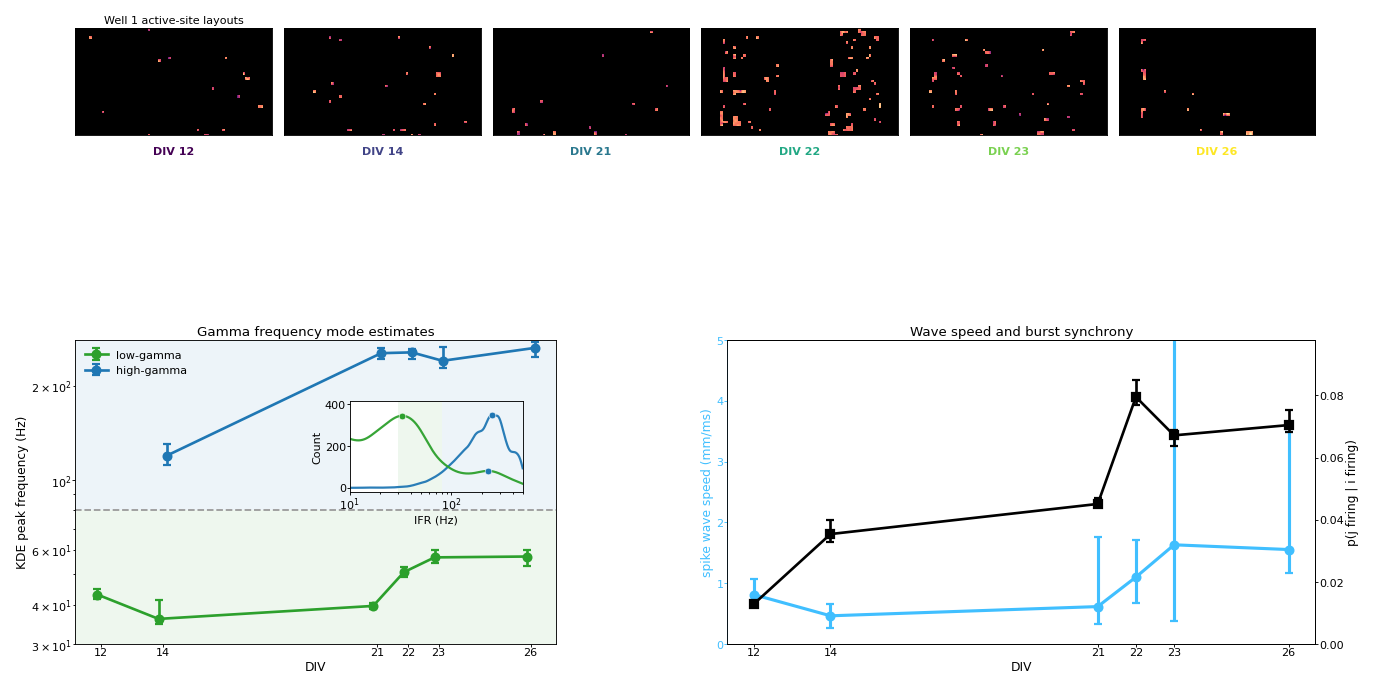

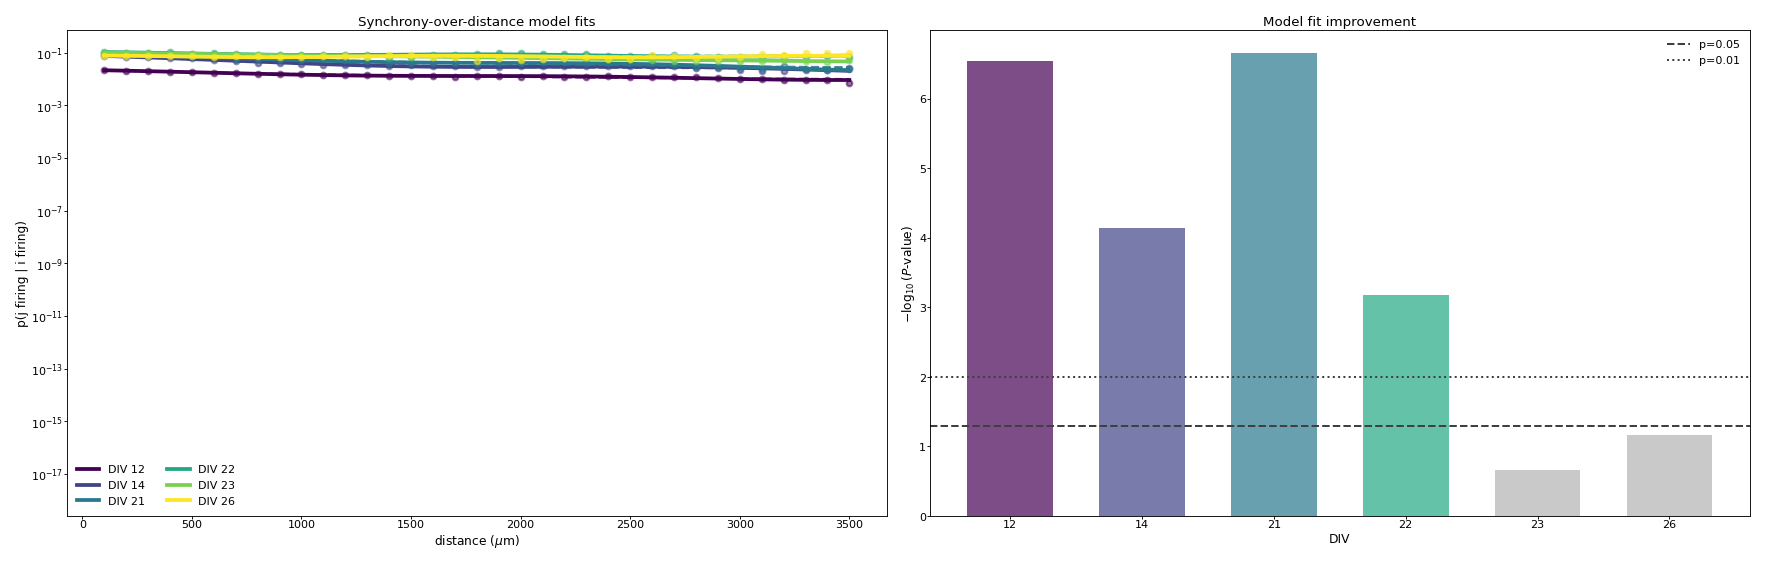

/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_67366/1706896089.py:521: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=FONT_SIZES["small"], ncol=2)


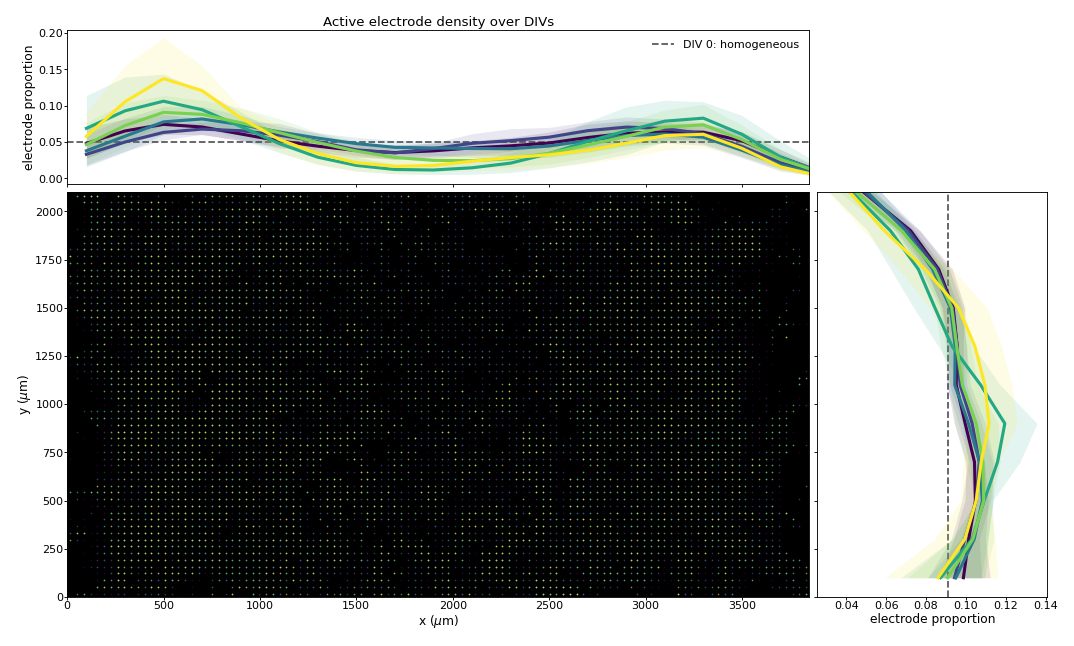

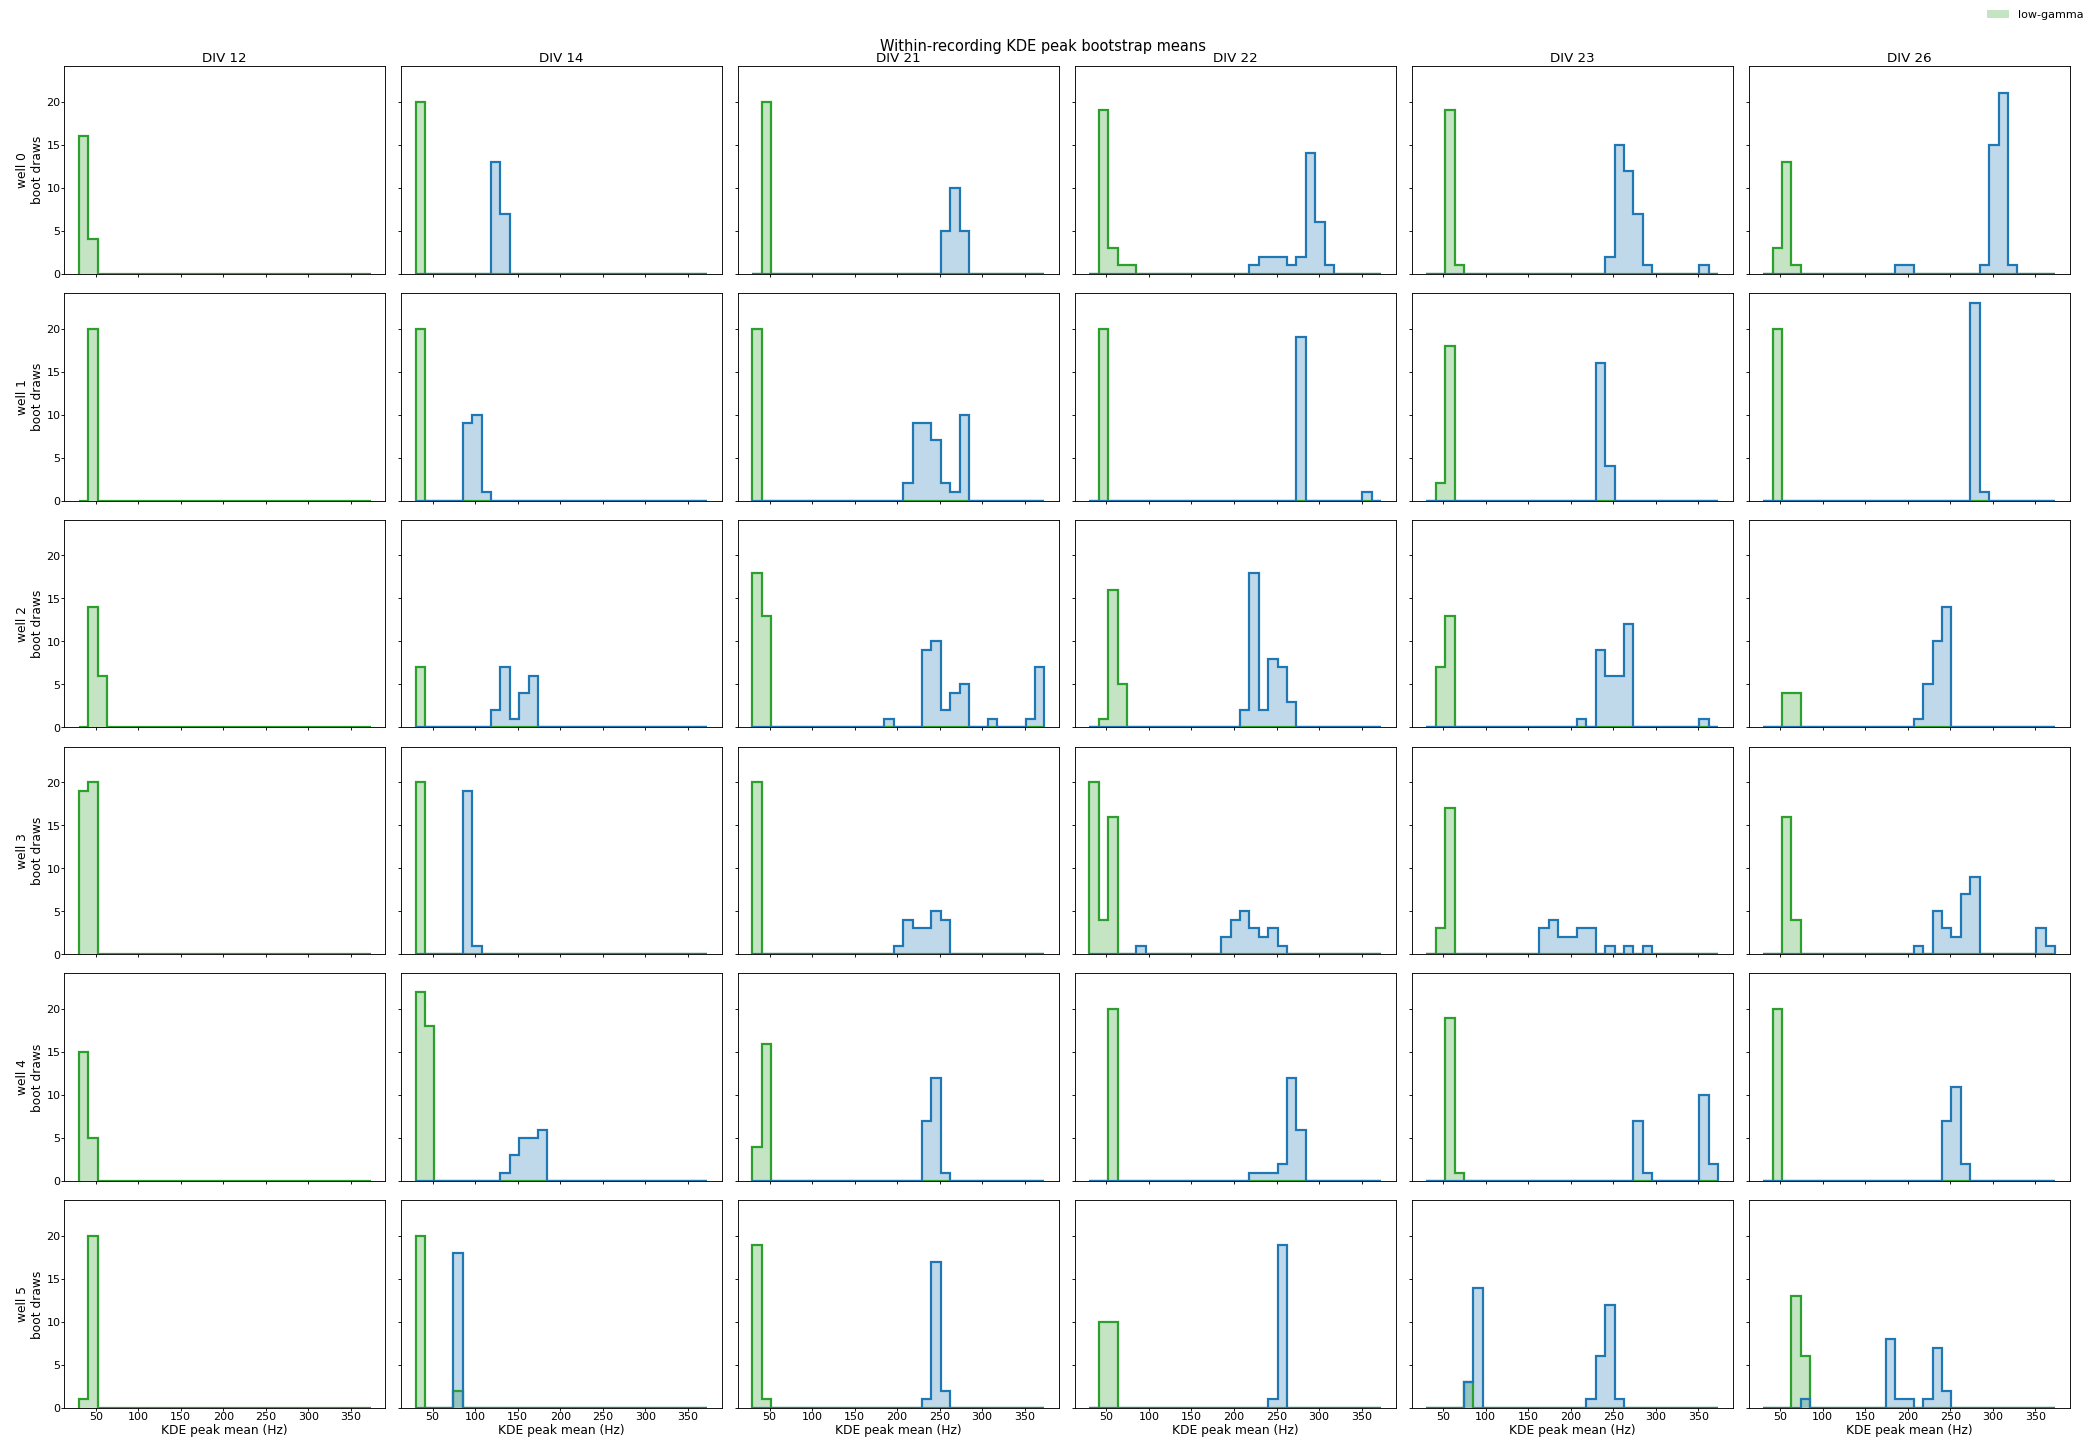

,div,gamma_peak_mean_hz,v_ax_um_s,v_eph_um_s,n_gamma_recordings,n_gamma_peaks,lrt_log10_p,v_ax_mm_per_ms,v_eph_mm_per_ms
0,12,43.155036,600000.0,83295.736378,6,0,-6.544285,0.6,0.083296
1,14,36.071000,600000.0,83295.736378,6,0,-4.140373,0.6,0.083296
2,21,39.680924,600000.0,83295.736378,6,0,-6.658379,0.6,0.083296
3,22,50.849170,600000.0,83295.736378,6,0,-3.183859,0.6,0.083296
4,23,56.681899,600000.0,83295.736378,6,0,-0.654336,0.6,0.083296
5,26,57.040545,600000.0,83295.736378,6,0,-1.167755,0.6,0.083296


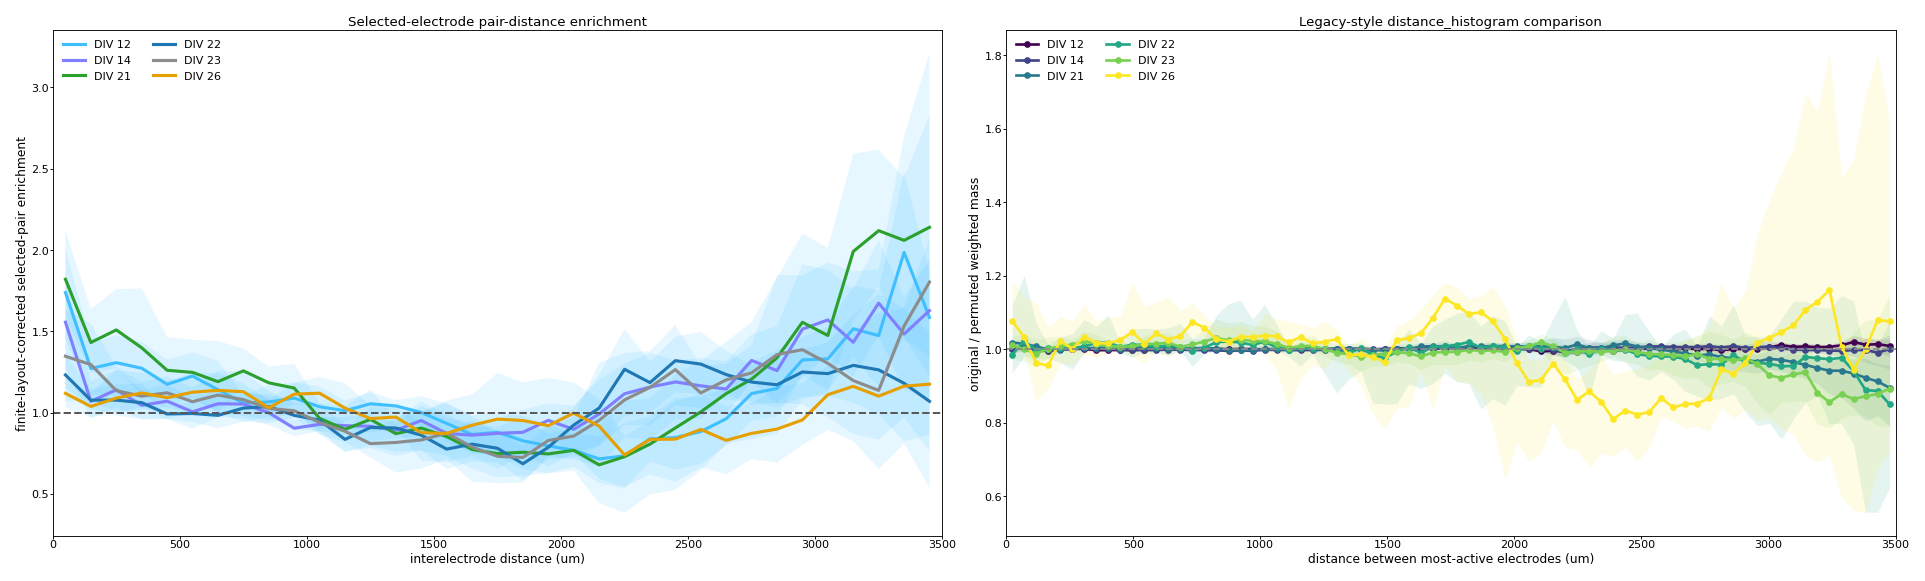

In [40]:
fig = plt.figure(figsize=(10, 5.8))
gs = fig.add_gridspec(2, 2, width_ratios=[0.9, 1.1], hspace=0.35, wspace=0.32)
axes_a = example_layout_div_axes_factory(fig, gs[0, :])
draw_example_layout_div_stack(axes_a)
draw_peak_band_ci_panel(fig.add_subplot(gs[1, 0]))
draw_wave_speed_synchrony_panel(fig.add_subplot(gs[1, 1]))
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
draw_model_fit_panel(axes[0], div=None)
draw_model_lrt_panel(axes[1])
fig.tight_layout()
plt.show()

fig = plt.figure(figsize=(10.5, 4.6))
gs = fig.add_gridspec(1, 1)
axes_spatial = spatial_differentiation_axes_factory(fig, gs[0, 0])
draw_spatial_differentiation_panel(None, axes_spatial)
plt.show()

fig = draw_recording_peak_bootstrap_matrix(figsize=(13, 9))
plt.show()

model_inputs = model_fit_by_div[[c for c in ["div", "gamma_peak_mean_hz", "v_ax_um_s", "v_eph_um_s", "n_gamma_recordings", "n_gamma_peaks", "lrt_log10_p"] if c in model_fit_by_div.columns]].copy() if not model_fit_by_div.empty else pd.DataFrame()
if not model_inputs.empty:
    model_inputs["v_ax_mm_per_ms"] = model_inputs["v_ax_um_s"] / 1_000_000.0
    model_inputs["v_eph_mm_per_ms"] = model_inputs["v_eph_um_s"] / 1_000_000.0
display(model_inputs)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.6), sharex=True)
draw_pair_distance_location_shuffle_ratio_panel(axes[0])
draw_pair_distance_legacy_permuted_ratio_panel(axes[1])
fig.tight_layout()
plt.show()


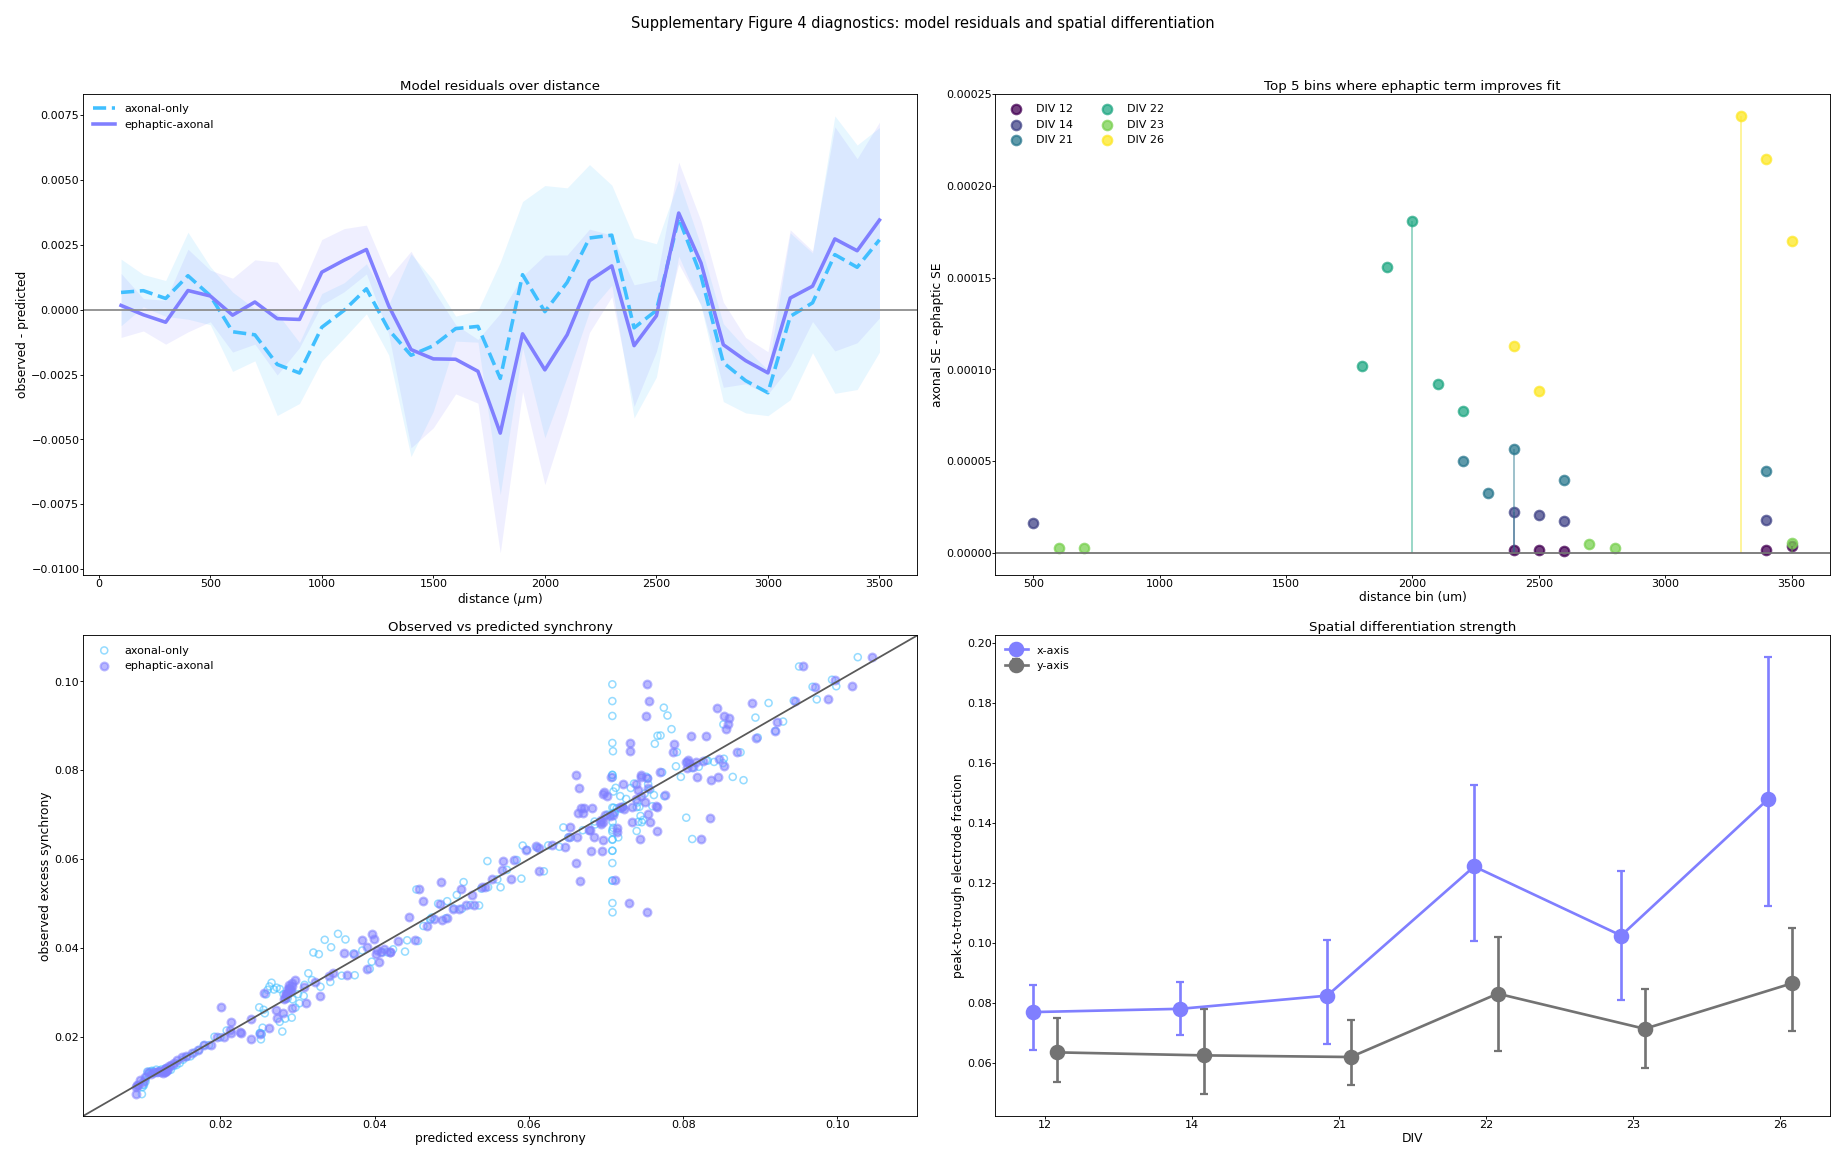

In [41]:
# Supplementary model/spatial diagnostics
# These panels are table-derived diagnostics for Figure 4 interpretation and are not part of compose_figure4().

def model_prediction_residual_table():
    cols = [
        "div", "distance_bin_center_um", "observed_excess_sync", "axonal_prediction", "ephaptic_prediction",
        "axonal_residual", "ephaptic_residual", "axonal_abs_residual", "ephaptic_abs_residual",
        "squared_error_improvement", "abs_error_improvement",
    ]
    if model_prediction_by_div is None or model_prediction_by_div.empty:
        return pd.DataFrame(columns=cols)
    df = model_prediction_by_div.copy()
    for col in ["div", "distance_bin_center_um", "observed_excess_sync", "axonal_prediction", "ephaptic_prediction"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["div", "distance_bin_center_um", "observed_excess_sync", "axonal_prediction", "ephaptic_prediction"])
    df["div"] = df["div"].astype(int)
    df["axonal_residual"] = df["observed_excess_sync"] - df["axonal_prediction"]
    df["ephaptic_residual"] = df["observed_excess_sync"] - df["ephaptic_prediction"]
    df["axonal_abs_residual"] = np.abs(df["axonal_residual"])
    df["ephaptic_abs_residual"] = np.abs(df["ephaptic_residual"])
    df["squared_error_improvement"] = df["axonal_residual"] ** 2 - df["ephaptic_residual"] ** 2
    df["abs_error_improvement"] = df["axonal_abs_residual"] - df["ephaptic_abs_residual"]
    return df[cols]


def draw_residuals_over_distance(ax, residual_df=None):
    df = model_prediction_residual_table() if residual_df is None else residual_df.copy()
    if df.empty:
        ax.text(0.5, 0.5, "No model residual table", ha="center", va="center", transform=ax.transAxes)
        return
    rows = []
    for distance, group in df.groupby("distance_bin_center_um"):
        row = {"distance_bin_center_um": float(distance)}
        for model in ["axonal", "ephaptic"]:
            vals = pd.to_numeric(group[f"{model}_residual"], errors="coerce").to_numpy(float)
            vals = vals[np.isfinite(vals)]
            row[f"{model}_mean"] = float(np.nanmean(vals)) if vals.size else np.nan
            row[f"{model}_sem"] = float(np.nanstd(vals, ddof=1) / np.sqrt(vals.size)) if vals.size > 1 else np.nan
        rows.append(row)
    summary = pd.DataFrame(rows).sort_values("distance_bin_center_um")
    x = summary["distance_bin_center_um"].to_numpy(float)
    specs = [
        ("axonal", PAPER_COLORS.get("axonal_only", "#40bfff"), "--", "axonal-only"),
        ("ephaptic", PAPER_COLORS.get("ephaptic_axonal", "#7b61ff"), "-", "ephaptic-axonal"),
    ]
    for model, color, linestyle, label in specs:
        mean = summary[f"{model}_mean"].to_numpy(float)
        sem = summary[f"{model}_sem"].to_numpy(float)
        ax.plot(x, mean, color=color, ls=linestyle, lw=1.6, label=label)
        ok = np.isfinite(mean) & np.isfinite(sem)
        if np.any(ok):
            ax.fill_between(x[ok], mean[ok] - sem[ok], mean[ok] + sem[ok], color=color, alpha=0.12, lw=0)
    ax.axhline(0, color="0.55", lw=0.8)
    ax.set_xlabel("distance ($\mu$m)")
    ax.set_ylabel("observed - predicted")
    ax.set_title("Model residuals over distance")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"])


def draw_strongest_improvement_bins(ax, residual_df=None, *, top_n=5):
    df = model_prediction_residual_table() if residual_df is None else residual_df.copy()
    if df.empty:
        ax.text(0.5, 0.5, "No model residual table", ha="center", va="center", transform=ax.transAxes)
        return
    colors = div_color_map()
    for div in REQUESTED_DIVS:
        sub = df[df["div"].astype(int) == int(div)].copy()
        if sub.empty:
            continue
        sub = sub.sort_values("squared_error_improvement", ascending=False).head(int(top_n))
        y = pd.to_numeric(sub["squared_error_improvement"], errors="coerce").to_numpy(float)
        x = pd.to_numeric(sub["distance_bin_center_um"], errors="coerce").to_numpy(float)
        ok = np.isfinite(x) & np.isfinite(y)
        if not np.any(ok):
            continue
        ax.scatter(x[ok], y[ok], s=18, color=colors.get(int(div), "0.4"), label=f"DIV {int(div)}", alpha=0.75)
        best = sub.iloc[0]
        ax.vlines(float(best["distance_bin_center_um"]), 0, float(best["squared_error_improvement"]), color=colors.get(int(div), "0.4"), lw=0.8, alpha=0.5)
    ax.axhline(0, color="0.45", lw=0.8)
    ax.set_xlabel("distance bin (um)")
    ax.set_ylabel("axonal SE - ephaptic SE")
    ax.set_title(f"Top {int(top_n)} bins where ephaptic term improves fit")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"], ncol=2)


def draw_observed_vs_predicted_panel(ax, residual_df=None):
    df = model_prediction_residual_table() if residual_df is None else residual_df.copy()
    if df.empty:
        ax.text(0.5, 0.5, "No model prediction table", ha="center", va="center", transform=ax.transAxes)
        return
    observed = df["observed_excess_sync"].to_numpy(float)
    axonal = df["axonal_prediction"].to_numpy(float)
    ephaptic = df["ephaptic_prediction"].to_numpy(float)
    ok_ax = np.isfinite(observed) & np.isfinite(axonal)
    ok_eph = np.isfinite(observed) & np.isfinite(ephaptic)
    ax.scatter(axonal[ok_ax], observed[ok_ax], s=10, facecolors="none", edgecolors=PAPER_COLORS.get("axonal_only", "#40bfff"), lw=0.7, alpha=0.55, label="axonal-only")
    ax.scatter(ephaptic[ok_eph], observed[ok_eph], s=12, color=PAPER_COLORS.get("ephaptic_axonal", "#7b61ff"), alpha=0.55, label="ephaptic-axonal")
    finite = np.concatenate([observed[ok_ax | ok_eph], axonal[ok_ax], ephaptic[ok_eph]])
    finite = finite[np.isfinite(finite)]
    if finite.size:
        lo, hi = float(np.nanmin(finite)), float(np.nanmax(finite))
        pad = 0.05 * max(hi - lo, 1e-6)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="0.35", lw=0.8)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("predicted excess synchrony")
    ax.set_ylabel("observed excess synchrony")
    ax.set_title("Observed vs predicted synchrony")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"])


def read_fraction_recording_table(axis):
    filename = f"selected_electrode_{axis}_fraction_recording.csv.gz"
    try:
        return read_table(filename)
    except Exception:
        path = table_path(filename)
        return pd.read_csv(path) if path.exists() else pd.DataFrame()


def spatial_differentiation_index_tables(metric="peak_to_trough", bootstrap_reps=5000, seed=0):
    rec_rows = []
    for axis in ["x", "y"]:
        df = read_fraction_recording_table(axis)
        if df.empty:
            continue
        value_col = "fraction_in_bin_smoothed" if "fraction_in_bin_smoothed" in df.columns else "fraction_in_bin"
        n_bins = max(1, int(df["bin_idx"].nunique()))
        homogeneous = 1.0 / n_bins
        for keys, group in df.groupby(["dataset", "well", "div", "recording_id"], dropna=False):
            values = pd.to_numeric(group.sort_values("bin_idx")[value_col], errors="coerce").to_numpy(float)
            values = values[np.isfinite(values)]
            if values.size == 0:
                continue
            peak_to_trough = float(np.nanmax(values) - np.nanmin(values))
            rms_deviation = float(np.sqrt(np.nanmean((values - homogeneous) ** 2)))
            rec_rows.append({
                "dataset": str(keys[0]),
                "well": int(keys[1]),
                "div": int(keys[2]),
                "recording_id": str(keys[3]),
                "axis": str(axis),
                "peak_to_trough": peak_to_trough,
                "rms_deviation_from_homogeneous": rms_deviation,
                "n_bins": n_bins,
                "homogeneous_fraction": homogeneous,
            })
    rec = pd.DataFrame(rec_rows)
    if rec.empty:
        return rec, pd.DataFrame()
    rng = np.random.default_rng(int(seed))
    summary_rows = []
    metric_col = str(metric)
    for (axis, div), group in rec.groupby(["axis", "div"], dropna=False):
        values = pd.to_numeric(group[metric_col], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        if values.size == 1:
            boot = values.copy()
        else:
            draw_idx = rng.integers(0, values.size, size=(int(bootstrap_reps), values.size))
            boot = np.nanmean(values[draw_idx], axis=1)
        summary_rows.append({
            "axis": str(axis),
            "div": int(div),
            "metric": metric_col,
            "mean": float(np.nanmean(values)),
            "median": float(np.nanmedian(values)),
            "ci_low": float(np.nanpercentile(boot, 2.5)),
            "ci_high": float(np.nanpercentile(boot, 97.5)),
            "n_recordings": int(values.size),
            "n_bootstrap": int(boot.size),
        })
    return rec, pd.DataFrame(summary_rows)


def draw_spatial_differentiation_index_panel(ax, summary_df=None):
    if summary_df is None or summary_df.empty:
        _, summary_df = spatial_differentiation_index_tables()
    if summary_df.empty:
        ax.text(0.5, 0.5, "No spatial differentiation index", ha="center", va="center", transform=ax.transAxes)
        return
    colors = {"x": PAPER_COLORS.get("ephaptic_axonal", "#7b61ff"), "y": "0.45"}
    offsets = {"x": -0.08, "y": 0.08}
    for axis in ["x", "y"]:
        sub = summary_df[summary_df["axis"].astype(str) == axis].copy().sort_values("div")
        if sub.empty:
            continue
        x = np.arange(len(sub)) + offsets[axis]
        mean = pd.to_numeric(sub["mean"], errors="coerce").to_numpy(float)
        lo = pd.to_numeric(sub["ci_low"], errors="coerce").to_numpy(float)
        hi = pd.to_numeric(sub["ci_high"], errors="coerce").to_numpy(float)
        yerr = np.vstack([np.maximum(0, mean - lo), np.maximum(0, hi - mean)])
        ax.errorbar(x, mean, yerr=yerr, color=colors[axis], marker="o", lw=1.2, capsize=2, label=f"{axis}-axis")
    xticks = np.arange(len(REQUESTED_DIVS))
    ax.set_xticks(xticks, [str(int(v)) for v in REQUESTED_DIVS])
    ax.set_xlabel("DIV")
    ax.set_ylabel("peak-to-trough electrode fraction")
    ax.set_title("Spatial differentiation strength")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"])


model_residual_diagnostics = model_prediction_residual_table()
spatial_index_recording_df, spatial_index_summary_df = spatial_differentiation_index_tables()
write_table(model_residual_diagnostics, "model_residual_diagnostics.csv")
write_table(spatial_index_recording_df, "spatial_differentiation_index_recording.csv")
write_table(spatial_index_summary_df, "spatial_differentiation_index_summary.csv")

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.0))
draw_residuals_over_distance(axes[0, 0], model_residual_diagnostics)
draw_strongest_improvement_bins(axes[0, 1], model_residual_diagnostics)
draw_observed_vs_predicted_panel(axes[1, 0], model_residual_diagnostics)
draw_spatial_differentiation_index_panel(axes[1, 1], spatial_index_summary_df)
fig.suptitle("Supplementary Figure 4 diagnostics: model residuals and spatial differentiation", y=1.02)
fig.tight_layout()
plt.show()


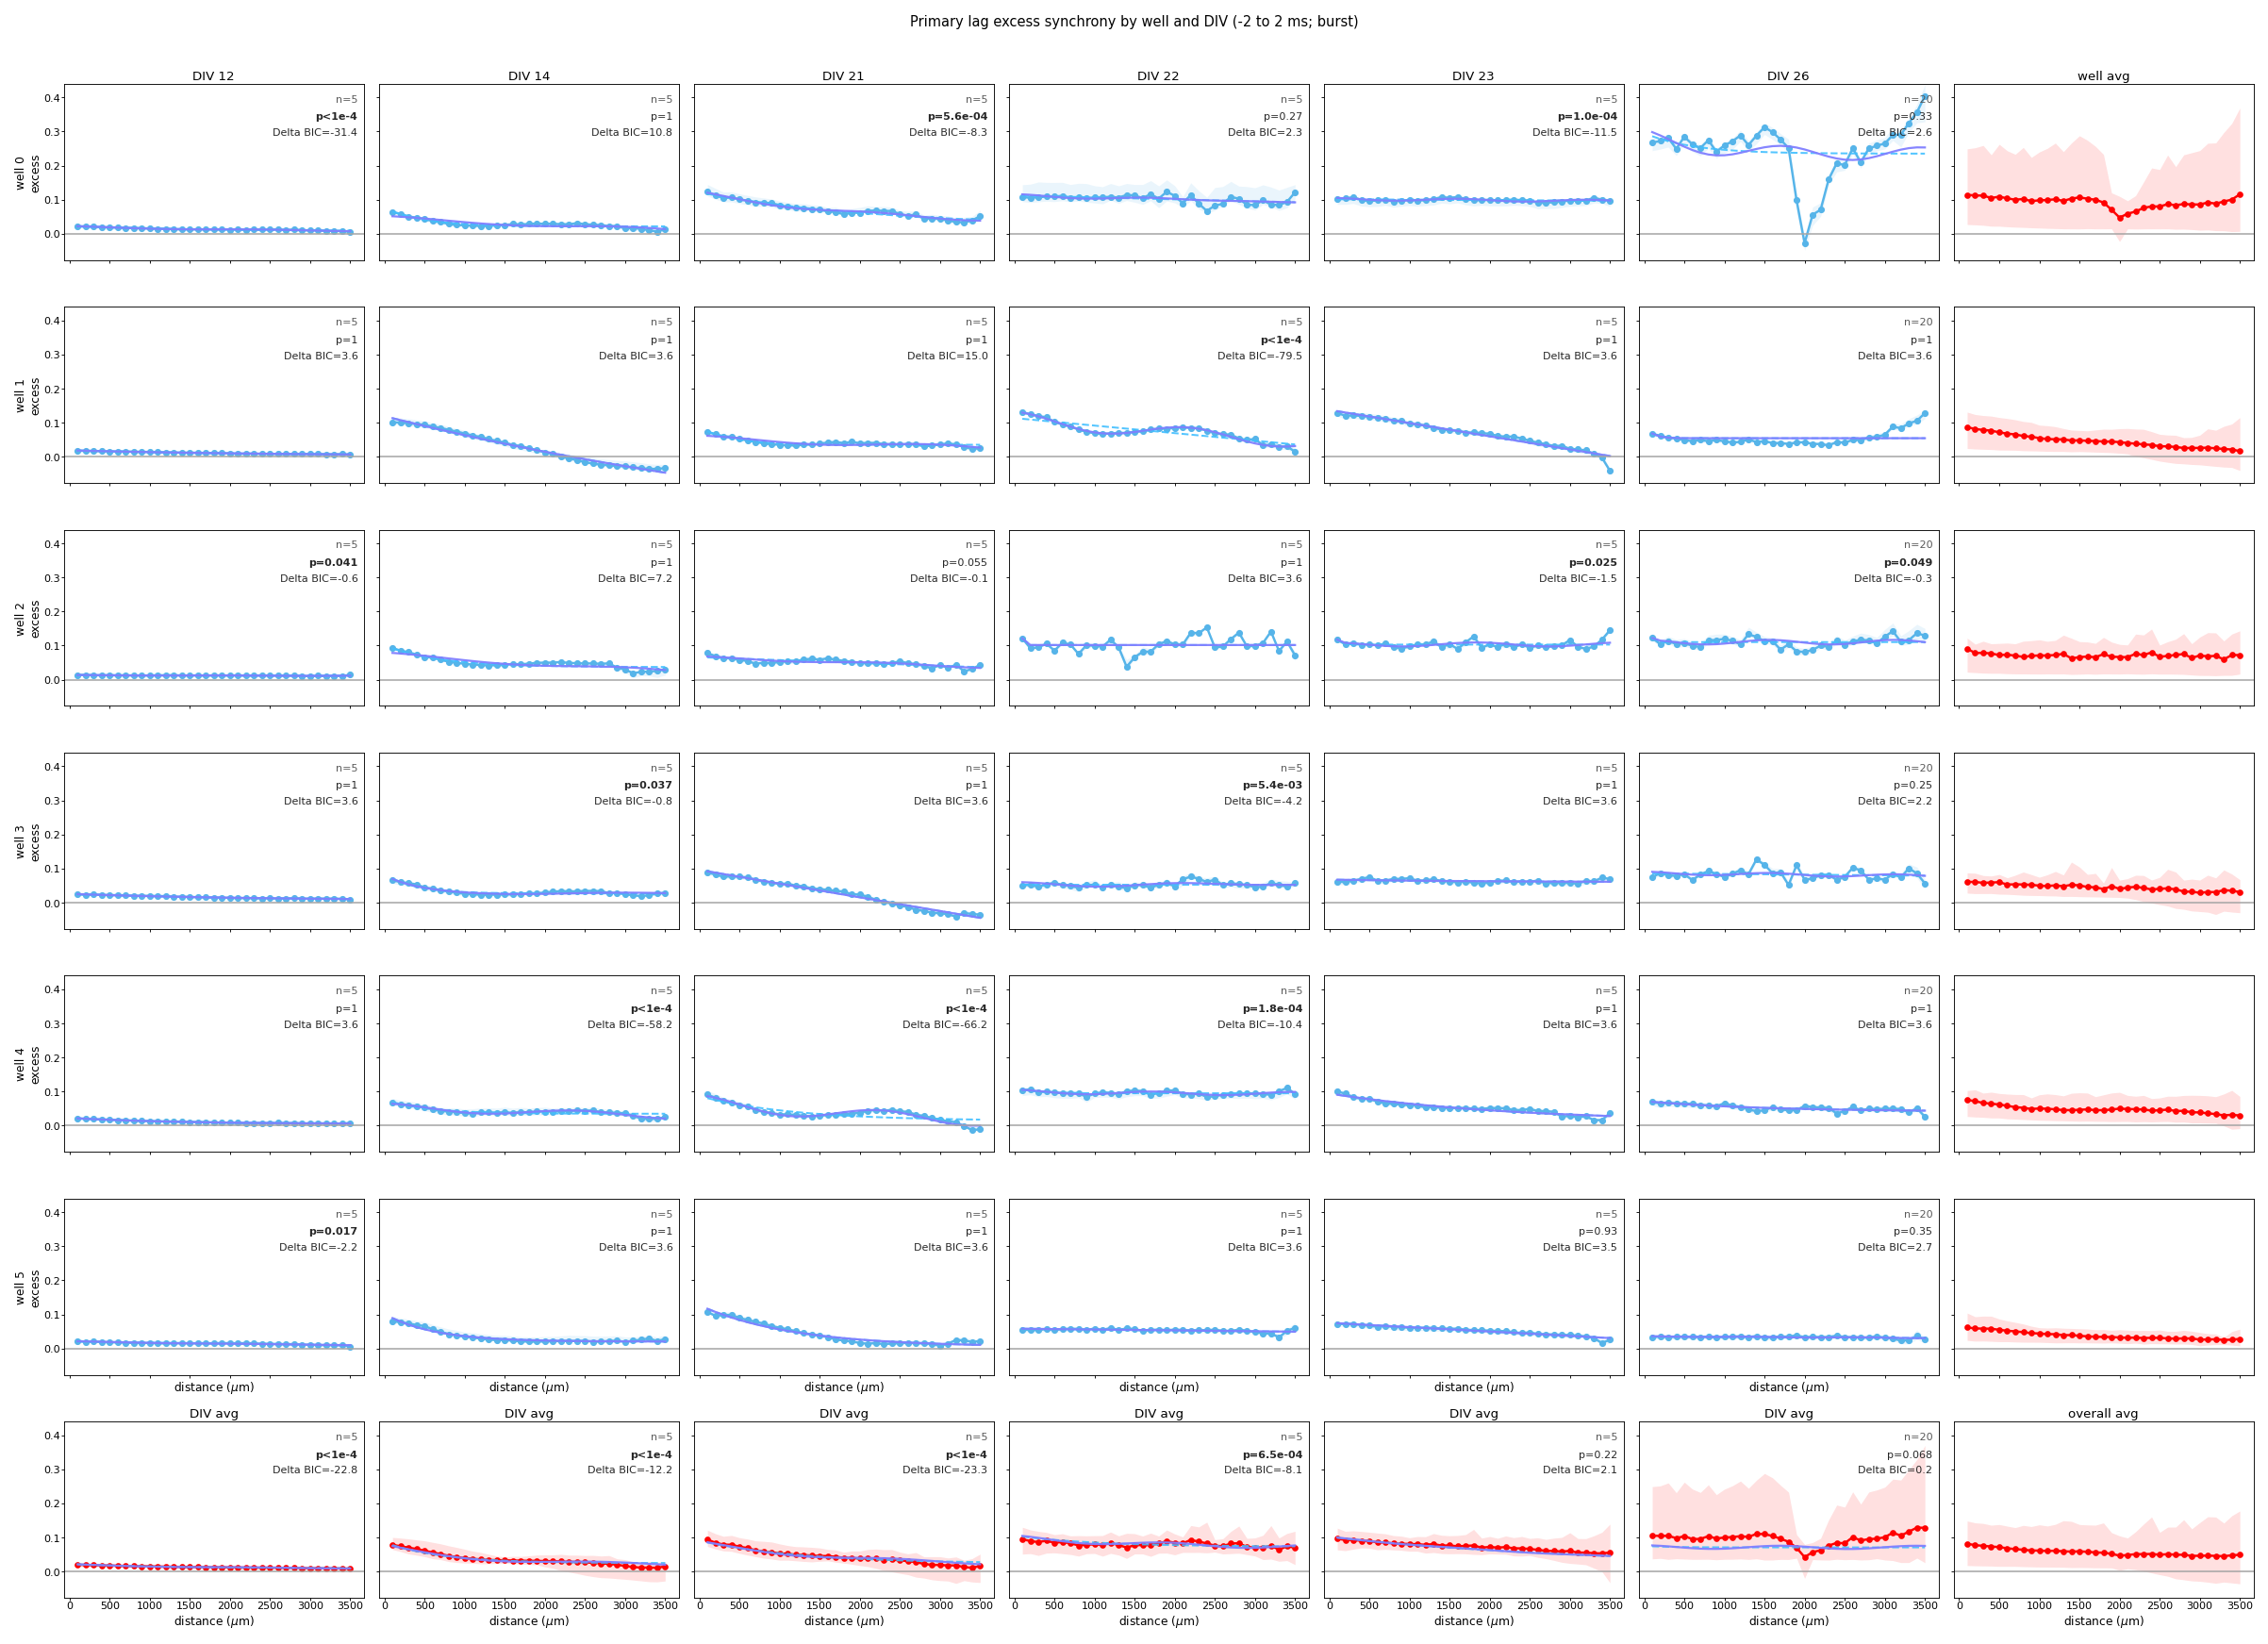

In [42]:

if not primary_distance_summary.empty:
    fig = draw_excess_synchrony_grid(primary_distance_summary, figsize=(15, 11))
    plt.show()
else:
    print("No primary synchrony summary was available.")


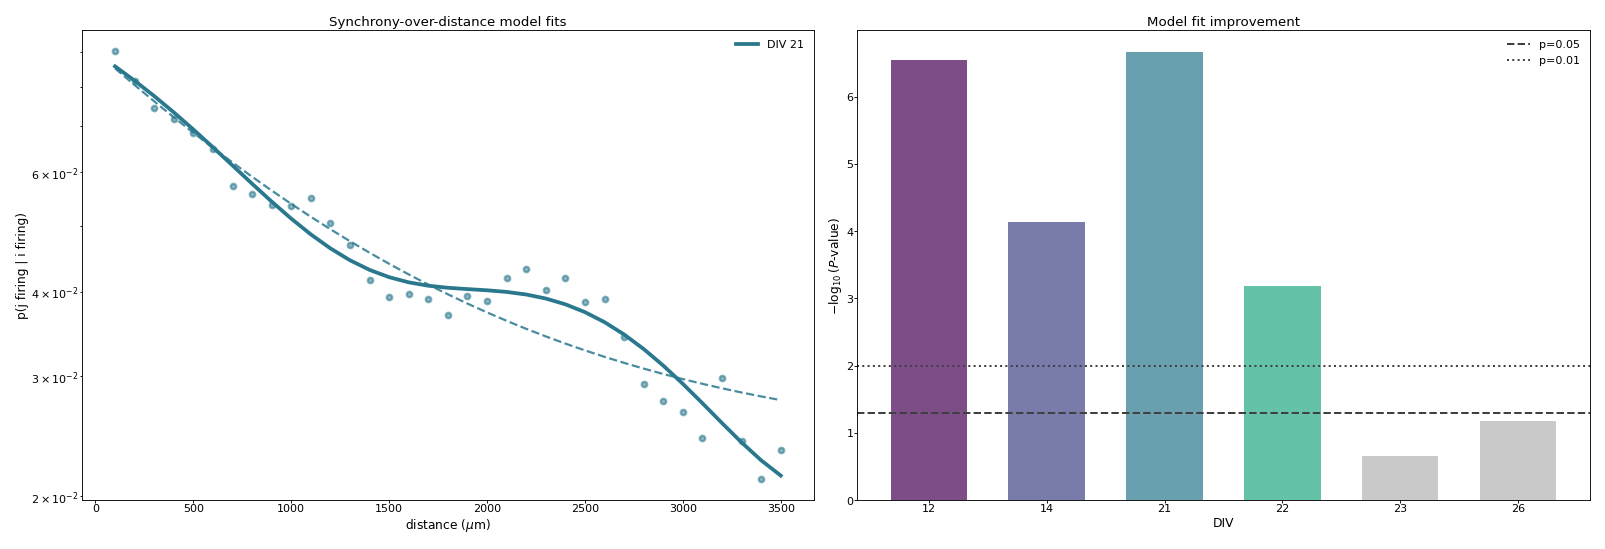

,div,skip_reason,n_points,model_peak_band,ephaptic_coefficient_lower_bound,n_gamma_peaks,n_gamma_recordings,gamma_peak_mean_hz,v_eph_um_s,v_ax_um_s,...,lrt_log10_p_bootstrap_mean,lrt_log10_p_bootstrap_median,lrt_log10_p_bootstrap_n,lrt_log10_p_ci_low,lrt_log10_p_ci_high,lrt_p_value_bootstrap_mean,lrt_p_value_bootstrap_median,lrt_p_value_bootstrap_n,lrt_p_value_ci_low,lrt_p_value_ci_high
0,12,,35,low_gamma,0.0,0,6,43.155036,83295.736378,600000.0,...,-7.505129,-7.191091,1000,-11.279257,-5.030841,0.000001,6.440338e-08,1000,5.257062e-12,0.000009
1,14,,35,low_gamma,0.0,0,6,36.071000,83295.736378,600000.0,...,-6.534772,-6.025836,1000,-11.410309,-3.096933,0.000079,9.422453e-07,1000,3.887687e-12,0.000800
2,21,,35,low_gamma,0.0,0,6,39.680924,83295.736378,600000.0,...,-7.001946,-7.706619,1000,-9.717295,-1.685969,0.003557,1.965085e-08,1000,1.917364e-10,0.020608
3,22,,35,low_gamma,0.0,0,6,50.849170,83295.736378,600000.0,...,-2.983003,-2.924726,1000,-5.353057,-0.726578,0.017394,1.189251e-03,1000,4.435509e-06,0.187762
4,23,,35,low_gamma,0.0,0,6,56.681899,83295.736378,600000.0,...,-1.351913,-1.646060,1000,-3.016803,0.000000,0.325413,2.262432e-02,1000,9.620488e-04,1.000000
5,26,,35,low_gamma,0.0,0,6,57.040545,83295.736378,600000.0,...,-1.060264,-1.073319,1000,-1.967304,0.000000,0.164479,8.446616e-02,1000,1.078193e-02,1.000000


In [43]:

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
draw_model_fit_panel(axes[0], div=21)
draw_model_lrt_panel(axes[1])
fig.tight_layout()
plt.show()
model_fit_by_div



## Paper-Reportable Statistics


In [44]:
def build_paper_report_tables():
    peak_cols = [
        "div", "band", "n_recordings", "n_recording_states", "n_peak_draws", "mean_peak_hz", "median_recording_peak_hz", "ci_low_hz", "ci_high_hz",
    ]
    peak_stats = peak_band_summary_df[[c for c in peak_cols if c in peak_band_summary_df.columns]].copy() if not peak_band_summary_df.empty else pd.DataFrame(columns=peak_cols)

    wave_cols = [
        "div", "source", "speed_um_per_ms", "speed_ci_low_um_per_ms", "speed_ci_high_um_per_ms", "n_bootstrap_samples", "n_wells",
    ]
    wave_stats = wave_summary_df[[c for c in wave_cols if c in wave_summary_df.columns]].copy() if not wave_summary_df.empty else pd.DataFrame(columns=wave_cols)

    model_cols = [
        "div", "n_points", "model_peak_band", "n_gamma_recordings", "n_gamma_peaks", "gamma_peak_mean_hz", "gamma_peak_mean_hz_bootstrap_median", "gamma_peak_mean_hz_ci_low", "gamma_peak_mean_hz_ci_high",
        "v_eph_um_s", "v_ax_um_s", "v_ax_mm_per_ms", "v_ax_source", "axonal_decay_um", "ephaptic_axonal_decay_um", "correlation_coefficient",
        "correlation_coefficient_bootstrap_median", "correlation_coefficient_ci_low", "correlation_coefficient_ci_high",
        "axonal_rss", "ephaptic_rss", "axonal_r2", "ephaptic_r2", "axonal_aic", "ephaptic_aic", "axonal_bic", "ephaptic_bic",
        "rss_improvement_fraction", "rss_improvement_fraction_bootstrap_median", "rss_improvement_fraction_ci_low", "rss_improvement_fraction_ci_high",
        "delta_aic_ephaptic_minus_axonal", "delta_aic_ephaptic_minus_axonal_bootstrap_median", "delta_aic_ephaptic_minus_axonal_ci_low", "delta_aic_ephaptic_minus_axonal_ci_high",
        "delta_bic_ephaptic_minus_axonal", "delta_bic_ephaptic_minus_axonal_bootstrap_median", "delta_bic_ephaptic_minus_axonal_ci_low", "delta_bic_ephaptic_minus_axonal_ci_high",
        "lrt_stat", "lrt_df", "lrt_p_value", "lrt_log10_p", "lrt_log10_p_bootstrap_median", "lrt_log10_p_ci_low", "lrt_log10_p_ci_high",
    ]
    model_stats = model_fit_by_div.copy()
    if "skip_reason" in model_stats:
        model_stats = model_stats[model_stats["skip_reason"].fillna("").astype(str) == ""]
    model_stats = model_stats[[c for c in model_cols if c in model_stats.columns]].copy() if not model_stats.empty else pd.DataFrame(columns=model_cols)

    return peak_stats, wave_stats, model_stats

paper_peak_stats, paper_wave_stats, paper_model_stats = build_paper_report_tables()

try:
    v_eph_um_s, v_eph_mm_s, v_eph_source = load_fixed_ephaptic_speed_um_s()
    print(f"Fixed ephaptic propagation speed input: {v_eph_mm_s:.2f} mm/s = {v_eph_um_s:.0f} um/s; source DIV {v_eph_source['fixed_ephaptic_speed_div']} ({v_eph_source['fixed_ephaptic_speed_scope']}).")
except Exception as exc:
    print(f"Fixed ephaptic propagation speed input unavailable: {exc}")

print(f"Fixed axonal propagation speed input: {FIXED_AXONAL_SPEED_MM_PER_MS:.3f} mm/ms = {fixed_model_axonal_speed_um_s():.0f} um/s; source fixed_constant.")
print(f"Peak-frequency bootstrap: {PEAK_BAND_BOOTSTRAP_REPS} recording-level draws per DIV × band; model peak band = {band_label(MODEL_PEAK_BAND)!r}.")
print("\nPeak-band frequency statistics:")
display(paper_peak_stats)
print("\nAxonal wave-speed statistics:")
display(paper_wave_stats)
print("\nModel-comparison statistics:")
display(paper_model_stats)

write_table(paper_peak_stats, "paper_report_peak_band_stats.csv")
write_table(paper_wave_stats, "paper_report_wave_speed_stats.csv")
write_table(paper_model_stats, "paper_report_model_comparison_stats.csv")


Fixed ephaptic propagation speed input: 83.30 mm/s = 83296 um/s; source DIV 12 (figure3_hierarchical_all_wells).
Fixed axonal propagation speed input: 0.600 mm/ms = 600000 um/s; source fixed_constant.
Peak-frequency bootstrap: 20 recording-level draws per DIV × band; model peak band = 'low-gamma'.

Peak-band frequency statistics:


,div,band,n_recordings,n_recording_states,n_peak_draws,mean_peak_hz,median_recording_peak_hz,ci_low_hz,ci_high_hz
0,12,low_gamma,6,8,140,43.155036,43.165971,41.732360,45.048569
1,14,high_gamma,6,6,118,119.571100,111.830063,111.790216,129.995525
2,14,low_gamma,6,8,129,36.071000,35.156366,34.722363,41.303031
3,21,high_gamma,6,8,184,254.072627,244.568357,242.847513,264.113242
4,21,low_gamma,6,7,131,39.680924,39.548334,38.936685,40.542112
5,22,high_gamma,6,10,157,255.538658,251.826275,243.722007,262.605145
6,22,low_gamma,6,9,146,50.849170,52.576495,48.953822,52.979785
7,23,high_gamma,6,9,207,240.221102,243.365187,228.149519,265.638232
8,23,low_gamma,6,6,103,56.681899,57.011234,54.468947,59.783184
9,26,high_gamma,6,11,173,264.018902,254.480228,246.868100,275.454359



Axonal wave-speed statistics:


,div,source,speed_um_per_ms,speed_ci_low_um_per_ms,speed_ci_high_um_per_ms,n_bootstrap_samples,n_wells
0,12,hierarchical_per_well,810.646629,653.706418,1062.692323,2000,6
1,14,hierarchical_per_well,463.658307,259.971046,649.739257,2000,6
2,21,hierarchical_per_well,615.266404,336.781322,1759.357418,2000,6
3,22,hierarchical_per_well,1100.085469,673.956183,1718.343477,2000,6
4,23,hierarchical_per_well,1631.133303,384.041746,5586.366353,2000,6
5,26,hierarchical_per_well,1553.180466,1159.802567,3492.855490,2000,6



Model-comparison statistics:


,div,n_points,model_peak_band,n_gamma_recordings,n_gamma_peaks,gamma_peak_mean_hz,gamma_peak_mean_hz_bootstrap_median,gamma_peak_mean_hz_ci_low,gamma_peak_mean_hz_ci_high,v_eph_um_s,...,delta_bic_ephaptic_minus_axonal_bootstrap_median,delta_bic_ephaptic_minus_axonal_ci_low,delta_bic_ephaptic_minus_axonal_ci_high,lrt_stat,lrt_df,lrt_p_value,lrt_log10_p,lrt_log10_p_bootstrap_median,lrt_log10_p_ci_low,lrt_log10_p_ci_high
0,12,35,low_gamma,6,0,43.155036,43.081679,41.485144,45.405532,83295.736378,...,-25.670824,-44.033353,-16.091743,26.344901,1,2.855718e-07,-6.544285,-7.191091,-11.279257,-5.030841
1,14,35,low_gamma,6,0,36.071000,35.494430,34.618898,42.058770,83295.736378,...,-20.487317,-44.624982,-7.685985,15.747556,1,7.238139e-05,-4.140373,-6.025836,-11.410309,-3.096933
2,21,35,low_gamma,6,0,39.680924,39.633265,38.830306,40.875718,83295.736378,...,-27.973408,-36.993756,-1.804312,26.852461,1,2.195945e-07,-6.658379,-7.706619,-9.717295,-1.685969
3,22,35,low_gamma,6,0,50.849170,50.401835,48.360845,53.019458,83295.736378,...,-6.951622,-17.511434,1.819524,11.613216,1,6.548484e-04,-3.183859,-2.924726,-5.353057,-0.726578
4,23,35,low_gamma,6,0,56.681899,56.496305,54.233484,60.545065,83295.736378,...,-1.644409,-7.343870,3.555348,1.493670,1,2.216480e-01,-0.654336,-1.646060,-3.016803,0.000000
5,26,35,low_gamma,6,0,57.040545,57.218310,51.730532,60.218726,83295.736378,...,0.578542,-2.945563,3.555348,3.331649,1,6.795870e-02,-1.167755,-1.073319,-1.967304,0.000000


PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure4_activity_distance/tables/paper_report_model_comparison_stats.csv')

## Compose Figure 4 Draft


## Paper Reporting CSVs

Writes one methods CSV and one results CSV for paper reporting. These summarize the peak-frequency, wave-speed, synchrony, model-test, and spatial-differentiation statistics already present in the figure cache.

In [45]:

# Figure 4 paper-facing reporting tables. These summarize panel inputs, tests, and model comparisons.
REPORT_TABLE_DIR = TABLE_DIR
REPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)


def _method_row(parameter, value, meaning, units=""):
    return {
        "figure": "figure_4",
        "parameter": str(parameter),
        "value": str(value),
        "units": str(units),
        "meaning": str(meaning),
    }


def _result_row(section, statistic, value, *, entity="", units="", ci_low=np.nan, ci_high=np.nan, n=np.nan, note=""):
    return {
        "figure": "figure_4",
        "section": str(section),
        "entity": str(entity),
        "statistic": str(statistic),
        "value": value,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "units": str(units),
        "n": n,
        "note": str(note),
    }


def _inferred_distance_bin_um(df):
    if isinstance(df, pd.DataFrame) and "distance_bin_center_um" in df and not df.empty:
        vals = np.sort(pd.to_numeric(df["distance_bin_center_um"], errors="coerce").dropna().unique())
        diffs = np.diff(vals)
        diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
        if diffs.size:
            return float(np.nanmedian(diffs))
    return np.nan

method_rows = [
    _method_row("dataset", DATASET, "Dataset used for Figure 4 spike/activity-distance analyses."),
    _method_row("requested_wells", REQUESTED_WELLS, "Wells included based on RUN_ALL_WELLS/WELL configuration."),
    _method_row("requested_divs", REQUESTED_DIVS, "DIVs included based on RUN_ALL_DIVS/DIV configuration."),
    _method_row("start_sec", START_SEC, "Start of recording window used for spike-state analysis.", "s"),
    _method_row("end_sec", END_SEC, "End of recording window used for spike-state analysis.", "s"),
    _method_row("top_start", TOP_START, "Lower rank bound for selected active electrodes."),
    _method_row("top_stop", TOP_STOP, "Upper rank bound for selected active electrodes."),
    _method_row("ifr_grid_hz", IFR_GRID_HZ, "Population IFR sampling grid.", "Hz"),
    _method_row("smooth_sigma_sec", SMOOTH_SIGMA_SEC, "Gaussian smoothing sigma for population IFR.", "s"),
    _method_row("high_activity_mad_scale", HIGH_ACTIVITY_MAD_SCALE, "MAD multiplier for high-activity threshold."),
    _method_row("high_activity_min_duration_ms", HIGH_ACTIVITY_MIN_DURATION_MS, "Minimum high-activity period duration.", "ms"),
    _method_row("primary_lag_window_ms", PRIMARY_LAG_WINDOW_MS, "Spike synchrony lag window used for excess synchrony curves.", "ms"),
    _method_row("distance_bin_um", _inferred_distance_bin_um(primary_distance_summary), "Radial distance-bin width for synchrony and density panels.", "um"),
    _method_row("model_peak_band", band_label(MODEL_PEAK_BAND), "Peak-frequency band used as model correlation-function frequency input."),
    _method_row("peak_band_split_hz", PEAK_BANDS_HZ.get("low_gamma", (np.nan, np.nan))[1], "Boundary between low-gamma and high-gamma peak bands.", "Hz"),
    _method_row("peak_band_bootstrap_reps", PEAK_BAND_BOOTSTRAP_REPS, "Within-recording peak bootstrap draws used for DIV-level peak estimates."),
    _method_row("fixed_ephaptic_speed_source_div", FIXED_EPHAPTIC_SPEED_DIV, "DIV whose Figure 3 LFP event-front speed fixes v_eph."),
    _method_row("fixed_axonal_speed_mm_per_ms", FIXED_AXONAL_SPEED_MM_PER_MS, "Fixed axonal wave speed used in model fitting.", "mm/ms"),
    _method_row("lambda_eph_um", FIXED_LAMBDA_EPH_UM, "Fixed ephaptic wavelength/length parameter for the correlation kernel; not fitted.", "um"),
    _method_row("model_ephaptic_coefficient_min", MODEL_EPHAPTIC_COEFFICIENT_MIN, "Lower bound imposed on the additive ephaptic-axonal coefficient."),
    _method_row("model_bootstrap_reps", MODEL_FIT_BOOTSTRAP_REPS, "Bootstrap replicates for model-fit uncertainty."),
    _method_row("spatial_fraction_bin_um", SPATIAL_DENSITY_BIN_UM, "Spatial active-site fraction bin width.", "um"),
    _method_row("spatial_fraction_smooth_sigma_bins", SPATIAL_FRACTION_SMOOTH_SIGMA_BINS, "Gaussian smoothing sigma applied after per-recording spatial fraction calculation.", "bins"),
    _method_row("pair_distance_ratio_bin_um", PAIR_DISTANCE_RATIO_BIN_UM, "Distance-bin width for finite-layout-corrected selected-electrode pair-distance enrichment against the location-shuffled layout null.", "um"),
    _method_row("pair_distance_ratio_max_um", PAIR_DISTANCE_RATIO_MAX_UM, "Maximum interelectrode distance included in the location-shuffled pair-distance ratio diagnostic.", "um"),
    _method_row("pair_distance_ratio_top_n", PAIR_DISTANCE_RATIO_TOP_N, "Number of most-active selected electrodes retained per recording for the location-shuffled pair-distance enrichment diagnostic.", "electrodes"),
    _method_row("pair_distance_legacy_bins", PAIR_DISTANCE_LEGACY_BINS, "Number of 0-3500 um bins used by the legacy-style distance_histogram original/permuted comparison."),
    _method_row("pair_distance_legacy_perm_seed", PAIR_DISTANCE_LEGACY_PERM_SEED, "Seed for recording-level electrode-mapping permutation in the legacy-style distance_histogram comparison."),
    _method_row("pair_distance_location_shuffle_null", "analytic_expected_layout_pairs", "Null denominator is expected finite-size boundary-weighted selected-pair mass after randomly assigning selected labels over recorded electrode locations."),
    _method_row("simulation_target_fraction", SIMULATION_TARGET_FRACTION, "Final retained target fraction for Figure 4 simulation panels."),
    _method_row("simulation_n_replicates", SIMULATION_N_REPLICATES, "Independent simulation replicates unioned for simulation layout panels."),
]

result_rows = []
if not peak_band_summary_df.empty:
    for _, row in peak_band_summary_df.iterrows():
        entity = f"DIV {int(row['div'])}; band={row['band']}"
        for col, units in {
            "mean_peak_hz": "Hz", "ci_low_hz": "Hz", "ci_high_hz": "Hz", "n_recordings": "recordings", "n_peak_draws": "draws",
            "median_recording_peak_hz": "Hz",
        }.items():
            if col in row:
                result_rows.append(_result_row("activity_frequency_peaks", col, row[col], entity=entity, units=units))


if not activity_summary_df.empty and "n_recorded_electrodes" in activity_summary_df.columns:
    for _, row in activity_summary_df.iterrows():
        entity = f"well {int(row['well'])}; DIV {int(row['div'])}"
        result_rows.append(_result_row("recording_electrode_counts", "n_recorded_electrodes", row["n_recorded_electrodes"], entity=entity, units="electrodes"))
        if "n_refs" in row:
            result_rows.append(_result_row("recording_electrode_counts", "n_selected_ref_electrodes", row["n_refs"], entity=entity, units="electrodes"))

if not wave_summary_df.empty:
    for _, row in wave_summary_df.iterrows():
        entity = f"DIV {int(row['div'])}" if "div" in row and pd.notna(row["div"]) else "DIV"
        for col, units in {
            "speed_um_per_ms": "um/ms", "speed_ci_low_um_per_ms": "um/ms", "speed_ci_high_um_per_ms": "um/ms",
            "speed_mm_per_ms": "mm/ms", "n_bootstrap_samples": "samples", "n_wells": "wells",
        }.items():
            if col in row:
                result_rows.append(_result_row("axonal_wave_speed", col, row[col], entity=entity, units=units))

if not overall_burst_synchrony_by_div.empty:
    for _, row in overall_burst_synchrony_by_div.iterrows():
        entity = f"DIV {int(row['div'])}"
        for col in ["overall_excess_sync", "ci_low", "ci_high", "n_bootstrap_samples"]:
            if col in row:
                result_rows.append(_result_row("overall_burst_synchrony", col, row[col], entity=entity))

if not model_fit_by_div.empty:
    valid = model_fit_by_div.copy()
    if "skip_reason" in valid:
        valid = valid[valid["skip_reason"].fillna("").astype(str) == ""]
    for _, row in valid.iterrows():
        entity = f"DIV {int(row['div'])}"
        for col, units in {
            "gamma_peak_mean_hz": "Hz", "gamma_peak_mean_hz_ci_low": "Hz", "gamma_peak_mean_hz_ci_high": "Hz",
            "v_eph_um_s": "um/s", "v_ax_um_s": "um/s", "v_ax_mm_per_ms": "mm/ms",
            "axonal_decay_um": "um", "ephaptic_axonal_decay_um": "um", "correlation_coefficient": "",
            "axonal_rss": "", "ephaptic_rss": "", "rss_improvement_fraction": "fraction",
            "axonal_bic": "", "ephaptic_bic": "", "delta_bic_ephaptic_minus_axonal": "",
            "lrt_stat": "", "lrt_df": "df", "lrt_p_value": "p", "lrt_log10_p": "-log10(p)",
        }.items():
            if col in row:
                result_rows.append(_result_row("aggregate_model_fit", col, row[col], entity=entity, units=units))

if not model_fit_by_recording.empty:
    for div, group in model_fit_by_recording.groupby("div", dropna=False):
        valid = group.copy()
        if "skip_reason" in valid:
            valid = valid[valid["skip_reason"].fillna("").astype(str) == ""]
        if valid.empty:
            continue
        n_valid = int(len(valid))
        n_lrt_sig = int(np.sum(pd.to_numeric(valid.get("lrt_p_value", np.nan), errors="coerce") < 0.05))
        n_bic_favors = int(np.sum(pd.to_numeric(valid.get("delta_bic_ephaptic_minus_axonal", np.nan), errors="coerce") < 0.0))
        lrt_df_values = pd.to_numeric(valid.get("lrt_df", pd.Series(dtype=float)), errors="coerce").dropna().unique()
        lrt_df_value = int(lrt_df_values[0]) if len(lrt_df_values) else np.nan
        result_rows.extend([
            _result_row("recording_model_fit", "n_valid_recordings", n_valid, entity=f"DIV {int(div)}", units="recordings"),
            _result_row("recording_model_fit", "lrt_df", lrt_df_value, entity=f"DIV {int(div)}", units="df", note="Likelihood-ratio test degrees of freedom for the added ephaptic-axonal coefficient."),
            _result_row("recording_model_fit", "n_lrt_p_lt_0_05", n_lrt_sig, entity=f"DIV {int(div)}", units="recordings", note="Likelihood-ratio test favoring ephaptic-axonal model at p<0.05."),
            _result_row("recording_model_fit", "n_delta_bic_lt_0", n_bic_favors, entity=f"DIV {int(div)}", units="recordings", note="BIC lower for ephaptic-axonal than axonal-only."),
        ])

for axis_name, df in [("x", selected_electrode_x_fraction), ("y", selected_electrode_y_fraction)]:
    if isinstance(df, pd.DataFrame) and not df.empty:
        for div, group in df.groupby("div", dropna=False):
            y_col = next((col for col in ["mean_fraction_in_bin", "fraction_mean", "fraction_in_bin_smoothed", "fraction_in_bin"] if col in group.columns), None)
            if y_col is None:
                continue
            vals = pd.to_numeric(group[y_col], errors="coerce").to_numpy(float)
            vals = vals[np.isfinite(vals)]
            result_rows.append(_result_row("selected_electrode_spatial_fraction", f"{axis_name}_max_bin_fraction", float(np.nanmax(vals)) if vals.size else np.nan, entity=f"DIV {int(div)}"))
            result_rows.append(_result_row("selected_electrode_spatial_fraction", f"{axis_name}_fraction_entropy", float(-np.nansum(vals * np.log(vals + 1e-12))) if vals.size else np.nan, entity=f"DIV {int(div)}", note=f"Computed from {y_col}."))

if "spatial_index_summary_df" in globals() and isinstance(spatial_index_summary_df, pd.DataFrame) and not spatial_index_summary_df.empty:
    for _, row in spatial_index_summary_df.iterrows():
        entity = f"DIV {int(row['div'])}; axis={row['axis']}"
        for col in ["mean", "ci_low", "ci_high", "n_recordings"]:
            if col in row:
                result_rows.append(_result_row("spatial_differentiation_index", col, row[col], entity=entity))


if "pair_distance_location_shuffle_ratio" in globals() and isinstance(pair_distance_location_shuffle_ratio, pd.DataFrame) and not pair_distance_location_shuffle_ratio.empty:
    for div, group in pair_distance_location_shuffle_ratio.groupby("div", dropna=False):
        vals = pd.to_numeric(group["observed_to_location_shuffle_ratio"], errors="coerce").to_numpy(float)
        vals = vals[np.isfinite(vals)]
        result_rows.append(_result_row("selected_pair_distance_location_shuffle", "mean_ratio_across_distance_bins", float(np.nanmean(vals)) if vals.size else np.nan, entity=f"DIV {int(div)}", note="Observed finite-size boundary-weighted selected-electrode pair mass divided by expected weighted mass under random location assignment."))
        result_rows.append(_result_row("selected_pair_distance_location_shuffle", "max_ratio_across_distance_bins", float(np.nanmax(vals)) if vals.size else np.nan, entity=f"DIV {int(div)}"))

figure4_methods_df = pd.DataFrame(method_rows)
figure4_results_df = pd.DataFrame(result_rows)
figure4_methods_df.to_csv(REPORT_TABLE_DIR / "figure4_methods.csv", index=False)
figure4_results_df.to_csv(REPORT_TABLE_DIR / "figure4_results.csv", index=False)
print(f"Saved Figure 4 paper reporting CSVs to {REPORT_TABLE_DIR}")
display(figure4_methods_df)
display(figure4_results_df.head(40))


Saved Figure 4 paper reporting CSVs to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure4_activity_distance/tables


,figure,parameter,value,units,meaning
0,figure_4,dataset,stim_removal_null,,Dataset used for Figure 4 spike/activity-dista...
1,figure_4,requested_wells,"[0, 1, 2, 3, 4, 5]",,Wells included based on RUN_ALL_WELLS/WELL con...
2,figure_4,requested_divs,"[12, 14, 21, 22, 23, 26]",,DIVs included based on RUN_ALL_DIVS/DIV config...
3,figure_4,start_sec,0.0,s,Start of recording window used for spike-state...
4,figure_4,end_sec,600.0,s,End of recording window used for spike-state a...
5,figure_4,top_start,0,,Lower rank bound for selected active electrodes.
6,figure_4,top_stop,1000,,Upper rank bound for selected active electrodes.
7,figure_4,ifr_grid_hz,50.0,Hz,Population IFR sampling grid.
8,figure_4,smooth_sigma_sec,0.15,s,Gaussian smoothing sigma for population IFR.
9,figure_4,high_activity_mad_scale,3.0,,MAD multiplier for high-activity threshold.


,figure,section,entity,statistic,value,ci_low,ci_high,units,n,note
0,figure_4,activity_frequency_peaks,DIV 12; band=low_gamma,mean_peak_hz,43.155036,NaN,NaN,Hz,NaN,
1,figure_4,activity_frequency_peaks,DIV 12; band=low_gamma,ci_low_hz,41.732360,NaN,NaN,Hz,NaN,
2,figure_4,activity_frequency_peaks,DIV 12; band=low_gamma,ci_high_hz,45.048569,NaN,NaN,Hz,NaN,
3,figure_4,activity_frequency_peaks,DIV 12; band=low_gamma,n_recordings,6.000000,NaN,NaN,recordings,NaN,
4,figure_4,activity_frequency_peaks,DIV 12; band=low_gamma,n_peak_draws,140.000000,NaN,NaN,draws,NaN,
5,figure_4,activity_frequency_peaks,DIV 12; band=low_gamma,median_recording_peak_hz,43.165971,NaN,NaN,Hz,NaN,
6,figure_4,activity_frequency_peaks,DIV 14; band=high_gamma,mean_peak_hz,119.571100,NaN,NaN,Hz,NaN,
7,figure_4,activity_frequency_peaks,DIV 14; band=high_gamma,ci_low_hz,111.790216,NaN,NaN,Hz,NaN,
8,figure_4,activity_frequency_peaks,DIV 14; band=high_gamma,ci_high_hz,129.995525,NaN,NaN,Hz,NaN,
9,figure_4,activity_frequency_peaks,DIV 14; band=high_gamma,n_recordings,6.000000,NaN,NaN,recordings,NaN,


/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_67366/1706896089.py:521: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=FONT_SIZES["small"], ncol=2)


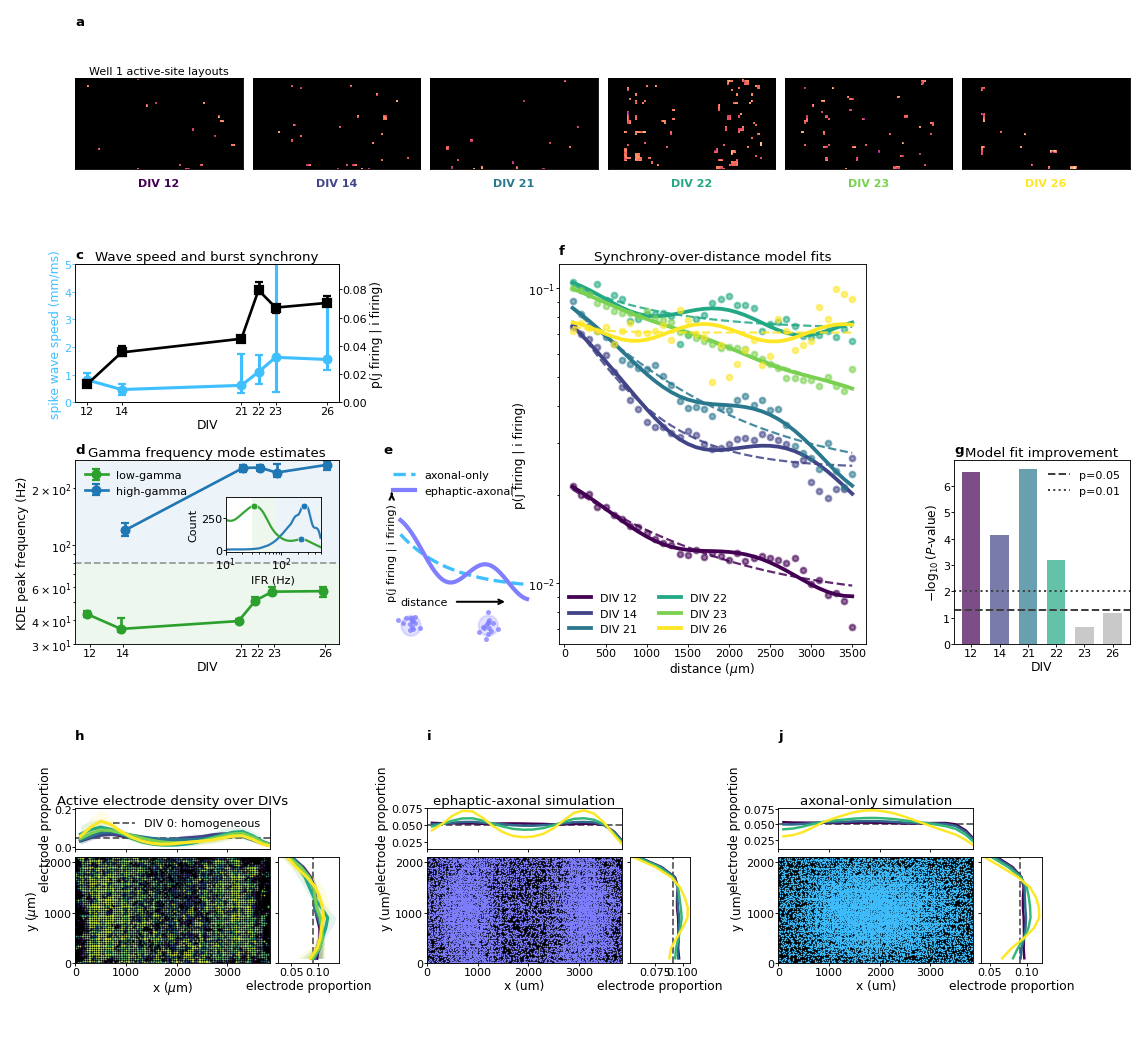

In [46]:

def draw_example_layout_div_panel(data, axes, **options):
    draw_example_layout_div_stack(axes)


def draw_concept_panel(data, ax, **options):
    draw_concept_schematic(ax)


def draw_peak_band_panel(data, ax, **options):
    draw_peak_band_ci_panel(ax)


def draw_wave_speed_panel(data, ax, **options):
    draw_wave_speed_synchrony_panel(ax)


def draw_model_fit_panel_wrapped(data, ax, **options):
    draw_model_fit_panel(ax, div=options.get("div", None))


def draw_model_lrt_panel_wrapped(data, ax, **options):
    draw_model_lrt_panel(ax)


def draw_spatial_panel(data, axes, **options):
    draw_spatial_differentiation_panel(data, axes, **options)


def draw_simulation_spatial_panel_wrapped(data, axes, **options):
    draw_simulation_spatial_panel(data, axes, **options)


def compose_figure4():
    fig4 = compose_figure(
        figure(
            width="two_column",
            height_mm=178.0,
            rows=[0.2, 0.15, 0.2, 0.3],
            row_gaps=[0.0, 0.01, 0.06],
            wspace=0.0,
            ncols=24,
            constrained_layout=False,
        ),
        [
            panel("a", label="a", loc=(0, 0, 1, 24), draw=draw_example_layout_div_panel, axes_factory=example_layout_div_axes_factory),
            panel("c", label="c", loc=(1, 0, 1, 6), draw=draw_wave_speed_panel),
            panel("d", label="d", loc=(2, 0, 1, 6), draw=draw_peak_band_panel),
            panel("e", label="e", loc=(2, 7, 1, 4), draw=draw_concept_panel),
            panel("f", label="f", loc=(1, 11, 2, 7), draw=draw_model_fit_panel_wrapped),
            panel("g", label="g", loc=(2, 20, 1, 4), draw=draw_model_lrt_panel_wrapped),
            panel("h", label="h", loc=(3, 0, 1, 6), draw=draw_spatial_panel, axes_factory=spatial_differentiation_axes_factory),
            panel("i", label="i", loc=(3, 8, 1, 6), draw=draw_simulation_spatial_panel_wrapped, axes_factory=spatial_differentiation_axes_factory, options={"model_key": "ephaptic_axonal"}),
            panel("j", label="j", loc=(3, 16, 1, 6), draw=draw_simulation_spatial_panel_wrapped, axes_factory=spatial_differentiation_axes_factory, options={"model_key": "axonal_only"}),
        ],
    )
    fig4.fig.subplots_adjust(left=0.055, right=0.985, top=0.955, bottom=0.070)
    return fig4

figure4 = compose_figure4()
plt.show()




## Export


In [47]:

if SAVE_FIGURE:
    export_figure(figure4.fig, OUTPUT_DIR / "figure_4_activity_distance_compilation", formats=("pdf", "svg", "png"), dpi=300)
    print(f"Exported Figure 4 draft to {OUTPUT_DIR}")
else:
    print("SAVE_FIGURE=False; not exporting.")


Exported Figure 4 draft to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure4_activity_distance
